# <font color='#000000'>__Exercício Prático 1__</font>
## <font color='#4894db'>__Previsão do Desfecho de um Remate__</font>
#### <font color='#4b4b4b'>Master Big Data Aplicado ao Futebol <br> Módulo 6 - Machine Learning - Introdução às técnicas e modelos aplicáveis <br> Desenvolvido por: Hugo Alves </font>

__Enunciado do Exercício__

<i> Durante o módulo foram apresentados 3 casos de uso de modelos de machine learning e fornecidos os notebooks onde exploramos esses mesmos exemplos.

Vimos também que os 3 modelos podem ser muito melhores, se adicionarmos novas fontes de dados, se criarmos features mais informativas e se analisarmos as combinações de treino possíveis.

Como exercício prático os alunos devem escolher um dos 3 casos (Regressão, Classificação ou clustering) e devem melhorar os resultados de avaliação do modelo.

Serão avaliadas as seguintes etapas:
* Obter novas e mais informativas fontes de dados
* EDA
* Limpeza dos dados
* Escolha das features
* Avaliação do modelo
* Apresentação

É suposto obterem o melhor modelo que conseguirem mas mais importante que isso é ter noção do sentido crítico do aluno em relação à forma como os dados foram tratados, como as features foram criadas e como o treino foi implementado. Como vimos no módulo por vezes podemos dar overfitting aos modelos, vale muito mais um modelo com uma má avaliação do que um modelo com 90% de recall mas claramente overfitted.
</i>
<br>

# <font color="#4894db">____________________</font>
# <font color="#4b4b4b">Índice de Conteúdos</font> <a class="anchor" id="toc"></a>
[1. Setup Inicial](#setup)<br>
- [1.1. Packages e Funções](#pack)<br>
- [1.2. Importação de Ficheiros](#imps)<br>

[2. EDA, Preparação e Pré-Processamento dos Dados](#eda)<br>
- [2.1. Criação do Target](#target)<br>
- [2.2. Transformação de Variáveis](#vars)<br>
- [2.3. Otimizar data types](#dtypes)<br>
- [2.4. Scaling](#scaling)<br>
- [2.5. Seleção de Variáveis](#selection)<br>
- [2.6. Outliers Multidimensionais](#outliers)<br>
- [2.7. Oversampling](#oversampling)<br>

[3. Modelação](#model)<br>
- [3.1. Computação de Modelos](#compute)<br>
- [3.2. Seleção do Modelo Ótimo](#bestmodel)<br>
- [3.3. Identificar Variáveis Mais Relevantes](#importance)<br>

# <font color="#4894db">______________</font>
# <font color='#4b4b4b'>1. Setup Inicial</font> <a class="anchor" id="setup"></a>
[Regressar ao Índice](#toc)

## <font color='#457fb5'>1.1. Packages e Funções</font> <a class="anchor" id="pack"></a>
[Regressar ao Índice](#toc)

In [ ]:
!python --version

Python 3.12.12


Vamos utilizar a versão 3.12.12 do Python.

Abaixo encontram-se os packages utilizados ao longo deste notebook.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import plotly.express as px

from scipy.stats import f_oneway, chi2_contingency

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import RFE
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, roc_auc_score, classification_report, confusion_matrix, roc_curve
from sklearn.linear_model import LogisticRegression, LassoCV
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN
from imblearn.over_sampling import SMOTE, ADASYN, RandomOverSampler, SMOTENC, BorderlineSMOTE, KMeansSMOTE, SVMSMOTE
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import BernoulliNB
from sklearn.svm import SVC
from xgboost import XGBClassifier

import os
import pickle
import zipfile

from itertools import combinations
import warnings
warnings.filterwarnings("ignore")

from google.colab import drive
drive.mount("/content/drive")

pd.set_option("display.max_columns", None)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Nas células seguintes encontram-se as funções utilizadas ao longo deste notebook. O ideal seria ter um ficheiro .py separado com as funções, mas neste caso, em que estamos a trabalhar num ficheiro colaborativo, talvez seja mais prático ter tudo junto.

In [ ]:
# Função para criar um gráfico de barras que relaciona duas variáveis categóricas
def categorical_barplot(df: pd.DataFrame,
                        feature_col: str,
                        target_col: str,
                        title: str = None,
                        colors: list = ["#7bbd8c", "#e6919b"]):
  """
  Cria um gráfico de barras para relacionar duas variáveis categóricas.

  Parâmetros:
  - df: DataFrame com os dados.
  - feature_col: Coluna categórica no eixo x.
  - target_col: Coluna categórica no eixo y.
  - title: Título do gráfico (opcional).
  - colors: Lista de cores para as barras (por defeito verde e vermelho).
  """
  fig, ax = plt.subplots(figsize = (8, 5))

  # Contagem do outcome dos remates por categoria
  counts = df.groupby([feature_col, target_col]).size().unstack()
  # Percentagens (dentro de cada categoria e do total)
  pcts = counts.div(counts.sum(axis = 1), axis = 0) * 100
  category_pcts = counts.sum(axis = 1) / counts.sum().sum() * 100

  # Criar gráfico
  counts.plot(kind = "barh", stacked = False, ax = ax, color = colors, edgecolor = ".6")

  # Percentagem de cada outcome do remate dentro da categoria
  for i, category in enumerate(counts.index):
    for j, event in enumerate(counts.columns):
      count = counts.loc[category, event]
      pct = pcts.loc[category, event]
      ax.text(count / 2, i + (j - 0.5) * 0.25, f"{pct:.1f}%", ha = "center", va = "center", fontsize = 9)

  # Percentagem de cada categoria
  for i, category in enumerate(counts.index):
    max_count = counts.loc[category].max()
    ax.text(max_count + 30, i, f"({category_pcts.loc[category]:.1f}% dos remates)", va = "center", fontsize = 9)

  ax.set_title(title if title else f"{target_col} por {feature_col}")
  ax.set_ylabel(feature_col)
  ax.spines[["top", "right"]].set_visible(False)
  plt.tight_layout()
  plt.show()

In [ ]:
def numerical_boxplot(df: pd.DataFrame,
                      feature_col: str,
                      target_col: str,
                      title: str = None,
                      colors: list = ["#e6919b", "#7bbd8c"],
                      offset: float = 2.5):
  """
  Cria um boxplot para relacionar uma variável numérica com uma variável categórica.

  Parâmetros:
  - df: DataFrame com os dados.
  - feature_col: Coluna numérica a analisar.
  - target_col: Coluna categórica para comparação.
  - title: Título do gráfico (opcional).
  - colors: Lista de cores para os boxplots (por defeito verde e vermelho).
  - offset: Deslocamento para as anotações (por defeito 2.5).
  """
  fig, ax = plt.subplots(figsize = (8, 5))

  categories = df[target_col].unique()
  data = [df[df[target_col] == cat][feature_col].dropna() for cat in categories]

  bp = ax.boxplot(data, patch_artist=True, vert=True, labels=categories)

  for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

  # Adicionar mediana e média como anotações
  for i, (cat, d) in enumerate(zip(categories, data)):
    median = d.median()
    mean = d.mean()
    ax.text(i + 0.7, median + offset, f"med: {median:.1f}", va = "center", fontsize = 9)
    ax.text(i + 0.7, mean - offset, f"avg: {mean:.1f}", va = "center", fontsize = 9)

  ax.set_title(title if title else f"{feature_col} por {target_col}")
  ax.set_xlabel(target_col)
  ax.set_ylabel(feature_col)
  ax.spines[["top", "right"]].set_visible(False)
  plt.tight_layout()
  plt.show()

In [ ]:
# Função para otimizar data types de variáveis numéricas
def optimize_dtypes(df: pd.DataFrame) -> pd.DataFrame:
  """
  Otimiza os data types das colunas numéricas de um DataFrame.

  Parâmetros:
  - df: DataFrame

  Devolve:
  - df: DataFrame com data types otimizados
  """
  for col in df.columns:
    if df[col].dtype in ["int64", "Int64"]:
      df[col] = pd.to_numeric(df[col], downcast = "integer")
    elif df[col].dtype == "float64":
      df[col] = pd.to_numeric(df[col], downcast = "float")
  return df

In [ ]:
# Função para realçar o valor de uma célula num DataFrame
def highlight_cell_val(val):
  """
  Realça o valor de uma célula num DataFrame.

  Parâmetros:
  - val: Valor a realçar
  """
  if val == "Manter":
    return "background-color: #7bbd8c"
  elif val == "Descartar":
    return "background-color: #e6919b"
  return ""

In [ ]:
# Função para correr uma grid search no melhor modelo e devolver os melhores parâmetros e resultados
def run_model(model,
              param_grid: dict,
              X_train: pd.DataFrame,
              y_train: pd.Series,
              X_val: pd.DataFrame,
              y_val: pd.Series,
              scoring = "f1",
              save_model = False,
              model_name = None,
              n_iterations: int = 1000):
  """
  Executa uma grid search para o modeo fornecido, e avalia-o no dataset de validação com base na métrica escolhida.
  Calcula e devolve a accuracy, precision, recall, F1 score, e AUROC (se aplicável).
  Guarda também o modelo para um ficheiro pickle (opcional).

  Parâmetros:
  - model: Modelo para treinar e otimizar.
  - param_grid: Grelha de parâmetros para a grid search.
  - X_train: DataFrame de variáveis independentes de treino.
  - y_train: Target dos dados de treino.
  - X_val: DataFrame de variáveis independentes de validação.
  - y_val: Target dos dados de validação.
  - scoring: Métrica para avaliar o modelo.
  - save_model: Opção de guardar o modelo num ficheiro pickle.
  - model_name: Nome do ficheiro pickle.
  - n_iterations: Número de combinações testadas para a grid search.
  """
  grid_search = RandomizedSearchCV(estimator = model, param_distributions = param_grid, n_iter = n_iterations, error_score = 0,
                                   scoring = scoring, n_jobs = -1, cv = 5, verbose = 2, random_state = 92)
  grid_search.fit(X_train, y_train)

  best_params = grid_search.best_params_
  best_model = grid_search.best_estimator_
  best_model.fit(X_train, y_train)

  y_pred = best_model.predict(X_val)
  y_pred_proba = best_model.predict_proba(X_val)[:, 1] if hasattr(best_model, "predict_proba") else None

  accuracy = np.round(accuracy_score(y_val, y_pred), 4)
  precision = np.round(precision_score(y_val, y_pred), 4)
  recall = np.round(recall_score(y_val, y_pred), 4)
  f1 = np.round(f1_score(y_val, y_pred), 4)
  roc_auc = np.round(roc_auc_score(y_val, y_pred_proba), 4) if y_pred_proba is not None else "-"

  print("\nClassification Report:\n", classification_report(y_val, y_pred))
  print("Accuracy:", accuracy, "| Precision:", precision, "| Recall:", recall, "| F1 score:", f1, "| AUROC:", roc_auc)

  if save_model is True:
    model_dir = "/content/drive/MyDrive/M6_shots_models"
    os.makedirs(model_dir, exist_ok = True)
    model_filename = os.path.join(model_dir, f"{model_name}.pkl")
    with open(model_filename, "wb") as file:
      pickle.dump(best_model, file)

  return best_params, y_pred, accuracy, precision, recall, f1, roc_auc

In [ ]:
# Função para carregar um modelo a partir de um ficheiro pickle, avaliar num dataset de validação e devolver os parâmetros e métricas obtidas
def get_model(pickle_file_name: str,
              X_val: pd.DataFrame,
              y_val: pd.Series,
              zip_path: str = None):
  """
  Carrega um modelo a partir de um ficheiro pickle, avalia-o num dataset de validação e devolve os parâmetros e métricas obtidas.

  Parâmetros:
  - pickle_file_name: Ficheiro pickle com o modelo.
  - X_val: DataFrame de variáveis independentes de validação.
  - y_val: Target dos dados de validação.
  - zip_path: Caminho do ficheiro zip com o modelo.
  """
  if zip_path is not None:
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
      zip_ref.extractall(os.path.dirname(zip_path))

  with open(pickle_file_name, "rb") as file:
      model = pickle.load(file)

  model_params = model.get_params()

  y_pred = model.predict(X_val)
  y_pred_proba = model.predict_proba(X_val)[:, 1] if hasattr(model, "predict_proba") else None

  accuracy = np.round(accuracy_score(y_val, y_pred), 4)
  precision = np.round(precision_score(y_val, y_pred), 4)
  recall = np.round(recall_score(y_val, y_pred), 4)
  f1 = np.round(f1_score(y_val, y_pred), 4)
  roc_auc = np.round(roc_auc_score(y_val, y_pred_proba), 4) if y_pred_proba is not None else "-"

  print("\nClassification Report:\n", classification_report(y_val, y_pred))
  print("Accuracy:", accuracy, "| Precision:", precision, "| Recall:", recall, "| F1 score:", f1, "| AUROC:", roc_auc)

  return model_params, y_pred, accuracy, precision, recall, f1, roc_auc

In [ ]:
# Função para customizar o fundo do valor do DataFrame mais alto para cada coluna
def highlight_max_column(df: pd.DataFrame):
    """
    Devolve o DataFrame, salientando a célula com o maior valor para cada coluna.
    """
    return df.style.apply(lambda col: ["background-color: #7bbd8c" if pd.to_numeric(col, errors = "coerce").max() == value else "" for value in col], axis = 0)

### <font color='#457fb5'>1.2. Importação de Ficheiros</font> <a class="anchor" id="imps"></a>
[Regressar ao Índice](#toc)

Vamos começar por importar os dados de remates disponíveis.

In [ ]:
df_goals = pd.read_csv("goal_shots.csv")
df_missed = pd.read_csv("missed_shots.csv")

In [ ]:
print("Valores únicos do tipo de evento no dataset de golos:", df_goals["event_name"].unique())
print("Valores únicos do tipo de evento no dataset de remates falhados:", df_missed["event_name"].unique())

Valores únicos do tipo de evento no dataset de golos: ['Goal']
Valores únicos do tipo de evento no dataset de remates falhados: ['Miss']


Podemos agregar tudo num único dataset de remates.

In [ ]:
print("Forma do dataset de golos:", df_goals.shape)
print("Forma do dataset de remates falhados:", df_missed.shape)

Forma do dataset de golos: (723, 99)
Forma do dataset de remates falhados: (2793, 89)


As colunas não são exatamente as mesmas. Vamos só verificar esta situação antes de continuar.

In [ ]:
cols_goals_not_missed = set(df_goals.columns) - set(df_missed.columns)
cols_missed_not_goals = set(df_missed.columns) - set(df_goals.columns)

print(f"{len(cols_goals_not_missed)} colunas presentes apenas no dataset de golos:", cols_goals_not_missed)
print(f"{len(cols_missed_not_goals)} colunas presentes apenas no dataset de remates falhados:", cols_missed_not_goals)

30 colunas presentes apenas no dataset de golos: {'280', '395', '343', '353', 'Deflection', '274', '362', 'Own goal', '1 on 1', 'Penalty', '374', '282', '300', '2nd related event ID', '254', '359', 'Low right', '390', 'Low centre', '275', '273', '396', '281', 'Low left', 'Keeper Touched', '375', 'Hit Woodwork', 'Swerve Moving', 'High centre', '2nd assisted'}
20 colunas presentes apenas no dataset de remates falhados: {'35+ left', '35+ right', '391', '233', '276', 'Close right', '314', 'Keeper Saved', 'Close right and high', 'Blocked y co-ordinate', 'Not past goal line', 'High', 'Left', 'Close left and high', 'Out of box-right', 'Out of box-deep right', 'Blocked x co-ordinate', 'Close high', 'Close left', 'Right'}


Para já, vamos juntar os dois DataFrames sem fazer qualquer transformação adicional. Ainda assim, podemos desde já tomar nota desta situação e eventualmente trabalhá-la mais adiante.

In [ ]:
df_shots = pd.concat([df_goals, df_missed], ignore_index = True)
df_shots.reset_index(drop = True, inplace = True)
df_shots.shape

(3516, 119)

Ótimo. Agora que temos toda a informação num único dataset, podemos prosseguir para a exploração e tratamento dos dados.

# <font color="#4894db">__________________________________________________</font>
# <font color='#4b4b4b'>2. EDA, Preparação e Pré-Processamento dos Dados</font> <a class="anchor" id="eda"></a>
[Regressar ao Índice](#toc)

Neste capítulo, vamos analisar a informação disponível, tratá-la e complementá-la para deixar tudo pronto para a etapa de modelação. O ideal seria ter uma parte exclusivamente dedicada à exploração dos dados numa perspetiva mais analítica e uma segunda onde fosse feita toda a preparação e pré-processamento dos dados, já tendo por base o conhecimento obtido na fase anterior. Ainda assim, para efeitos de eficiência, juntaremos as duas etapas numa só, explorando e retirando insights dos dados ao mesmo tempo que os trabalhamos para serem recebidos pelos nossos modelos.

Começamos por olhar para as 5 primeiras linhas do DataFrame e olhar para as colunas disponíveis.

In [ ]:
df_shots.head()

,Unnamed: 0,id,event_id,type_id,event_name,period_id,min,sec,team_id,outcome,x,y,timestamp,last_modified,version,player_id,keypass,competition_id,game_id,home_team_id,home_team_name,away_team_id,away_team_name,competition_name,season_id,374,375,395,396,Big Chance,Deflection,GK X Coordinate,GK Y Coordinate,Goal mouth y co-ordinate,Goal mouth z co-ordinate,Low left,Regular play,Right footed,Small box-centre,Standing,Zone,assist,280,281,282,328,Assisted,Box-centre,Fast break,High right,Intentional assist,Left footed,Low right,Related event ID,Swerve Left,353,390,Low centre,Penalty,Weak,Box-deep left,Head,Own goal,Set piece,Small box-right,1 on 1,273,388,From corner,Hit Woodwork,Keeper Touched,Out of box-centre,Individual Play,Box-left,Volley,254,Free kick,High centre,High left,Swerve Right,Box-deep right,Small box-left,Box-right,Other body part,2nd assisted,2nd related event ID,300,343,Throw-in set piece,274,275,Strong,362,Out of box-deep left,359,Out of box-left,35+ centre,389,Swerve Moving,276,391,Blocked x co-ordinate,Blocked y co-ordinate,Close left,Left,Not past goal line,Right,High,Close right,Close high,35+ right,Close right and high,233,Keeper Saved,314,Close left and high,Out of box-right,Out of box-deep right,35+ left
0,0,2267410127,304,16,Goal,1,38,16,6644,1,96.5,49.3,2021-02-21T15:39:15.235,2021-04-19T19:02:18,1618855338252,232112,-,99,2133340,2847,Rio Ave,6644,FC Famalicão,Portuguese Primeira Liga,2020,2021-02-21 15:39:14.890,38:15.909,98.9,48.6,sim,sim,98.8,47.5,52.3,4.4,sim,sim,sim,sim,sim,Center,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0,2230821285,98,16,Goal,1,10,36,255,1,92.0,61.6,2020-11-07T20:42:02.069,2020-11-10T07:10:53,1604992254440,181285,-,99,2133227,371,Vitória Guimarães,255,Sporting CP,Portuguese Primeira Liga,2020,2020-11-07 20:42:01.156,10:36.069,98.9,53.2,sim,-,98.6,54.0,46.1,1.3,NaN,-,-,NaN,sim,Center,-,-,-,-,-,sim,sim,sim,-,sim,sim,sim,97,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,2230835833,364,16,Goal,1,42,47,255,1,85.8,46.0,2020-11-07T21:14:12.272,2020-11-10T07:27:32,1604993250813,433145,-,99,2133227,371,Vitória Guimarães,255,Sporting CP,Portuguese Primeira Liga,2020,2020-11-07 21:14:11.551,42:46.464,97.8,47.3,-,sim,98.4,48.9,47.3,26.6,NaN,sim,sim,NaN,sim,Center,-,PASS_LOST,441164,255,sim,-,sim,-,sim,-,-,-,-,sim,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2,2230854433,460,16,Goal,2,54,47,255,1,84.9,38.4,2020-11-07T21:45:10.603,2020-11-10T07:10:41,1604992240623,433145,-,99,2133227,371,Vitória Guimarães,255,Sporting CP,Portuguese Primeira Liga,2020,2020-11-07 21:45:09.836,54:47.144,8.9,57.4,sim,-,8.9,56.5,47.1,4.4,NaN,sim,sim,NaN,sim,Center,-,-,-,-,-,sim,sim,-,-,-,-,sim,459,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,3,2230861893,628,16,Goal,2,73,51,255,1,85.9,58.3,2020-11-07T22:04:14.283,2020-11-10T07:44:08,1604994248219,437913,-,99,2133227,371,Vitória Guimarães,255,Sporting CP,Portuguese Primeira Liga,2020,2020-11-07 22:04:13.302,73:50.610,2.9,49.8,-,-,3.2,48.4,45.9,3.2,NaN,sim,sim,NaN,sim,Center,-,-,-,-,-,sim,sim,-,-,sim,-,sim,627,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Na

In [ ]:
df_shots.columns.tolist()

['Unnamed: 0',
 'id',
 'event_id',
 'type_id',
 'event_name',
 'period_id',
 'min',
 'sec',
 'team_id',
 'outcome',
 'x',
 'y',
 'timestamp',
 'last_modified',
 'version',
 'player_id',
 'keypass',
 'competition_id',
 'game_id',
 'home_team_id',
 'home_team_name',
 'away_team_id',
 'away_team_name',
 'competition_name',
 'season_id',
 '374',
 '375',
 '395',
 '396',
 'Big Chance',
 'Deflection',
 'GK X Coordinate',
 'GK Y Coordinate',
 'Goal mouth y co-ordinate',
 'Goal mouth z co-ordinate',
 'Low left',
 'Regular play',
 'Right footed',
 'Small box-centre',
 'Standing',
 'Zone',
 'assist',
 '280',
 '281',
 '282',
 '328',
 'Assisted',
 'Box-centre',
 'Fast break',
 'High right',
 'Intentional assist',
 'Left footed',
 'Low right',
 'Related event ID',
 'Swerve Left',
 '353',
 '390',
 'Low centre',
 'Penalty',
 'Weak',
 'Box-deep left',
 'Head',
 'Own goal',
 'Set piece',
 'Small box-right',
 '1 on 1',
 '273',
 '388',
 'From corner',
 'Hit Woodwork',
 'Keeper Touched',
 'Out of box-centr

Podemos desde já eliminar as colunas que sabemos que não terão qualquer valor para os modelos nem interesse exploratório (iremos eliminar com certeza outras mais à frente, mas poderão ainda vir a ser úteis).

In [ ]:
df_shots.drop(columns = ["Unnamed: 0", "id", "event_id", "last_modified", "version", "Related event ID", "2nd related event ID"], inplace = True)

## <font color='#457fb5'>2.1. Criação do Target</font> <a class="anchor" id="target"></a>
[Regressar ao Índice](#toc)

Vamos criar a nossa coluna com a variável dependente (que provavelmente até já temos disponível). Depois, trataremos já de separar os dados em datasets de treino e validação, para assegurar um pré-processamento mais limpo e evitar data leakage (tanto nesta fase como na própria exploração dos dados), em que o objetivo é avaliar depois o modelo em dados nunca antes vistos.

In [ ]:
# Temos três colunas de target potenciais
df_shots["event_name"].value_counts(dropna = False)

,count
event_name,
Miss,2793
Goal,723


In [ ]:
df_shots["type_id"].value_counts(dropna = False)

,count
type_id,
13,2793
16,723


In [ ]:
# Confirmar que as duas colunas dizem o mesmo
df_shots.groupby("event_name")["type_id"].value_counts()

,,count
event_name,type_id,
Goal,16,723
Miss,13,2793


In [ ]:
df_shots["outcome"].value_counts(dropna = False)

,count
outcome,
1,3516


Se a coluna `outcome` é sempre 1, então é garantido que a coluna de target será a `event_name`. Além disso, ficamos a saber que esta coluna não terá qualquer valor preditivo por assumir sempre o mesmo valor.

In [ ]:
# Descartamos então a coluna do outcome e a do type_id
df_shots.drop(columns = ["outcome", "type_id"], inplace = True)

In [ ]:
# E podemos criar um dataset com as variáveis independentes e outro com as variáveis dependentes
X = df_shots.drop(columns = ["event_name"])
y = df_shots["event_name"]

Agora, vamos separar o DataFrame em dados de treino e validação, guardando 20% das observações para avaliar o modelo em dados "novos" (se o dataset fosse maior, poderíamos avaliar a performance em 25% ou 30% dos dados, por exemplo, mas como o conjunto de observações não é assim tão grande, pode ser mais interessante guardar mais dados para treinar os modelos).

Notar ainda o parâmetro "stratify", que garante uma distribuição igual do target (golos vs remates falhados) pelos datasets de treino e validação.

In [ ]:
df_shots_train, df_shots_val, y_train, y_val = train_test_split(X, y, test_size = 0.2, random_state = 92, stratify = y)
df_shots_train.shape, df_shots_val.shape, y_train.shape, y_val.shape

((2812, 109), (704, 109), (2812,), (704,))

In [ ]:
# Criar um dataset auxiliar apenas para efeitos de exploração, que volta a juntar as variáveis independentes e dependentes dos dados de treino
df_shots_explore = pd.concat([df_shots_train, y_train], axis = 1)

# Criar lista com os DataFrames para ser mais fácil replicar as alterações que viermos a fazer
df_shots_X = [df_shots_train, df_shots_val, df_shots_explore]

df_shots_explore.shape

(2812, 110)

## <font color='#457fb5'>2.2. Transformação de Variáveis</font> <a class="anchor" id="vars"></a>
[Regressar ao Índice](#toc)

Nesta parte, o foco será a exploração e transformação das colunas existentes, criando novas variáveis potencialmente mais interessantes e informativas para os modelos, e complementando-as eventualmente com informação proveniente de outras fontes.

Começaremos por eliminar variáveis cujo valor só é conhecido após o remate ser efetuado. Estas colunas não poderão integrar os modelos, sob pena de introduzirem leakage ao transmitirem informação que estes não deveriam conhecer no momento em que efetuam a previsão.

Nota: Vamos aproveitar e eliminar as variáveis também descartadas pelo mesmo motivo no notebook de exemplo. Adicionalmente, vamos eliminar outras tendo por base a documentação fornecida pela OPTA.

In [ ]:
#sorted(df_shots_explore.columns)

In [ ]:
# Dúvida: Swerve Left, Swerve Moving, Swerve Right
cols_leakage = ["1 on 1", "2nd assisted", "Blocked x co-ordinate", "Blocked y co-ordinate", "Close high", "Close left",
                "Close left and high", "Close right", "Close right and high", "Deflection", "Goal mouth y co-ordinate",
                "Goal mouth z co-ordinate", "High", "High centre", "High left", "High right", "Hit Woodwork",
                "Keeper Saved", "Keeper Touched", "Left", "Low centre", "Low left", "Low right",
                "Not past goal line", "Own goal", "Right", "Standing", "Strong", "Swerve Left",
                "Swerve Moving", "Swerve Right", "Weak"]

for df in df_shots_X:
  df.drop(columns = cols_leakage, inplace = True)
  print(df.shape)

(2812, 77)
(704, 77)
(2812, 78)


Da mesma forma, serão também removidas as variáveis identificadas por números, uma vez que não sabemos o que representam e, neste contexto, isso é um fator relevante para desenvolver a nossa análise (nenhum treinador ou membro da equipa técnica vai confiar ou querer utilizar um modelo em que uma coluna chamada "374", por exemplo, é relevante para a previsão e que ninguém sabe o que quer dizer).

__Nota:__ Estas colunas apenas são eliminadas "cegamente" porque sabemos que não temos acesso ao seu significado (apenas temos um dicionário de informação com IDs de qualifiers até ao 232, e estas colunas apresentam todas IDs superiores). Caso contrário, a solução mais adequada seria fazer primeiro um mapeamento das colunas "conhecidas", e depois então eliminar as restantes.

In [ ]:
# Aproveitar e analisar valores únicos antes de eliminar, para o caso de haver colunas em que conseguimos depreender o significado através dos valores
cols_numeric_names = [col for col in df_shots_train.columns if str(col).isdigit()]
for col in cols_numeric_names:
  print("==============================================================")
  print(f"Valores únicos da coluna {col}:", df_shots_train[col].unique())

Valores únicos da coluna 374: [nan '2021-04-20 21:43:55.644' '2020-10-25 18:58:34.667'
 '2020-09-18 19:40:54.711' '2021-02-22 19:18:09.790'
 '2021-02-16 18:08:25.634' '2021-05-19 23:18:54.690'
 '2020-10-03 21:21:07.722' '2020-10-03 21:41:55.070'
 '2021-04-11 17:07:24.379' '2021-03-20 16:14:28.452'
 '2021-02-17 22:22:10.859' '2021-05-19 21:57:32.785'
 '2021-02-05 21:01:54.209' '2021-02-04 21:53:07.705'
 '2021-03-05 21:10:11.816' '2020-10-28 23:41:43.859'
 '2020-11-01 19:17:44.643' '2021-04-26 19:47:34.524'
 '2020-09-26 22:28:21.367' '2021-02-27 19:19:35.287'
 '2021-03-20 15:50:55.610' '2021-03-05 20:22:47.825'
 '2020-12-28 21:26:02.631' '2021-01-10 15:10:27.082'
 '2021-05-06 16:20:50.684' '2020-10-04 18:52:34.962'
 '2021-05-14 21:55:25.599' '2021-02-27 18:11:38.924'
 '2020-11-08 18:38:31.664' '2021-04-04 18:08:46.345'
 '2020-12-21 20:44:18.276' '2021-04-02 21:51:08.999'
 '2021-04-30 23:06:00.108' '2021-04-22 20:53:32.949'
 '2020-09-18 20:11:37.631' '2021-05-19 20:46:46.698'
 '2021-01-16

Vamos apenas manter as colunas e 374 e 375 para avaliarmos, mais adiante, se têm alguma correlação com as colunas `min`, `sec` ou `timestamp`, por exemplo. Provavelmente iremos acabar por descartá-las na mesma, mas não custa nada mantê-las por agora.

In [ ]:
cols_numeric_names.remove("374")
cols_numeric_names.remove("375")

# As restantes colunas serão eliminadas
for df in df_shots_X:
  df.drop(columns = cols_numeric_names, inplace = True)
  print(df.shape)

(2812, 55)
(704, 55)
(2812, 56)


Por fim, vamos desconsiderar variáveis dependentes que só se aplicam a um outcome específico do remate. Para isso, vamos voltar aos casos que identificámos inicialmente quando criámos um dataset único, e rever as colunas que apenas existem para golos ou remates falhados (e que ainda sobram depois dos passos anteriores).

In [ ]:
cols_goals_not_missed = set(df_shots_train.columns) - set(df_missed.columns)
cols_missed_not_goals = set(df_shots_train.columns) - set(df_goals.columns)

print(f"{len(cols_goals_not_missed)} colunas presentes apenas no dataset de golos:", cols_goals_not_missed)
print(f"{len(cols_missed_not_goals)} colunas presentes apenas no dataset de remates falhados:", cols_missed_not_goals)

3 colunas presentes apenas no dataset de golos: {'374', '375', 'Penalty'}
4 colunas presentes apenas no dataset de remates falhados: {'Out of box-deep right', 'Out of box-right', '35+ left', '35+ right'}


Analisando o significado destas colunas (e ignorando as duas colunas numéricas que optámos por manter do passo anterior), não parece haver nenhuma coluna que seja puramente específica do tipo de evento associado - simplesmente calhou que tenham acontecido apenas para golos ou remates falhados (e até pode indicar que são variáveis potencialmente relevantes para prever um destes cenários).

Assim sendo, vamos prosseguir para a análise das variáveis que permanecem no dataset, mas antes disso vamos fazer um apanhado geral do nosso DataFrame, que agora tem praticamente metade das variáveis iniciais.

In [ ]:
df_shots_explore.head()

,period_id,min,sec,team_id,x,y,timestamp,player_id,keypass,competition_id,game_id,home_team_id,home_team_name,away_team_id,away_team_name,competition_name,season_id,374,375,Big Chance,GK X Coordinate,GK Y Coordinate,Regular play,Right footed,Small box-centre,Zone,assist,Assisted,Box-centre,Fast break,Intentional assist,Left footed,Penalty,Box-deep left,Head,Set piece,Small box-right,From corner,Out of box-centre,Individual Play,Box-left,Volley,Free kick,Box-deep right,Small box-left,Box-right,Other body part,Throw-in set piece,Out of box-deep left,Out of box-left,35+ centre,35+ right,Out of box-right,Out of box-deep right,35+ left,event_name
3410,2,85,9,201,86.8,32.2,2021-04-22T22:45:01.542,178867,-,99,2133417,201,FC Porto,371,Vitória Guimarães,Portuguese Primeira Liga,2020,NaN,NaN,NaN,97.6,46.4,-,sim,NaN,Center,-,sim,NaN,sim,sim,-,NaN,NaN,NaN,-,NaN,-,-,sim,NaN,-,NaN,NaN,NaN,sim,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Miss
687,2,83,57,3217,91.0,44.6,2021-04-20T21:43:56.591,183981,-,99,2133419,1981,Paços de Ferreira,3217,SC Farense,Portuguese Primeira Liga,2020,2021-04-20 21:43:55.644,83:56.169,sim,91.1,41.9,sim,NaN,NaN,Center,-,sim,sim,NaN,NaN,sim,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Goal
363,2,68,56,196,73.2,74.5,2020-10-25T18:58:35.802,469205,-,99,2133205,6644,FC Famalicão,196,Boavista,Portuguese Primeira Liga,2020,2020-10-25 18:58:34.667,68:55.392,-,99.1,50.7,sim,-,NaN,Center,-,sim,-,NaN,-,sim,-,NaN,-,-,NaN,NaN,sim,sim,NaN,NaN,-,NaN,NaN,NaN,NaN,NaN,NaN,-,NaN,NaN,NaN,NaN,NaN,Goal
28,1,41,22,251,81.5,32.5,2020-09-18T19:40:56.105,106004,-,99,2133169,6644,FC Famalicão,251,Benfica,Portuguese Primeira Liga,2020,2020-09-18 19:40:54.711,41:21.320,-,99.0,50.2,-,-,-,Center,-,-,-,NaN,-,sim,NaN,NaN,NaN,NaN,NaN,NaN,sim,-,NaN,NaN,sim,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Goal
1946,2,74,40,372,89.8,68.0,2021-04-25T21:34:25.102,155476,-,99,2133428,372,Sporting Braga,255,Sporting CP,Portuguese Primeira Liga,2020,NaN,NaN,NaN,98.2,55.1,sim,-,NaN,Center,-,sim,-,NaN,sim,sim,NaN,NaN,-,NaN,NaN,-,-,-,sim,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Miss


In [ ]:
df_shots_explore.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2812 entries, 3410 to 2851
Data columns (total 56 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   period_id              2812 non-null   int64  
 1   min                    2812 non-null   int64  
 2   sec                    2812 non-null   int64  
 3   team_id                2812 non-null   int64  
 4   x                      2812 non-null   float64
 5   y                      2812 non-null   float64
 6   timestamp              2812 non-null   object 
 7   player_id              2812 non-null   int64  
 8   keypass                2812 non-null   object 
 9   competition_id         2812 non-null   int64  
 10  game_id                2812 non-null   int64  
 11  home_team_id           2812 non-null   int64  
 12  home_team_name         2812 non-null   object 
 13  away_team_id           2812 non-null   int64  
 14  away_team_name         2812 non-null   object 
 15  compet

De momento, quase todas as colunas estão formatadas como "object" (podemos otimizar mais à frente) mas, mais importante que isso, existe um número considerável de colunas que possui muitos missing values. Mesmo que haja uma justificação plausível para estas ausências e os valores possam ser preenchidos, serão sempre variáveis quase "univariadas" que poderão acrescentar pouco aos modelos, senão mesmo confundi-los.

Podemos olhar mais em detalhe para as colunas com valores em falta.

In [ ]:
missing_values = pd.DataFrame(df_shots_explore.isna().sum(), columns = ["# missing values"])
missing_values["% missing values"] = round(missing_values["# missing values"] / len(df_shots_explore) * 100, 2)
missing_values.sort_values("% missing values", ascending = False)

,# missing values,% missing values
Out of box-right,2809,99.89
35+ right,2808,99.86
Out of box-deep left,2807,99.82
35+ left,2807,99.82
Out of box-deep right,2805,99.75
35+ centre,2797,99.47
Other body part,2792,99.29
Box-deep right,2788,99.15
Out of box-left,2787,99.11
Box-deep left,2784,99.00


Vamos desde já descartar todas as variáveis que tenham pelo menos 99% de missing values. Pode ser um valor algo conservador, mas já irá permitir retirar um bom número de colunas. Além disso, esperamos que mais à frente possamos utilizar as variáveis das coordenadas para extrair a generalidade da informação que estas colunas dariam.

In [ ]:
cols_missing = missing_values[missing_values["% missing values"] >= 99].index.tolist()

for df in df_shots_X:
  df.drop(columns = cols_missing, inplace = True)
  print(df.shape)

(2812, 45)
(704, 45)
(2812, 46)


Perfeito. Vamos então (finalmente) começar a explorar as nossas variáveis. Tentaremos seguir mais ou menos a ordem pela qual aparecem no dataset, mas podemos relacioná-las com outras quando relevante. <br><br>

### `period_id`, `min`, `sec` e `375`

Vamos começar por validar que só temos duas partes neste conjunto de dados.

In [ ]:
df_shots_explore["period_id"].value_counts(dropna = False)

,count
period_id,
2,1506
1,1306


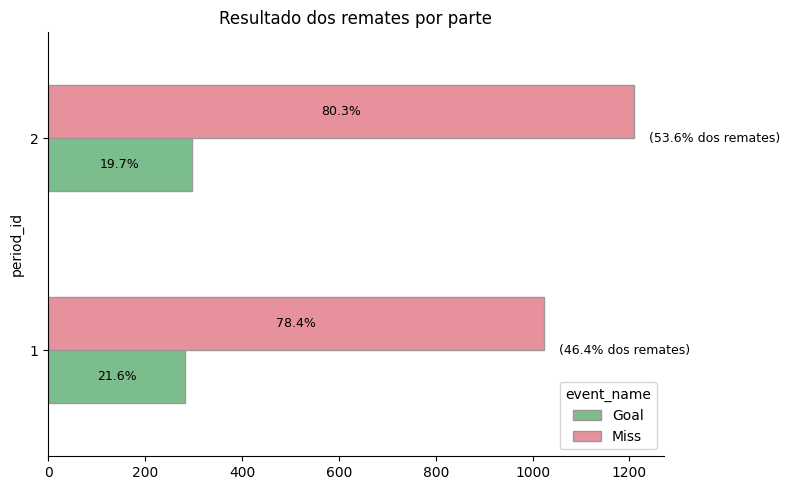

In [ ]:
categorical_barplot(df_shots_explore, "period_id", "event_name", "Resultado dos remates por parte")

O facto de um remate ser efetuado na primeira ou na segunda parte não parece influenciar o seu desfecho, visto que a percentagem de golos é semelhante para os dois grupos.

Outra análise que podemos fazer é verificar se temos dados de remates efetuados em tempo de compensação (após os 45 minutos na primeira parte e após os 90 na segunda).

In [ ]:
df_shots_explore[
  ((df_shots_explore["min"] >= 45) & (df_shots_explore["period_id"] == 1)) |
  ((df_shots_explore["min"] >= 90) & (df_shots_explore["period_id"] == 2))
].shape

(268, 46)

Ainda é um número considerável - perto de 10% das cerca de 2800 linhas que temos. Podemos isolar e ver quantas destas linhas são relativas a eventos nos descontos da segunda parte.

In [ ]:
df_shots_explore[(df_shots_explore["min"] >= 90) & (df_shots_explore["period_id"] == 2)].shape

(185, 46)

Interessante. Vamos criar 3 variáveis binárias: uma para identificar golos marcados no tempo de compensação da primeira parte, outra para identificar golos marcados no tempo de compensação da segunda parte, e uma terceira (agregadora) simplesmente para identificar golos na compensação (de qualquer parte).

__Nota:__ Naturalmente, não iremos enviar todas estas variáveis para o modelo. Apenas pretendemos explorar o potencial valor de cada uma e depois optaremos pela(s) mais relevante(s).

In [ ]:
df_shots_explore["added_time_1st_half"] = ((df_shots_explore["min"] >= 45) & (df_shots_explore["period_id"] == 1)).astype(int)
df_shots_explore["added_time_2nd_half"] = ((df_shots_explore["min"] >= 90) & (df_shots_explore["period_id"] == 2)).astype(int)
df_shots_explore["added_time"] = ((df_shots_explore["added_time_1st_half"] == 1) | (df_shots_explore["added_time_2nd_half"] == 1)).astype(int)

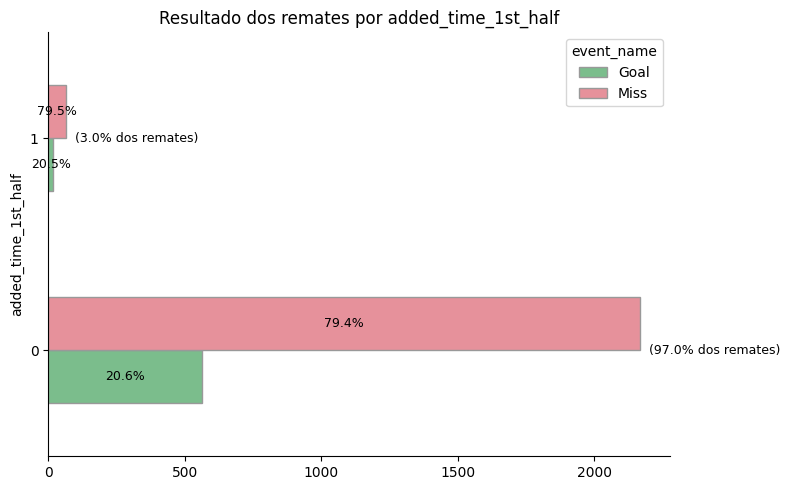

In [ ]:
categorical_barplot(df_shots_explore, "added_time_1st_half", "event_name", "Resultado dos remates por added_time_1st_half")

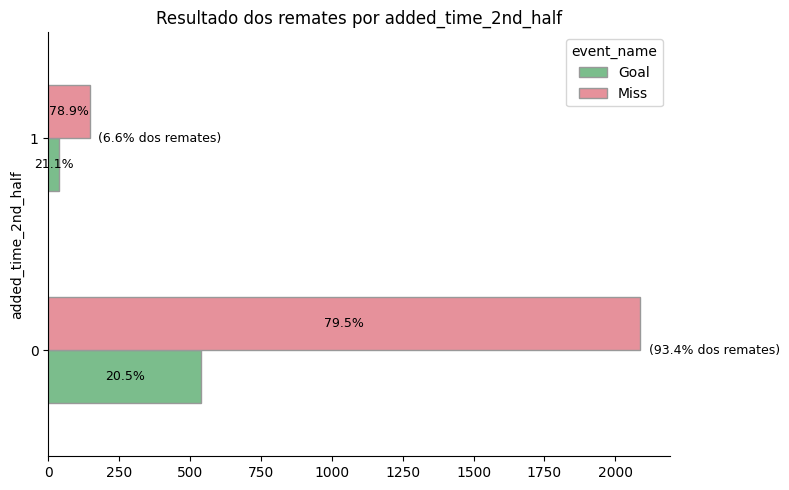

In [ ]:
categorical_barplot(df_shots_explore, "added_time_2nd_half", "event_name", "Resultado dos remates por added_time_2nd_half")

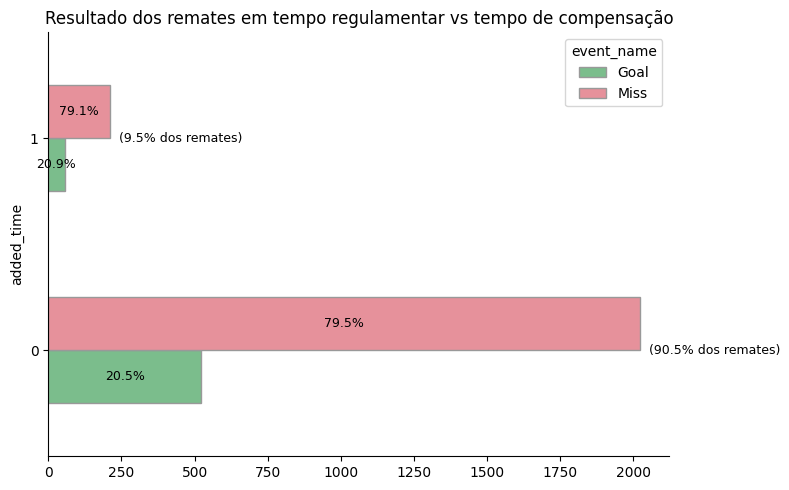

In [ ]:
categorical_barplot(df_shots_explore, "added_time", "event_name", "Resultado dos remates em tempo regulamentar vs tempo de compensação")

Infelizmente, não parece haver nenhuma relação entre um remate ser feito no tempo de compensação (tanto da primeira como da segunda parte) e uma variação na probabilidade de golo. Pegando no exemplo dos remates feitos na compensação da primeira parte (uma conclusão que também se aplica às outras duas variáveis), 20.5% dos remates deram golo, comparado com 20.6% para os remates efetuados fora deste período - uma vez que o target não varia em função desta variável independente, __concluímos que ela não apresenta nenhum valor preditivo e, por isso, não a vamos aplicar nos nossos datasets__ (lembrando que acima apenas aplicámos a transformação no dataset específico para exploração).

Podemos, ainda assim, verificar se existem outliers dentro de cada parte. Por exemplo, será estranho se encontrarmos um evento aos 90 minutos mas que está identificado como tendo sido feito na primeira parte da partida.

In [ ]:
# Vamos assumir 10 minutos de descontos como sendo o limite do razoável
df_shots_explore[(df_shots_explore["period_id"] == 1) & (df_shots_explore["min"] > 55)]

,period_id,min,sec,team_id,x,y,timestamp,player_id,keypass,competition_id,game_id,home_team_id,home_team_name,away_team_id,away_team_name,competition_name,season_id,374,375,Big Chance,GK X Coordinate,GK Y Coordinate,Regular play,Right footed,Small box-centre,Zone,assist,Assisted,Box-centre,Fast break,Intentional assist,Left footed,Penalty,Head,Set piece,Small box-right,From corner,Out of box-centre,Individual Play,Box-left,Volley,Free kick,Small box-left,Box-right,Throw-in set piece,event_name,added_time_1st_half,added_time_2nd_half,added_time


In [ ]:
# O mesmo para remates na segunda parte
df_shots_explore[df_shots_explore["min"] > 100]

,period_id,min,sec,team_id,x,y,timestamp,player_id,keypass,competition_id,game_id,home_team_id,home_team_name,away_team_id,away_team_name,competition_name,season_id,374,375,Big Chance,GK X Coordinate,GK Y Coordinate,Regular play,Right footed,Small box-centre,Zone,assist,Assisted,Box-centre,Fast break,Intentional assist,Left footed,Penalty,Head,Set piece,Small box-right,From corner,Out of box-centre,Individual Play,Box-left,Volley,Free kick,Small box-left,Box-right,Throw-in set piece,event_name,added_time_1st_half,added_time_2nd_half,added_time


In [ ]:
# E, já que aqui estamos, podemos confirmar que não há remates na segunda parte mas que foram feitos antes do minuto 45
df_shots_explore[(df_shots_explore["period_id"] == 2) & (df_shots_explore["min"] < 45)]

,period_id,min,sec,team_id,x,y,timestamp,player_id,keypass,competition_id,game_id,home_team_id,home_team_name,away_team_id,away_team_name,competition_name,season_id,374,375,Big Chance,GK X Coordinate,GK Y Coordinate,Regular play,Right footed,Small box-centre,Zone,assist,Assisted,Box-centre,Fast break,Intentional assist,Left footed,Penalty,Head,Set piece,Small box-right,From corner,Out of box-centre,Individual Play,Box-left,Volley,Free kick,Small box-left,Box-right,Throw-in set piece,event_name,added_time_1st_half,added_time_2nd_half,added_time


Nesta parte estamos seguros que todos os dados são válidos. Vamos agora tentar perceber se existe alguma relação entre as variáveis `min` e `sec` e a variável `375`, algo que pelo método .head() acima pareceu ser possível.

In [ ]:
df_shots_explore[df_shots_explore["375"].notna()][["min", "sec", "375"]].head(30)

,min,sec,375
687,83,57,83:56.169
363,68,56,68:55.392
28,41,22,41:21.320
238,13,57,13:56.627
649,21,27,21:24.820
517,74,32,74:30.421
233,21,44,21:44.565
236,42,32,42:31.913
623,78,5,78:05.030
202,43,28,43:27.307


Através desta inspeção visual, e tendo já a informação prévia que esta coluna apenas existe para o caso dos golos, podemos depreender que se trata de uma variável que indica o momento em que o golo aconteceu. Similarmente, podemos concluir que a coluna `374` é também uma representação do timestamp do golo, e por isso vamos eliminar as duas variáveis. Por fim, vamos descartar também a coluna `sec`, uma vez que não tem informação que queiramos passar ao modelo e também não o queremos confundir (pegando novamente no exemplo anterior, não queremos correr o risco de chegar ao pé de um treinador e dizer que o segundo em que o remate é feito tem influência na decisão do modelo).

In [ ]:
cols_time = ["sec", "374", "375"]

for df in df_shots_X:
  df.drop(columns = cols_time, inplace = True)
  print(df.shape)

(2812, 42)
(704, 42)
(2812, 46)


Para terminar a exploração destas variáveis temporais, vamos explorar se existe alguma potencial relação entre a variável `min` e o resultado do remate. Além de recorrer a um boxplot para avaliar a diferença no comportamento desta variável numérica para os valores do target, vamos também juntar os remates em intervalos de 15 minutos e criar um novo gráfico de barras.

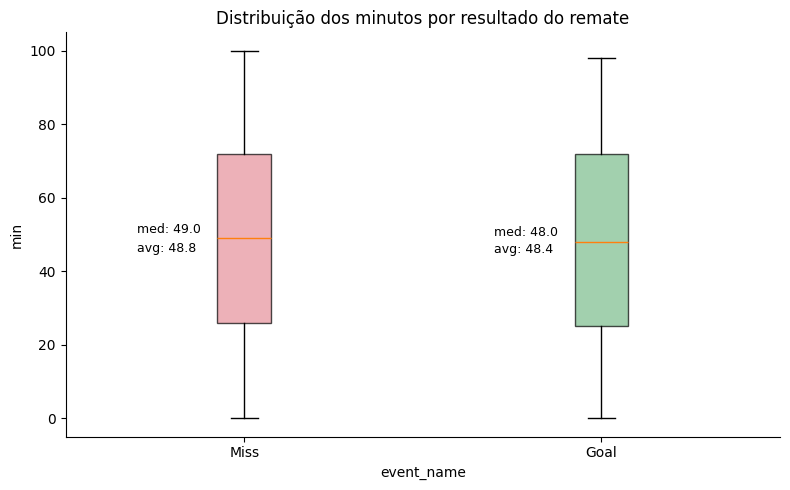

In [ ]:
numerical_boxplot(df_shots_explore, "min", "event_name", title = "Distribuição dos minutos por resultado do remate")

Os boxplots são bastante semelhantes, o que não é um bom indicador que a variável seja relevante para os modelos. Vamos ver o gráfico seguinte.

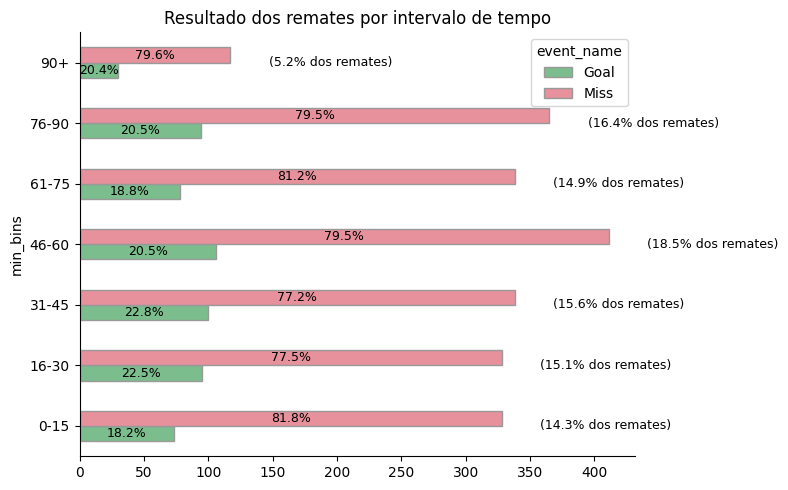

In [ ]:
bins = [0, 15, 30, 45, 60, 75, 90, 120]
labels = ["0-15", "16-30", "31-45", "46-60", "61-75", "76-90", "90+"]
df_shots_explore["min_bins"] = pd.cut(df_shots_explore["min"], bins = bins, labels = labels)

categorical_barplot(df_shots_explore, "min_bins", "event_name", title = "Resultado dos remates por intervalo de tempo")

O resultado também não é animador, visto que o sucesso de um remate varia apenas entre 18.8% e 22.8% nos diferentes intervalos de tempo testados, indiciando novamente pouco poder preditivo. Ainda assim, e embora já seja possível retirar uma conclusão geral do que o tempo não condiciona o desfecho de um remate, vamos manter por enquanto esta variável até ao momento de seleção de variáveis, em que poderemos avaliar com mais rigor se faz ou não sentido enviá-la para os modelos. <br><br>

### `team_id`, `home_team_id`, `home_team_name`, `away_team_id` e `away_team_name`
### +
### `season_id`, `competition_id`, `competition_name`, `game_id` e `timestamp`

Seguindo com um novo grupo de variáveis, podemos agora pegar nas equipas e, em simultâneo, analisar as épocas, competições e jogos que possuímos no nosso dataset.

In [ ]:
df_shots_explore[["competition_id", "competition_name", "season_id"]].value_counts(dropna = False)

,,,count
competition_id,competition_name,season_id,
99,Portuguese Primeira Liga,2020,2812


Os dados relevam para a temporada 2020/21 da liga portuguesa, não havendo valores em falta. Num cenário ideal, gostaríamos de ter todos os 9 x 34 = 306 jogos da época disponíveis (para este caso, vamos voltar a pegar no dataset `df_shots`, que contém todas as observações disponíveis).

In [ ]:
print("Total de jogos no dataset:", len(df_shots["game_id"].unique()))

Total de jogos no dataset: 300


Por pouco não temos os jogos todos, mas o facto de haver apenas 6 jogos em falta garante-nos que todas as equipas estão representadas.

Assim, e correndo o risco de cometer pequenas imprecisões dado o número de jogos em falta, __vamos criar uma variável auxiliar para contar o número de golos médio de golos marcados por jogo pela equipa que efetuou o remate até essa partida, e outra para contar o número médio de golos sofridos por jogo pela equipa que defende até ao mesmo instante__. Para este propósito, teremos de combinar os dados de treino e de validação novamente - mesmo assim, num cenário real em que este modelo estivesse em produção, esta informação (de golos marcados e sofridos por uma equipa num determinado momento) estaria disponível para o modelo efetuar a sua previsão no momento em que o remate acontece, pelo que não corremos o risco de o contaminar.

Seguindo uma lógica semelhante, __vamos também criar uma variável para identificar o número médio de remates por cada 10 minutos naquela partida em concreto.__ Ainda, criaremos uma para contabilizar o total de golos marcados e sofridos pela equipa até ao momento na partida.

__Nota:__ Para os jogos da primeira jornada, não haverá ainda uma média de golos marcados e sofridos. Vamos preencher os missing values com a média da equipa do total da temporada. Embora haja um risco de data leakage pelo facto de estarmos a usar dados do futuro, estamos a usar este valor apenas como proxy dos valores da temporada anterior, que seriam aqueles que muito provavelmente aplicaríamos num cenário de produção.

In [ ]:
# Começamos por converter o timestamp para data e ordenar (a coluna min é só em último recurso)
# Voltamos ao df_shots, que tem todas as observações e colunas
df_shots_aux = df_shots.copy()
df_shots_aux["timestamp"] = pd.to_datetime(df_shots_aux["timestamp"], format = "%Y-%m-%dT%H:%M:%S.%f")
df_shots_aux = df_shots_aux.sort_values(["timestamp", "game_id", "min"])

In [ ]:
# Variável auxiliar para identificar a equipa que está a defender o remate
df_shots_aux["defending_team_id"] = df_shots_aux.apply(
    lambda row: row["away_team_id"] if row["team_id"] == row["home_team_id"] else row["home_team_id"], axis = 1
)

In [ ]:
# Agrupar golos por jogo e por equipa que rematou e defendeu (criado com ajuda do Claude)
game_stats_off = df_shots_aux.groupby(["game_id", "team_id"]).agg(
    goals = ("event_name", lambda x: (x == "Goal").sum())
).reset_index()

game_stats_def = df_shots_aux.groupby(["game_id", "defending_team_id"]).agg(
    goals_conceded = ("event_name", lambda x: (x == "Goal").sum())
).reset_index()

In [ ]:
### 1. Média de golos marcados por jogo pela equipa que rematou
game_stats_off["avg_season_goals_scored"] = game_stats_off.groupby("team_id")["goals"].transform(
    lambda x: x.shift(1).expanding().mean()
)
# Preencher missing values com média da equipa
game_stats_off["avg_season_goals_scored"] = game_stats_off.groupby("team_id")["avg_season_goals_scored"].transform(
    lambda x: x.fillna(x.mean())
)
# Juntar novamente ao dataset
df_shots_aux = df_shots_aux.merge(
    game_stats_off[["game_id", "team_id", "avg_season_goals_scored"]],
    on = ["game_id", "team_id"],
    how = "left"
)

### 2. Média de golos sofridos por jogo pela equipa que defende
game_stats_def["avg_season_goals_conceded_opp"] = game_stats_def.groupby("defending_team_id")["goals_conceded"].transform(
    lambda x: x.shift(1).expanding().mean()
)
# Preencher missing values com média da equipa
game_stats_def["avg_season_goals_conceded_opp"] = game_stats_def.groupby("defending_team_id")["avg_season_goals_conceded_opp"].transform(
    lambda x: x.fillna(x.mean())
)
# Juntar novamente ao dataset
df_shots_aux = df_shots_aux.merge(
    game_stats_def[["game_id", "defending_team_id", "avg_season_goals_conceded_opp"]],
    on = ["game_id", "defending_team_id"],
    how = "left"
)

### 3. Média de remates
df_shots_aux["shots_per_10min_in_game"] = df_shots_aux.groupby(["game_id", "team_id"]).cumcount() / df_shots_aux["min"].replace(0, 1) * 10
df_shots_aux["shots_per_10min_in_game"] = df_shots_aux["shots_per_10min_in_game"].fillna(0)

### 4. Golos marcados no jogo (até ao momento) pela equipa que remata
df_shots_aux["game_goals_scored"] = df_shots_aux.groupby(["game_id", "team_id"])["event_name"].transform(
    lambda x: (x == "Goal").shift(1, fill_value = 0).cumsum()
)

### 5. Golos sofridos no jogo (até ao momento) pela equipa que remata
df_shots_aux["game_goals_temp"] = df_shots_aux.groupby(["game_id", "team_id"])["event_name"].transform(
    lambda x: (x == "Goal").shift(1, fill_value = 0).cumsum()
)
df_shots_aux["game_goals_conceded"] = df_shots_aux.apply(
    lambda row: df_shots_aux.loc[
        (df_shots_aux["game_id"] == row["game_id"]) &
        (df_shots_aux["team_id"] == row["defending_team_id"]) &
        (df_shots_aux["timestamp"] <= row["timestamp"])
    ]["game_goals_temp"].max(),
    axis = 1
)
df_shots_aux.drop(columns = ["game_goals_temp"], inplace = True)
df_shots_aux["game_goals_conceded"] = df_shots_aux["game_goals_conceded"].fillna(0).astype(int)

Agora que temos estas variáveis, podemos repensar uma delas. Na realidade, dificilmente o número de golos concedidos por uma equipa num jogo influencia a proabilidade de sucesso de um remate que venha a efetuar. Em vez disso, podemos experimentar criar uma variável binária para identificar se a equipa estava a perder no momento do remate - provavelmente também não terá impacto, mas poderá ter uma influência maior.

In [ ]:
df_shots_aux["is_losing"] = (df_shots_aux["game_goals_scored"] < df_shots_aux["game_goals_conceded"]).astype(int)

In [ ]:
# Verificar as primeiras 15 linhas para ver se parece tudo bem
df_shots_aux.head(15)

,event_name,period_id,min,sec,team_id,x,y,timestamp,player_id,keypass,competition_id,game_id,home_team_id,home_team_name,away_team_id,away_team_name,competition_name,season_id,374,375,395,396,Big Chance,Deflection,GK X Coordinate,GK Y Coordinate,Goal mouth y co-ordinate,Goal mouth z co-ordinate,Low left,Regular play,Right footed,Small box-centre,Standing,Zone,assist,280,281,282,328,Assisted,Box-centre,Fast break,High right,Intentional assist,Left footed,Low right,Swerve Left,353,390,Low centre,Penalty,Weak,Box-deep left,Head,Own goal,Set piece,Small box-right,1 on 1,273,388,From corner,Hit Woodwork,Keeper Touched,Out of box-centre,Individual Play,Box-left,Volley,254,Free kick,High centre,High left,Swerve Right,Box-deep right,Small box-left,Box-right,Other body part,2nd assisted,300,343,Throw-in set piece,274,275,Strong,362,Out of box-deep left,359,Out of box-left,35+ centre,389,Swerve Moving,276,391,Blocked x co-ordinate,Blocked y co-ordinate,Close left,Left,Not past goal line,Right,High,Close right,Close high,35+ right,Close right and high,233,Keeper Saved,314,Close left and high,Out of box-right,Out of box-deep right,35+ left,defending_team_id,avg_season_goals_scored,avg_season_goals_conceded_opp,shots_per_10min_in_game,game_goals_scored,game_goals_conceded,is_losing
0,Miss,1,6,28,251,91.9,49.1,2020-09-18 19:06:02.122,447203,-,99,2133169,6644,FC Famalicão,251,Benfica,Portuguese Primeira Liga,2020,NaN,NaN,NaN,NaN,NaN,NaN,99.0,49.1,52.9,69.4,NaN,-,-,NaN,-,Center,-,NaN,NaN,NaN,sim,sim,sim,NaN,NaN,sim,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-,NaN,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-,NaN,NaN,NaN,sim,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6644,2.213678,1.819173,0.000000,0,0,0
1,Miss,1,7,52,251,95.7,66.1,2020-09-18 19:07:25.691,168143,-,99,2133169,6644,FC Famalicão,251,Benfica,Portuguese Primeira Liga,2020,NaN,NaN,NaN,NaN,NaN,NaN,99.3,52.9,57.1,23.6,NaN,sim,-,NaN,sim,Center,-,NaN,NaN,NaN,-,sim,-,NaN,NaN,-,sim,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,sim,NaN,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,sim,NaN,NaN,NaN,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6644,2.213678,1.819173,1.428571,0,0,0
2,Goal,1,18,11,251,87.2,61.5,2020-09-18 19:17:45.272,168143,-,99,2133169,6644,FC Famalicão,251,Benfica,Portuguese Primeira Liga,2020,2020-09-18 19:17:43.653,18:10.262,91.0,59.0,sim,NaN,90.6,59.2,50.7,6.3,NaN,sim,-,-,sim,Center,-,PASS_LOST,447203,251,-,-,sim,NaN,-,-,sim,-,NaN,NaN,NaN,sim,NaN,sim,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-,sim,NaN,NaN,-,-,-,-,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6644,2.213678,1.819173,1.111111,0,0,0
3,Goal,1,20,38,251,80.7,50.4,2020-09-18 19:20:12.197,179531,-,99,2133169,6644,FC Famalicão,251,Benfica,Portuguese Primeira Liga,2020,2020-09-18 19:20:11.333,20:37.942,98.5,47.5,-,NaN,98.8,50.0,46.0,0.6,NaN,sim,sim,-,sim,Center,-,-,-,-,sim,sim,-,NaN,-,sim,-,sim,NaN,NaN,NaN,-,NaN,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,sim,sim,NaN,NaN,-,-,-,-,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6644,2.213678,1.819173,1.500000,1,0,0
4,Miss,1,22,12,251,97.5,40.9,2020-09-18 19:21:46.081,148515,-,99,2133169,6644,FC Famalicão,251,Benfica,Portuguese Primeira Liga,2020,NaN,NaN,NaN,NaN,NaN,NaN,100,46.8,64.9,1.4,NaN,sim,sim,NaN,sim,Center,-,NaN,NaN,NaN,sim,sim,-,NaN,NaN,sim,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-,NaN,sim,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-,NaN,NaN,NaN,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6644,2.213678,1.819173,1.818182,2,0,0
5,Miss,1,23,2,251,93.4,

In [ ]:
# E já agora, as últimas 15 linhas também
df_shots_aux.tail(15)

,event_name,period_id,min,sec,team_id,x,y,timestamp,player_id,keypass,competition_id,game_id,home_team_id,home_team_name,away_team_id,away_team_name,competition_name,season_id,374,375,395,396,Big Chance,Deflection,GK X Coordinate,GK Y Coordinate,Goal mouth y co-ordinate,Goal mouth z co-ordinate,Low left,Regular play,Right footed,Small box-centre,Standing,Zone,assist,280,281,282,328,Assisted,Box-centre,Fast break,High right,Intentional assist,Left footed,Low right,Swerve Left,353,390,Low centre,Penalty,Weak,Box-deep left,Head,Own goal,Set piece,Small box-right,1 on 1,273,388,From corner,Hit Woodwork,Keeper Touched,Out of box-centre,Individual Play,Box-left,Volley,254,Free kick,High centre,High left,Swerve Right,Box-deep right,Small box-left,Box-right,Other body part,2nd assisted,300,343,Throw-in set piece,274,275,Strong,362,Out of box-deep left,359,Out of box-left,35+ centre,389,Swerve Moving,276,391,Blocked x co-ordinate,Blocked y co-ordinate,Close left,Left,Not past goal line,Right,High,Close right,Close high,35+ right,Close right and high,233,Keeper Saved,314,Close left and high,Out of box-right,Out of box-deep right,35+ left,defending_team_id,avg_season_goals_scored,avg_season_goals_conceded_opp,shots_per_10min_in_game,game_goals_scored,game_goals_conceded,is_losing
3501,Miss,1,11,31,255,84.8,60.0,2021-05-19 21:58:31.389,166498,-,99,2133472,255,Sporting CP,740,Marítimo,Portuguese Primeira Liga,2020,NaN,NaN,NaN,NaN,NaN,NaN,97.8,51.4,37.0,13.9,NaN,sim,sim,NaN,NaN,Center,-,NaN,NaN,NaN,sim,sim,sim,NaN,-,sim,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-,NaN,NaN,NaN,NaN,NaN,NaN,-,NaN,NaN,-,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-,NaN,NaN,NaN,NaN,NaN,-,-,NaN,-,-,sim,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,740,1.781250,1.242424,0.909091,1,0,0
3502,Miss,1,13,0,740,70.5,84.8,2021-05-19 21:59:59.780,201021,-,99,2133472,255,Sporting CP,740,Marítimo,Portuguese Primeira Liga,2020,NaN,NaN,NaN,NaN,NaN,NaN,97.5,48.9,46.4,90.3,NaN,sim,-,NaN,NaN,Left,-,NaN,NaN,NaN,-,sim,-,NaN,-,-,sim,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-,NaN,NaN,NaN,NaN,NaN,NaN,-,NaN,NaN,-,sim,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,sim,NaN,NaN,NaN,NaN,NaN,-,-,NaN,-,-,-,sim,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,255,0.818182,0.580645,0.769231,0,1,1
3503,Goal,1,19,0,255,91.9,54.7,2021-05-19 22:06:00.144,433145,-,99,2133472,255,Sporting CP,740,Marítimo,Portuguese Primeira Liga,2020,2021-05-19 22:05:59.599,18:59.897,NaN,NaN,sim,NaN,97.6,51.4,49.3,0.6,-,sim,sim,NaN,NaN,Center,-,POST,437911,255,-,-,sim,NaN,NaN,-,-,-,NaN,NaN,NaN,sim,NaN,NaN,NaN,NaN,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-,-,-,NaN,-,NaN,NaN,NaN,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,740,1.781250,1.242424,1.052632,1,0,0
3504,Goal,1,20,32,740,26.1,19.7,2021-05-19 22:07:31.974,213933,-,99,2133472,255,Sporting CP,740,Marítimo,Portuguese Primeira Liga,2020,2021-05-19 22:07:29.917,20:30.215,NaN,NaN,-,NaN,89.1,54.2,45.7,4.4,-,sim,-,NaN,NaN,Left,-,-,-,-,-,-,-,NaN,NaN,-,sim,sim,NaN,NaN,NaN,-,NaN,NaN,NaN,NaN,sim,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-,-,-,NaN,-,NaN,NaN,NaN,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,sim,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,255,0.818182,0.580645,1.000000,0,1,1
3505,Miss,1,32,37,740,90.6,45.2,2021-05-19 22:19:36.855,213933,-,99,2133472,255,Sporting CP,740,Marítimo,Portuguese Primeira Liga,2020,NaN,NaN,NaN,NaN,NaN,NaN,-,-,86.9,9.7,NaN,-,-,NaN,NaN,Center,-,NaN,NaN,NaN,sim,sim,sim,NaN,-,sim,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,sim,NaN,NaN,NaN,NaN,NaN,NaN,sim,NaN,NaN,-,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-,NaN,NaN,NaN,NaN,NaN,92.5,52.2,NaN,sim,sim,-,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,255,0.818182,0.580645,0.937500,1,1,0
3506,Miss,2,48,43,255,76.3,41.9,2021-05-19 22:53:07.786,26904,-,99,2

Parece tudo bem. Vamos então trazer as colunas para os nossos datasets.

In [ ]:
cols_history = ["avg_season_goals_scored", "avg_season_goals_conceded_opp", "shots_per_10min_in_game", "game_goals_scored", "game_goals_conceded", "is_losing"]

for df in df_shots_X:
  df[cols_history] = df_shots_aux.loc[df.index, cols_history]

Após estas transformações, podemos analisar estas novas colunas e a sua relação com o target.

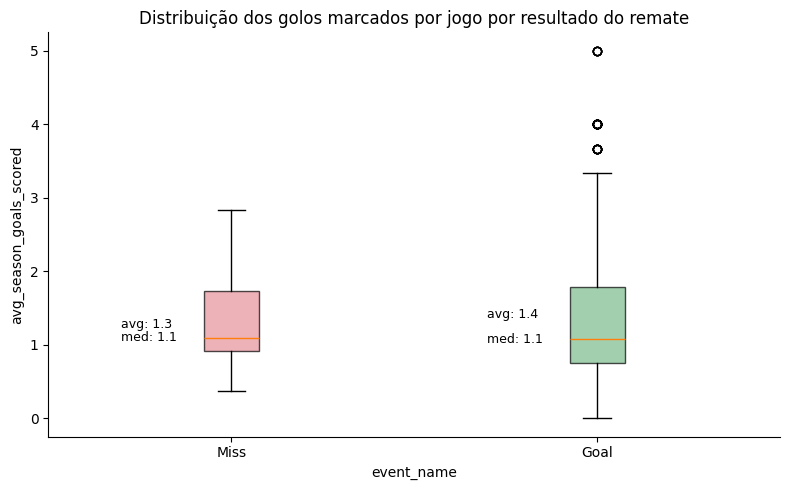

In [ ]:
numerical_boxplot(df_shots_explore, "avg_season_goals_scored", "event_name",
                  title = "Distribuição dos golos marcados por jogo por resultado do remate",
                  offset = 0)

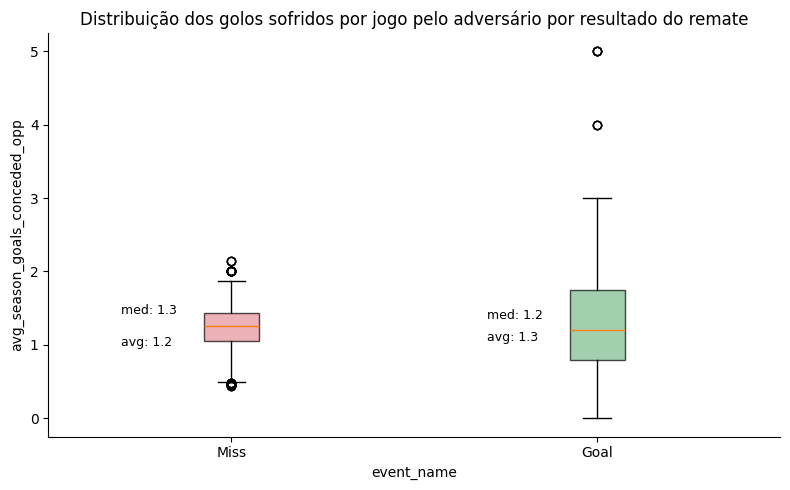

In [ ]:
numerical_boxplot(df_shots_explore, "avg_season_goals_conceded_opp", "event_name",
                  title = "Distribuição dos golos sofridos por jogo pelo adversário por resultado do remate",
                  offset = 0.2)

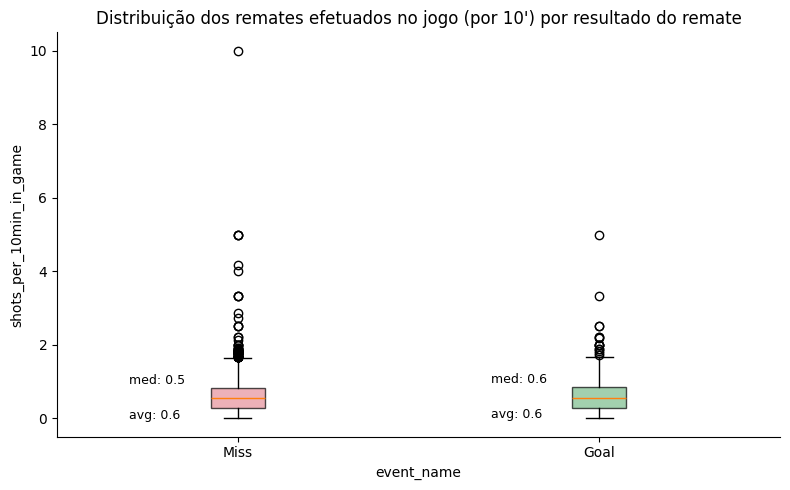

In [ ]:
numerical_boxplot(df_shots_explore, "shots_per_10min_in_game", "event_name",
                  title = "Distribuição dos remates efetuados no jogo (por 10') por resultado do remate",
                  offset = 0.5)

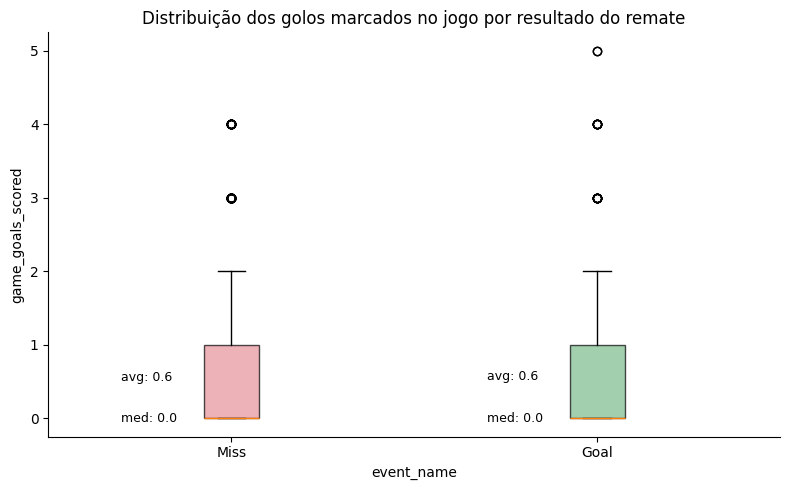

In [ ]:
numerical_boxplot(df_shots_explore, "game_goals_scored", "event_name",
                  title = "Distribuição dos golos marcados no jogo por resultado do remate",
                  offset = 0)

In [ ]:
df_shots_explore["game_goals_scored"].value_counts(dropna = False)

,count
game_goals_scored,
0,1706
1,750
2,272
3,54
4,28
5,2


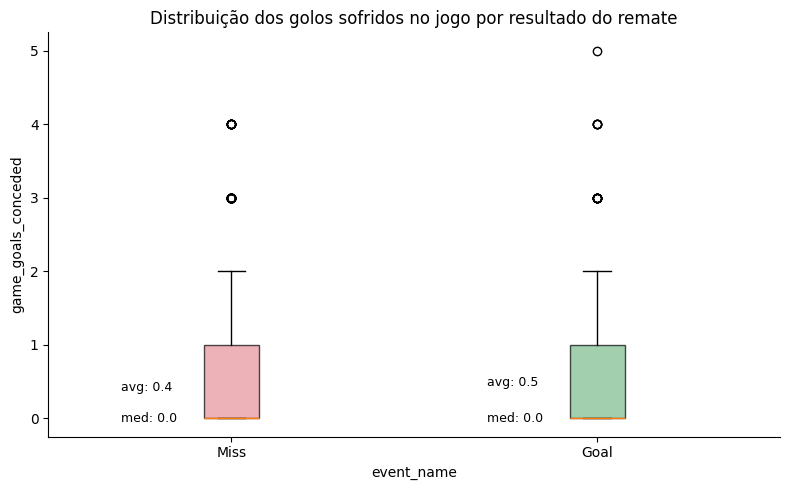

In [ ]:
numerical_boxplot(df_shots_explore, "game_goals_conceded", "event_name",
                  title = "Distribuição dos golos sofridos no jogo por resultado do remate",
                  offset = 0)

In [ ]:
df_shots_explore["game_goals_conceded"].value_counts(dropna = False)

,count
game_goals_conceded,
0,1949
1,591
2,212
3,45
4,14
5,1


Vamos descartar as colunas `shots_per_10min_in_game`, `game_goals_scored` e `game_goals_conceded`, cujas distribuições deixam antever que não têm qualquer poder preditivo e podem acabar por prejudicar mais os modelos do que beneficiar.

As duas restantes variáveis numéricas que criámos (`avg_season_goals_scored` e `avg_season_goals_conceded_opp`) parecem ter um poder preditivo superior ao observado no grupo das variáveis temporais que abordámos anteriormente, ainda que possam acabar por não ser relevantes. Apresentam também alguns outliers, embora seja pouco provável que venhamos a eliminar essas observações - não estão assim tão distantes do intervalo [Q1 - 1.5 * IQR, Q3 + 1.5 * IQR], e mesmo nos poucos casos onde estão, até poderão ser úteis ainda assim.

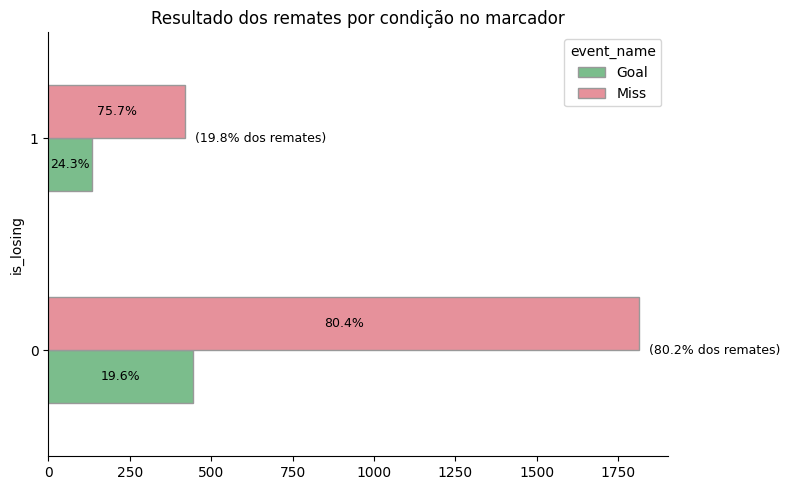

In [ ]:
categorical_barplot(df_shots_explore, "is_losing", "event_name", title = "Resultado dos remates por condição no marcador")

Por outro lado, parece que a percentagem de remates que dão golo apresenta uma tendência para ser inferior quando efetuado por equipas que se encontram em desvantagem. Até é algo que faz sentido se pensarmos no contexto real: se a equipa está a perder, é bem possível que seja inferior ao seu adversário e, consequentemente, tenha maiores dificuldades para marcar.

Antes de prosseguirmos, podemos ainda criar uma outra variável para identificar se o remate foi feito pela equipa da casa e avaliar o seu potencial interesse.

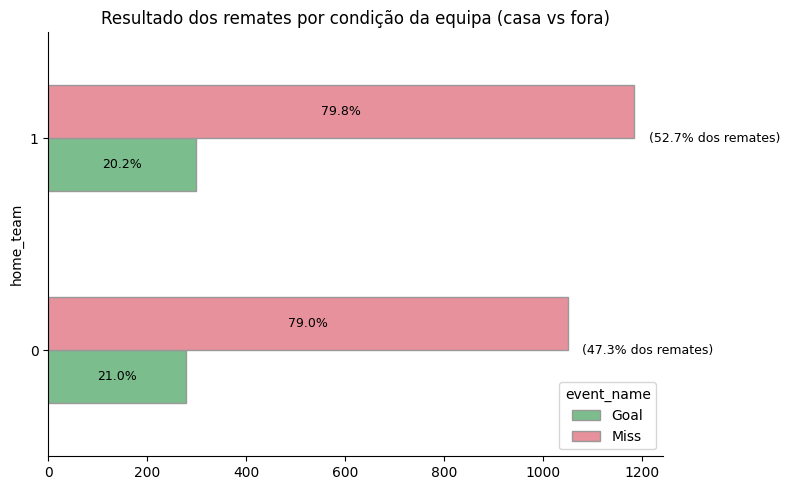

In [ ]:
df_shots_explore["home_team"] = (df_shots_explore["team_id"] == df_shots_explore["home_team_id"]).astype(int)

categorical_barplot(df_shots_explore, "home_team", "event_name", title = "Resultado dos remates por condição da equipa (casa vs fora)")

Esta variável não parece ser relevante para efetuar a previsão. Além de a distribuição dos valores da variável ser praticamente 50-50, a percentagem de remates que deram golo em cada categoria é bastante semelhante. Assim, não vale a pena estar a criá-la para os datasets de treino e validação. Assim, vamos eliminar as colunas que já não iremos utilizar e avançar para o próximo grupo.

In [ ]:
# Vamos manter a coluna de timestamp, que ainda pode dar jeito mais adiante
cols_context = ["team_id", "home_team_id", "home_team_name", "away_team_id", "away_team_name",
                "season_id", "competition_id", "competition_name", "game_id",
                "shots_per_10min_in_game", "game_goals_scored", "game_goals_conceded"]

for df in df_shots_X:
  df.drop(columns = cols_context, inplace = True)
  print(df.shape)

(2812, 36)
(704, 36)
(2812, 42)


### `x`, `y`, `GK X Coordinate`, `GK Y Coordinate` e `Zone`
### +
### `Out of box-centre`, `Box-centre`, `Box-left`, `Box-right`, `Small box-left`, `Small box-centre`, `Small box-right`
Chegados ao grupo de variáveis relacionados com coordenadas, podemos começar por olhar para as colunas `x` e `y`, que identificam onde foi efetuado o remate.

In [ ]:
df_shots_explore[["x", "y"]].describe()

,x,y
count,2812.000000,2812.000000
mean,84.557361,50.600676
std,10.648411,12.297845
min,1.100000,3.700000
25%,78.200000,42.900000
50%,87.350000,50.300000
75%,91.600000,58.500000
max,99.300000,94.400000


Pelo valor mínimo da coluna `x`, parece haver aqui alguns potenciais outliers. Ainda, assim, os quartis e a média parecem valores razoáveis (aliás, a média da coluna `y` é praticamente a meio do campo numa perspetiva de largura). Antes de olharmos para estes potenciais valores extremos, podemos aproveitar o código do notebook de exemplo e analisar de onde são feitos os remates, bem como o heatmap dos mesmos em função do seu sucesso.

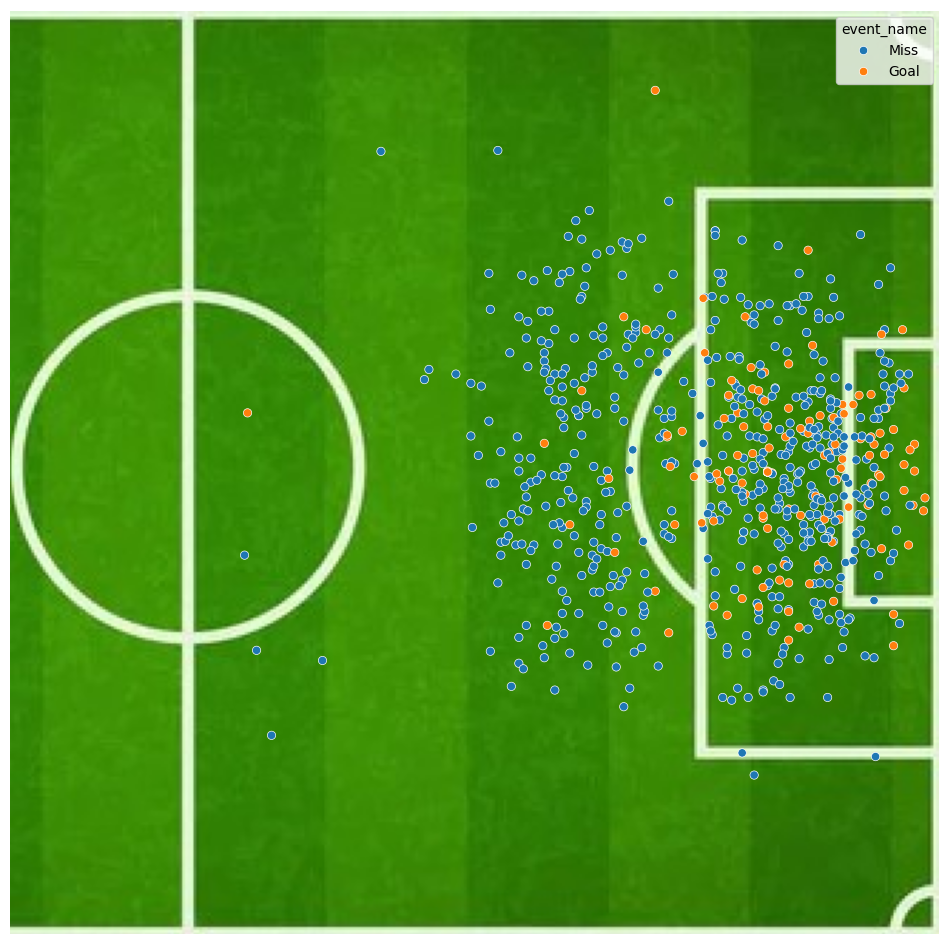

In [ ]:
img = plt.imread("field_background.jpg")
df_norm = pd.DataFrame()
fig, ax = plt.subplots(figsize = (12, 12))
df_norm["x_norm"] = (df_shots_explore["x"]/100) * img.shape[1]
df_norm["y_norm"] = (df_shots_explore["y"]/100) * img.shape[0]
df_norm["event_name"] = df["event_name"]

sns.scatterplot(data = df_norm.sample(n = 700, random_state = 1), x = "x_norm", y = "y_norm", hue = "event_name")

plt.xlim(200, img.shape[1])
plt.ylim(0, img.shape[0])
plt.axis("off")

ax.imshow(img, aspect = "auto")

(np.float64(200.0), np.float64(527.0), np.float64(0.0), np.float64(326.0))

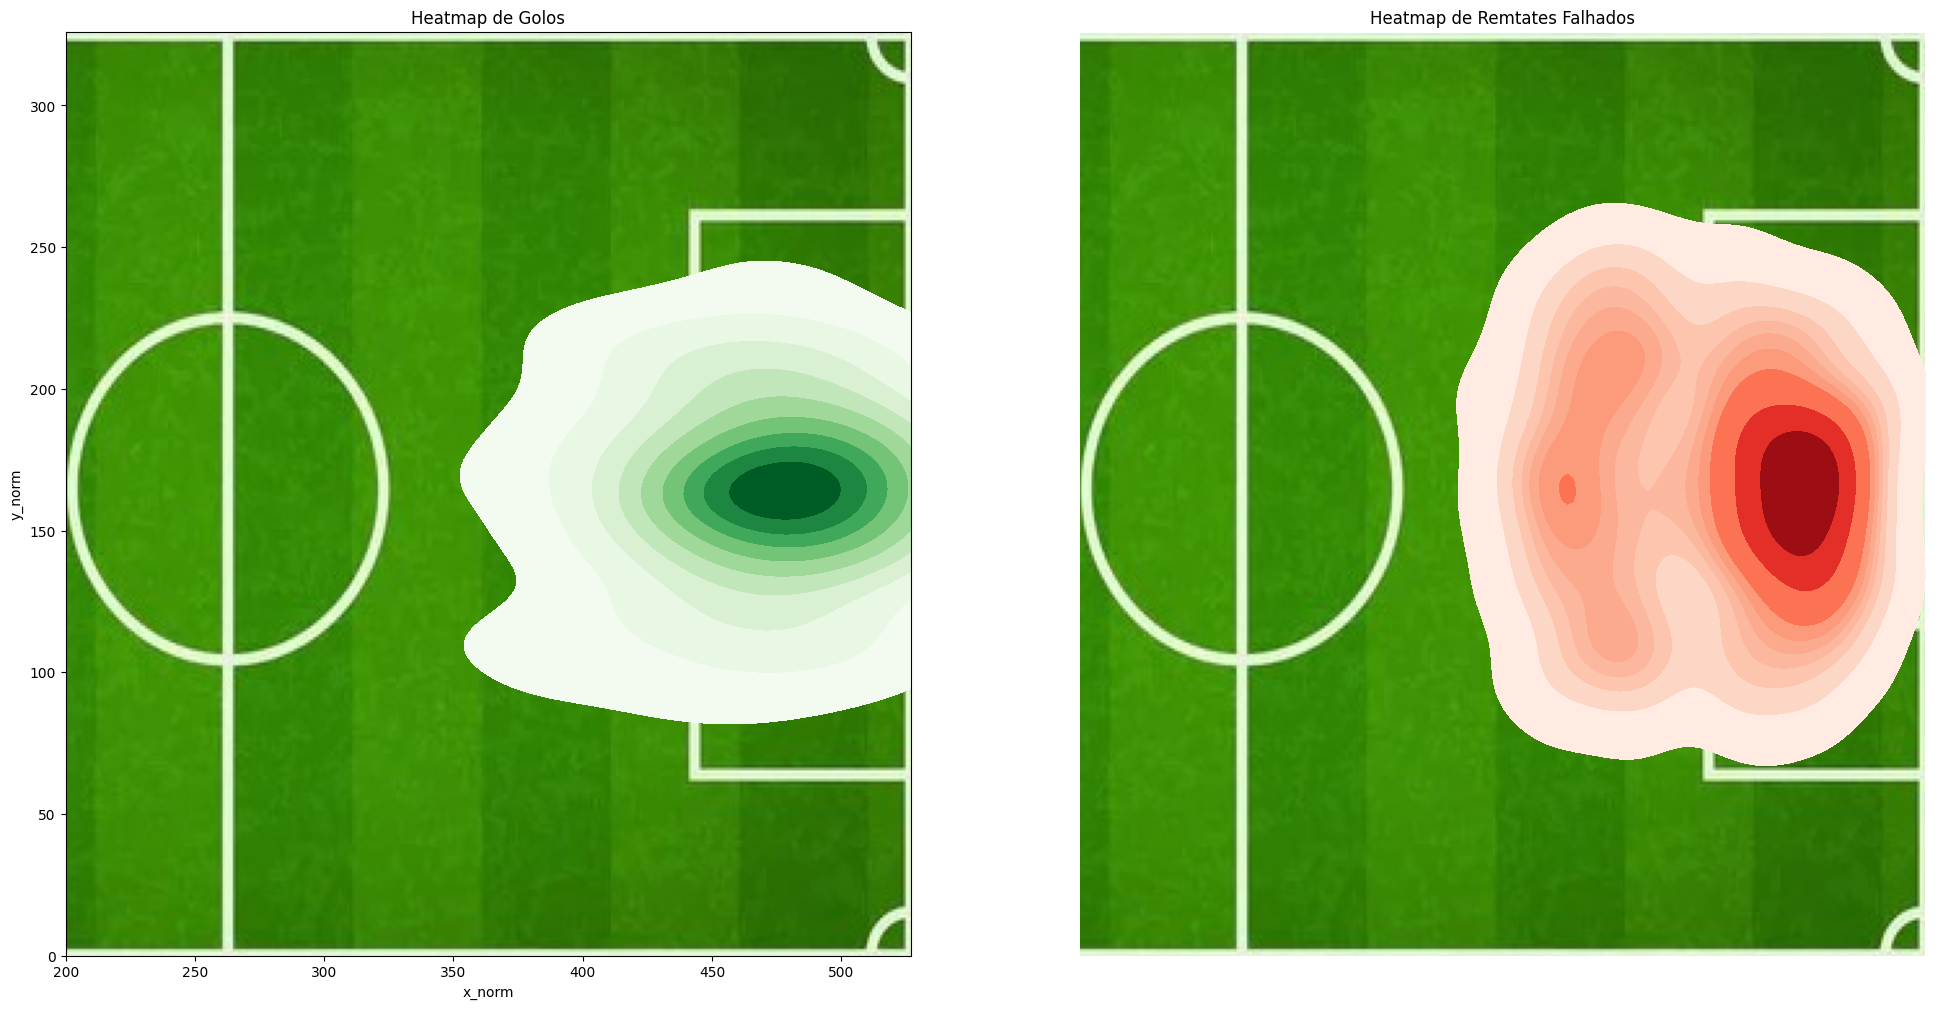

In [ ]:
fig, ax = plt.subplots(1, 2, figsize = (24 ,12))
sns.kdeplot(x = df_norm[df_norm["event_name"] == "Goal"]["x_norm"],
            y = df_norm[df_norm["event_name"] == "Goal"]["y_norm"],
            cmap = "Greens", fill = True, ax = ax[0])
sns.kdeplot(x = df_norm[df_norm["event_name"] == "Miss"]["x_norm"],
            y = df_norm[df_norm["event_name"] == "Miss"]["y_norm"],
            cmap = "Reds", fill = True, ax = ax[1])

ax[0].set_xlim(200, img.shape[1])
ax[0].set_ylim(0, img.shape[0])

ax[1].set_xlim(200, img.shape[1])
ax[1].set_ylim(0, img.shape[0])

ax[0].set_title("Heatmap de Golos")
ax[1].set_title("Heatmap de Remtates Falhados")

ax[0].imshow(img, aspect = "auto")
ax[1].imshow(img, aspect = "auto")

plt.axis("off")

Como expectável, existem zonas do terreno muito mais propícias a verem os remates dar golo. Em particular, a grande área (onde ocorre a maior parte dos remates) é onde se verifica a maior percentagem de golos. Além disso, constatamos que, quando mais próximos e centrais os remates em relação à baliza, maior a probabilidade de golo.

Assim, __vamos criar 3 novas variáveis para identificar a distância e o ângulo do remate em relação à baliza, bem como uma variável binária para identificar remates efetuados dentro da grande área__.

In [ ]:
for df in df_shots_X:
  # Distância (euclidiana) até ao centro da baliza
  df["shot_distance"] = np.sqrt((100 - df["x"]) ** 2 + (50 - df["y"]) ** 2)
  # Ângulo do remate (em graus) em relação ao centro da baliza
  df["shot_angle"] = np.degrees(np.arctan2(np.abs(50 - df["y"]), (100 - df["x"])))
  # Variável binária para identificar remates feitos dentro da grande área
  df["shot_inside_box"] = (
    (df["x"] >= 83) &
    (df["y"] >= 21.1) &
    (df["y"] <= 78.9)
  ).astype(int)

df_shots_explore.head()

,period_id,min,x,y,timestamp,player_id,keypass,Big Chance,GK X Coordinate,GK Y Coordinate,Regular play,Right footed,Small box-centre,Zone,assist,Assisted,Box-centre,Fast break,Intentional assist,Left footed,Penalty,Head,Set piece,Small box-right,From corner,Out of box-centre,Individual Play,Box-left,Volley,Free kick,Small box-left,Box-right,Throw-in set piece,event_name,added_time_1st_half,added_time_2nd_half,added_time,min_bins,avg_season_goals_scored,avg_season_goals_conceded_opp,is_losing,home_team,shot_distance,shot_angle,shot_inside_box
3410,2,85,86.8,32.2,2021-04-22T22:45:01.542,178867,-,NaN,97.6,46.4,-,sim,NaN,Center,-,sim,NaN,sim,sim,-,NaN,NaN,-,NaN,-,-,sim,NaN,-,NaN,NaN,sim,NaN,Miss,0,0,0,76-90,1.161290,1.580645,0,1,22.160325,53.440365,1
687,2,83,91.0,44.6,2021-04-20T21:43:56.591,183981,-,sim,91.1,41.9,sim,NaN,NaN,Center,-,sim,sim,NaN,NaN,sim,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Goal,0,0,0,76-90,0.666667,1.000000,0,0,10.495713,30.963757,1
363,2,68,73.2,74.5,2020-10-25T18:58:35.802,469205,-,-,99.1,50.7,sim,-,NaN,Center,-,sim,-,NaN,-,sim,-,-,-,NaN,NaN,sim,sim,NaN,NaN,-,NaN,NaN,NaN,Goal,0,0,0,61-75,1.000000,1.666667,0,0,36.311018,42.432903,0
28,1,41,81.5,32.5,2020-09-18T19:40:56.105,106004,-,-,99.0,50.2,-,-,-,Center,-,-,-,NaN,-,sim,NaN,NaN,NaN,NaN,NaN,sim,-,NaN,NaN,sim,NaN,NaN,NaN,Goal,0,0,0,31-45,1.156299,1.414686,0,0,25.465663,43.408860,0
1946,2,74,89.8,68.0,2021-04-25T21:34:25.102,155476,-,NaN,98.2,55.1,sim,-,NaN,Center,-,sim,-,NaN,sim,sim,NaN,-,NaN,NaN,-,-,-,sim,-,NaN,NaN,NaN,NaN,Miss,0,0,0,61-75,1.777778,1.294118,0,1,20.689128,60.461218,1


In [ ]:
df_shots_train.head()

,period_id,min,x,y,timestamp,player_id,keypass,Big Chance,GK X Coordinate,GK Y Coordinate,Regular play,Right footed,Small box-centre,Zone,assist,Assisted,Box-centre,Fast break,Intentional assist,Left footed,Penalty,Head,Set piece,Small box-right,From corner,Out of box-centre,Individual Play,Box-left,Volley,Free kick,Small box-left,Box-right,Throw-in set piece,avg_season_goals_scored,avg_season_goals_conceded_opp,is_losing,shot_distance,shot_angle,shot_inside_box
3410,2,85,86.8,32.2,2021-04-22T22:45:01.542,178867,-,NaN,97.6,46.4,-,sim,NaN,Center,-,sim,NaN,sim,sim,-,NaN,NaN,-,NaN,-,-,sim,NaN,-,NaN,NaN,sim,NaN,1.161290,1.580645,0,22.160325,53.440365,1
687,2,83,91.0,44.6,2021-04-20T21:43:56.591,183981,-,sim,91.1,41.9,sim,NaN,NaN,Center,-,sim,sim,NaN,NaN,sim,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.666667,1.000000,0,10.495713,30.963757,1
363,2,68,73.2,74.5,2020-10-25T18:58:35.802,469205,-,-,99.1,50.7,sim,-,NaN,Center,-,sim,-,NaN,-,sim,-,-,-,NaN,NaN,sim,sim,NaN,NaN,-,NaN,NaN,NaN,1.000000,1.666667,0,36.311018,42.432903,0
28,1,41,81.5,32.5,2020-09-18T19:40:56.105,106004,-,-,99.0,50.2,-,-,-,Center,-,-,-,NaN,-,sim,NaN,NaN,NaN,NaN,NaN,sim,-,NaN,NaN,sim,NaN,NaN,NaN,1.156299,1.414686,0,25.465663,43.408860,0
1946,2,74,89.8,68.0,2021-04-25T21:34:25.102,155476,-,NaN,98.2,55.1,sim,-,NaN,Center,-,sim,-,NaN,sim,sim,NaN,-,NaN,NaN,-,-,-,sim,-,NaN,NaN,NaN,NaN,1.777778,1.294118,0,20.689128,60.461218,1


Vamos visualizar a segunda observação para confirmar que está tudo bem.

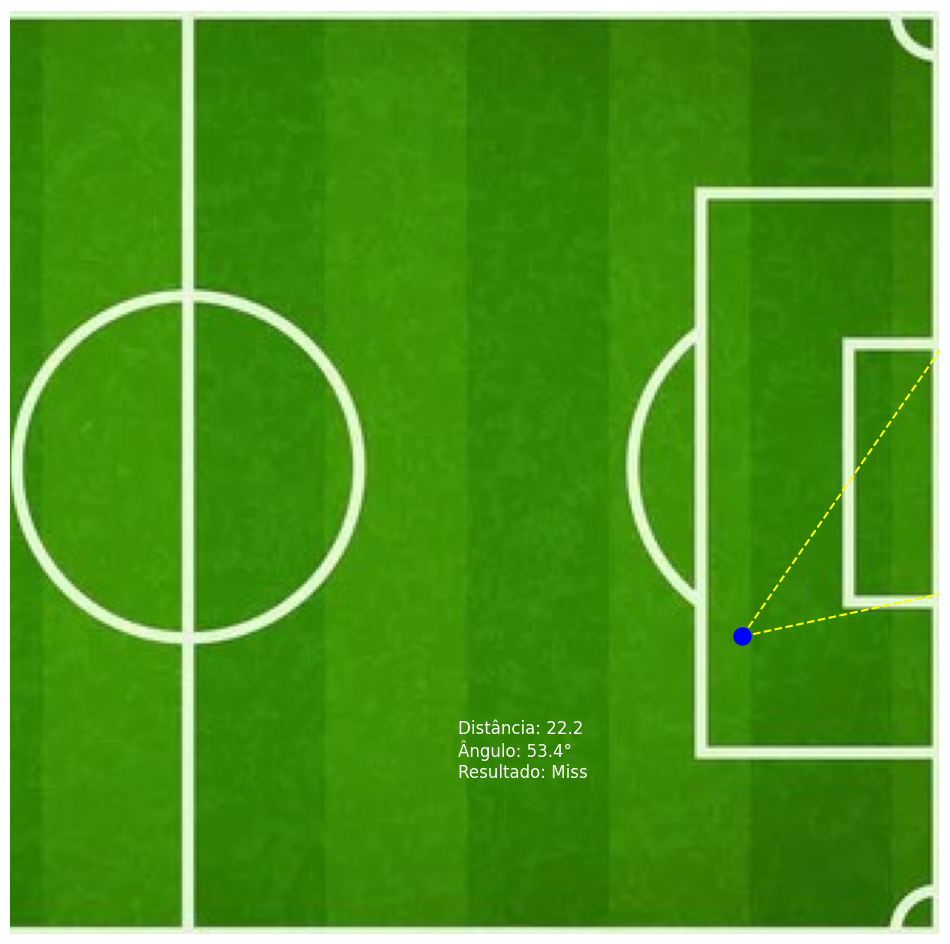

In [ ]:
img = plt.imread("field_background.jpg")
fig, ax = plt.subplots(figsize = (12, 12))

# Normalizar coordenadas para o gráfico
first_obs = df_shots_explore.iloc[[0]]
x_norm = (first_obs["x"].values[0] / 100) * img.shape[1]
y_norm = (first_obs["y"].values[0] / 100) * img.shape[0]

# Desenhar postes para referência
post1_y_norm = (36.8 / 100) * img.shape[0]
post2_y_norm = (63.2 / 100) * img.shape[0]
goal_x_norm = (100 / 100) * img.shape[1]

# Localizar remate
ax.scatter(x_norm, y_norm, color = "blue", s = 150, zorder = 5)

# Desenhar linhas até aos postes
ax.plot([x_norm, goal_x_norm], [y_norm, post1_y_norm], color = "yellow", linestyle = "--", linewidth = 1.5)
ax.plot([x_norm, goal_x_norm], [y_norm, post2_y_norm], color = "yellow", linestyle = "--", linewidth = 1.5)

# Juntar distância, ângulo e outcome do remate
ax.annotate(f"Distância: {first_obs["shot_distance"].values[0]:.1f}\nÂngulo: {first_obs["shot_angle"].values[0]:.1f}°\nResultado: {first_obs["event_name"].values[0]}",
            xy = (x_norm, y_norm), xytext = (x_norm - 100, y_norm - 50), fontsize = 12, color = "white")

plt.xlim(200, img.shape[1])
plt.ylim(0, img.shape[0])
plt.axis("off")
ax.imshow(img, aspect = "auto")
plt.show()

Ótimo, parece fazer sentido. Vamos agora fazer um boxplot/bar plot para estas variáveis, semelhantes aos que já efetuámos anteriormente, para avaliar a sua correlação com o target e, consequentemente, tirar alguns insights sobre o seu poder preditivo.

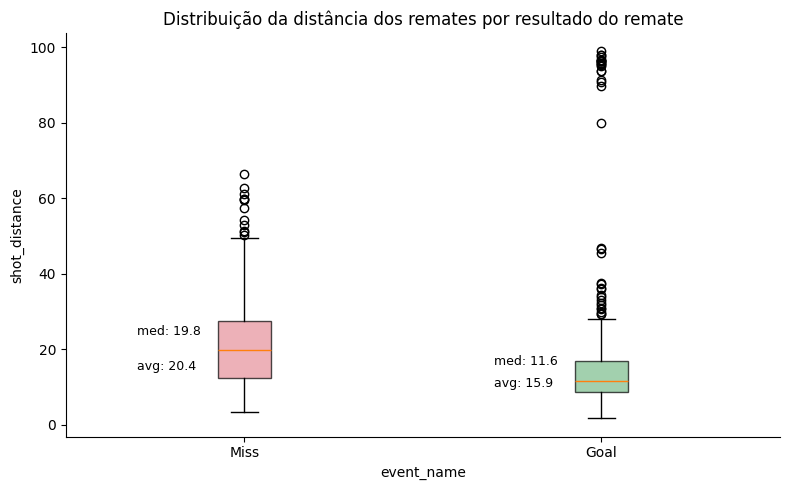

In [ ]:
numerical_boxplot(df_shots_explore, "shot_distance", "event_name",
                  title = "Distribuição da distância dos remates por resultado do remate",
                  offset = 5)

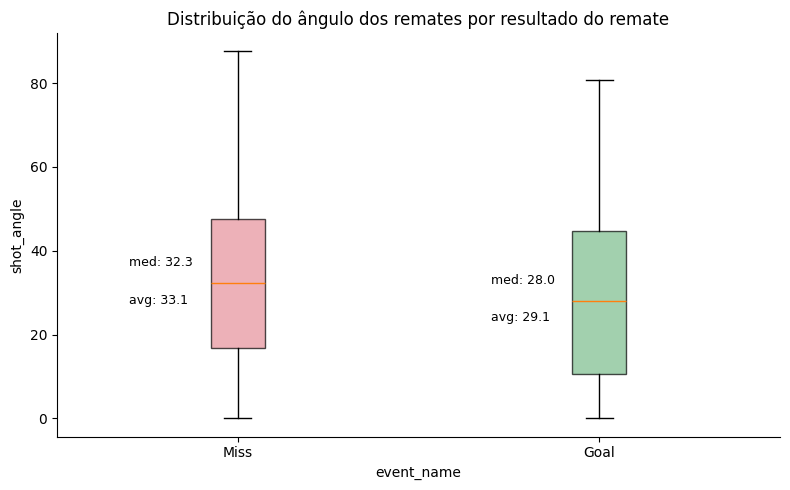

In [ ]:
numerical_boxplot(df_shots_explore, "shot_angle", "event_name",
                  title = "Distribuição do ângulo dos remates por resultado do remate",
                  offset = 5)

As duas variáveis (especialmente a `shot_distance`, que diz respeito à distância do remate até à baliza) parecem ser potencialmente relevantes para prever o sucesso do remate, visto que exibem um comportamento diferente para cada categoria do target. Como esperado, remates efetuados mais próximo e mais centrais face à baliza têm maior probabilidade de resultar em golo.

Além disso, voltamos a notar a presença de alguns outliers, que muito provavelmente até serão os mesmos que identificámos existir para a coluna `x`.

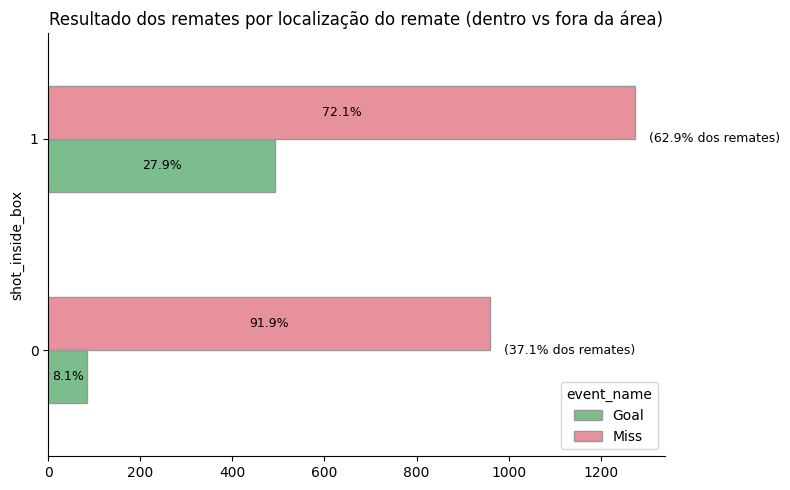

In [ ]:
categorical_barplot(df_shots_explore, "shot_inside_box", "event_name", title = "Resultado dos remates por localização do remate (dentro vs fora da área)")

Esta variável também aparenta ser bastante útil para efetuar a previsão: enqunto apenas 8.1% dos remates feitos fora da grande área deram golo, essa percentagem mais que triplica, para 27.9%, para remates feitos dentro da área do adversário.

Vamos agora voltar atenções para as coordenadas de posicionamento do guarda-redes no momento do remate.

In [ ]:
# Temos de começar por converter estas colunas em numéricas (onde não for possível, passremos a ter missing values)
df_shots_explore["GK X Coordinate"] = pd.to_numeric(df_shots_explore["GK X Coordinate"], errors = "coerce")
df_shots_explore["GK Y Coordinate"] = pd.to_numeric(df_shots_explore["GK Y Coordinate"], errors = "coerce")

df_shots_explore[["GK X Coordinate", "GK Y Coordinate"]].describe()

,GK X Coordinate,GK Y Coordinate
count,2801.000000,2801.000000
mean,90.880221,49.970332
std,25.398298,3.047657
min,0.000000,17.100000
25%,97.700000,48.700000
50%,98.500000,50.000000
75%,99.000000,51.100000
max,100.000000,76.900000


Identificamos 11 linhas (2812, que eram o total, menos as 2801 contadas) onde não foi possível converter os dados para formato numérico. É um valor que podemos aceitar e até acabar por eliminar estas observações.

Vamos ver num gráfico onde se encontravam os guarda-redes aquando dos remates.

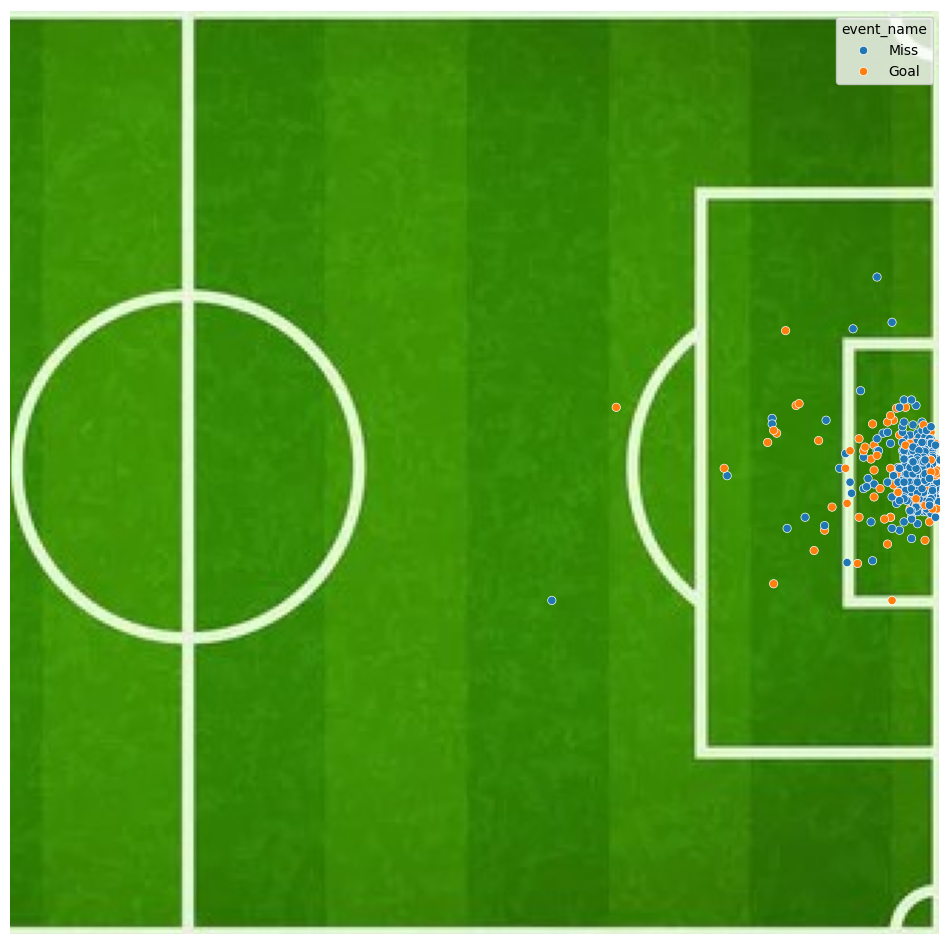

In [ ]:
img = plt.imread("field_background.jpg")
df_norm = pd.DataFrame()
fig, ax = plt.subplots(figsize = (12, 12))
df_norm["gk_x_norm"] = (df_shots_explore["GK X Coordinate"]/100) * img.shape[1]
df_norm["gk_y_norm"] = (df_shots_explore["GK Y Coordinate"]/100) * img.shape[0]
df_norm["event_name"] = df["event_name"]

sns.scatterplot(data = df_norm.sample(n = 700, random_state = 1), x = "gk_x_norm", y = "gk_y_norm", hue = "event_name")

plt.xlim(200, img.shape[1])
plt.ylim(0, img.shape[0])
plt.axis("off")

ax.imshow(img, aspect = "auto")

Como seria de esperar, na maioria das situações os guarda-redes encontram-se dentro da sua pequena área, embora haja novamente alguns outliers (que também eram observáveis através dos valores mínimos na descrição da célula anterior). Neste caso, dificilmente teremos interesse em manter as colunas de coordenadas dos guarda-redes propriamente ditas, uma vez que são valores largamente concentrados numa zona do terreno. Podemos, ainda assim, criar uma nova variável auxiliar para calcular a distância entre a bola e o guarda-redes no momento do remate, e avaliar se pode ser útil para transmitir aos nossos modelos.

__Nota:__ Poderíamos criar também uma coluna para identificar a distância entre o guarda-redes e a baliza. Contudo, não o vamos fazer porque 1) os guarda-redes estão quase sempre dentro da pequena área e, consequentemente, bastante perto da baliza; e 2) na maioria das situações, o esperado é que o guarda-redes esteja entre a bola e a baliza. Assim, esta variável não acrescentaria informação relevante aos modelos, que já têm outras duas variáveis de distâncias (e que, já por si, podem muito bem vir a apresentar uma forte correlação).

In [ ]:
for df in df_shots_X:
  # Converter para valores numéricos
  df["GK X Coordinate"] = pd.to_numeric(df["GK X Coordinate"], errors = "coerce")
  df["GK Y Coordinate"] = pd.to_numeric(df["GK Y Coordinate"], errors = "coerce")

  # Descartar linhas com missing values nestas colunas
  df.dropna(subset = ["GK X Coordinate", "GK Y Coordinate"], inplace = True)

  # Nova variável com distância (euclidiana) entre o guarda-redes e a bola
  df["gk_distance_to_shot"] = np.sqrt((df["GK X Coordinate"] - df["x"]) ** 2 + (df["GK Y Coordinate"] - df["y"]) ** 2)
  print(df.shape)

# Garantir que as observações no target correspondem às que temos nos datasets de variáveis independentes
y_train = y_train[df_shots_train.index]
y_val = y_val[df_shots_val.index]

(2801, 40)
(703, 40)
(2801, 46)


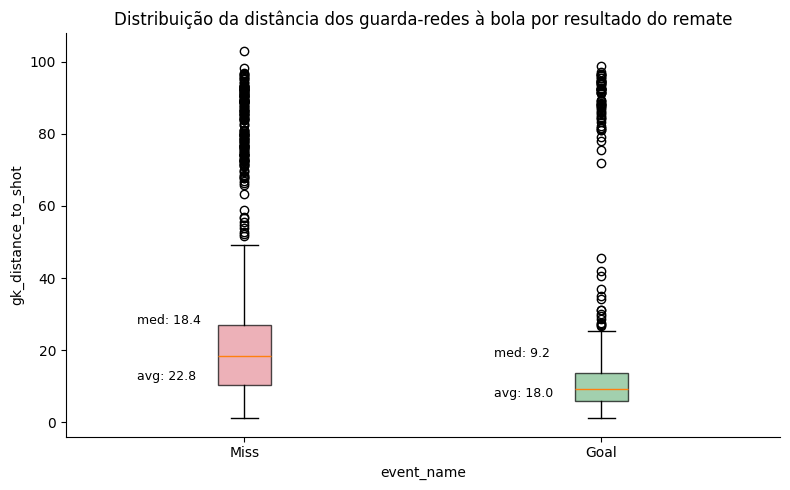

In [ ]:
numerical_boxplot(df_shots_explore, "gk_distance_to_shot", "event_name",
                  title = "Distribuição da distância dos guarda-redes à bola por resultado do remate",
                  offset = 10)

In [ ]:
df_shots_explore["gk_distance_to_shot"].describe()

,gk_distance_to_shot
count,2801.000000
mean,21.832541
std,20.706976
min,1.131371
25%,9.130170
50%,15.741029
75%,25.923927
max,102.901215


Temos aqui muitos valores estranhos e potencialmente outliers significativos, em que muitos guarda-redes se encontram bastante longe da bola no momento do remate. Isto diz-nos que, afinal, estas colunas podem não ser tão fiáveis como, por exemplo a distância. Ainda assim, vamos manter a variável para já e avaliar daqui a pouco, quando olharmos para os outliers deste grupo, se faz sentido mantê-la.

Prossguindo, temos agora algumas variáveis cuja relação com o target pode ser interessante. Mas primeiro, temos de as transformar e preencher os missing values (aqui, será seguro assumir que a ausência de valor indica um remate fora desta zona).

In [ ]:
cols_box = ["Out of box-centre", "Box-centre", "Box-left", "Box-right", "Small box-left", "Small box-centre", "Small box-right"]

for col in cols_box:
  print("=================================")
  print(df_shots_explore[col].value_counts(dropna = False))

Out of box-centre
-      1342
sim     940
NaN     519
Name: count, dtype: int64
Box-centre
-      1441
sim    1120
NaN     240
Name: count, dtype: int64
Box-left
NaN    2383
-       321
sim      97
Name: count, dtype: int64
Box-right
NaN    2456
-       257
sim      88
Name: count, dtype: int64
Small box-left
NaN    2706
-        63
sim      32
Name: count, dtype: int64
Small box-centre
NaN    2537
-       178
sim      86
Name: count, dtype: int64
Small box-right
NaN    2726
-        55
sim      20
Name: count, dtype: int64


In [ ]:
for df in df_shots_X:
  for col in cols_box:
    df[col] = df[col].fillna("-").replace({"sim": 1, "-": 0})

Agora sim, podemos olhar para as visualizações (começando pela `Zone`, a única que não tinha missing values nem tivemos de transformar).

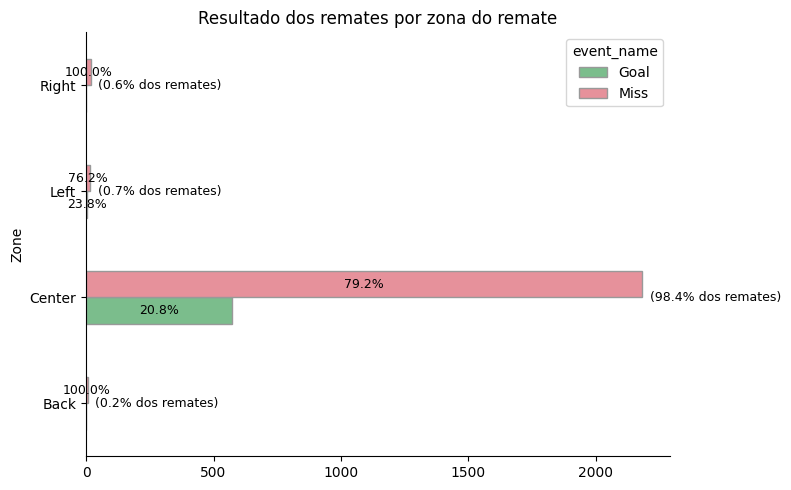

In [ ]:
categorical_barplot(df_shots_explore, "Zone", "event_name", title = "Resultado dos remates por zona do remate")

É algo que já poderíamos suspeitar através da consulta da documentação da OPTA, mas esta variável é extremamente enviesada para uma categoria, o que faz sentido visto que a maioria dos remates são efetuados em zona central (de acordo com a definição da OPTA). Tendo em conta que já criámos outras features que nos dão informação de melhor qualidade, podemos descartar esta coluna.

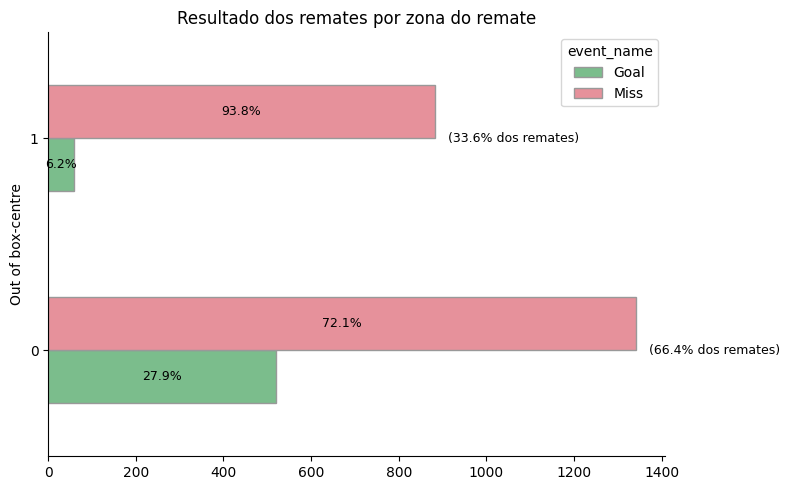

In [ ]:
categorical_barplot(df_shots_explore, "Out of box-centre", "event_name", title = "Resultado dos remates por zona do remate")

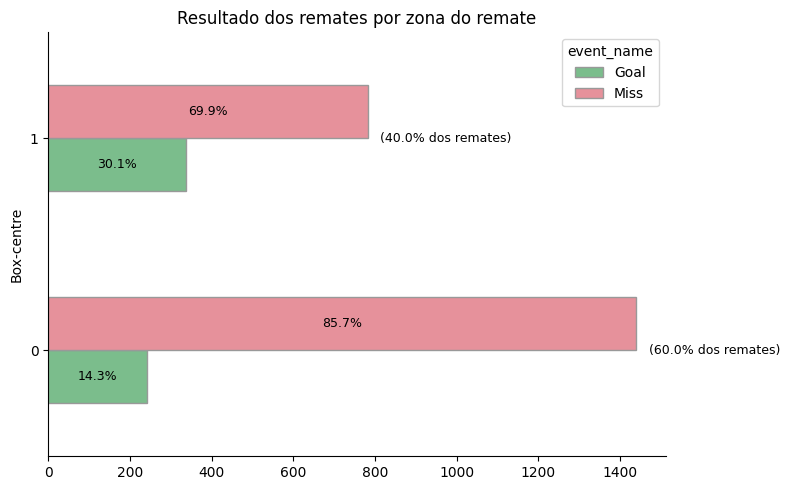

In [ ]:
categorical_barplot(df_shots_explore, "Box-centre", "event_name", title = "Resultado dos remates por zona do remate")

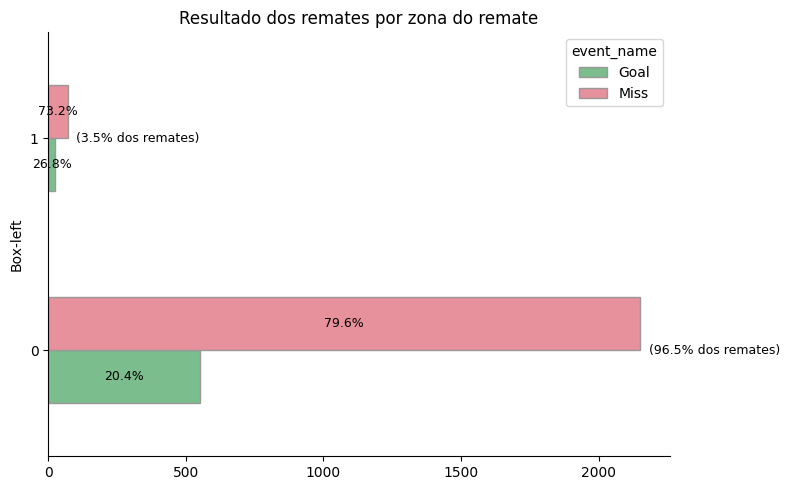

In [ ]:
categorical_barplot(df_shots_explore, "Box-left", "event_name", title = "Resultado dos remates por zona do remate")

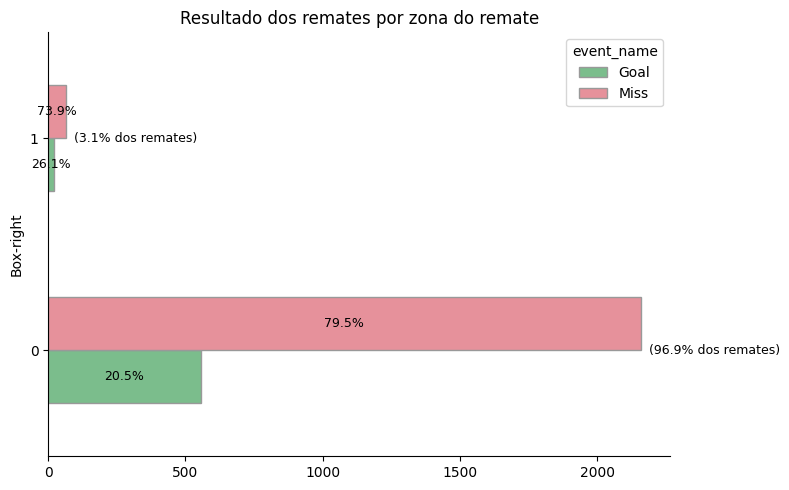

In [ ]:
categorical_barplot(df_shots_explore, "Box-right", "event_name", title = "Resultado dos remates por zona do remate")

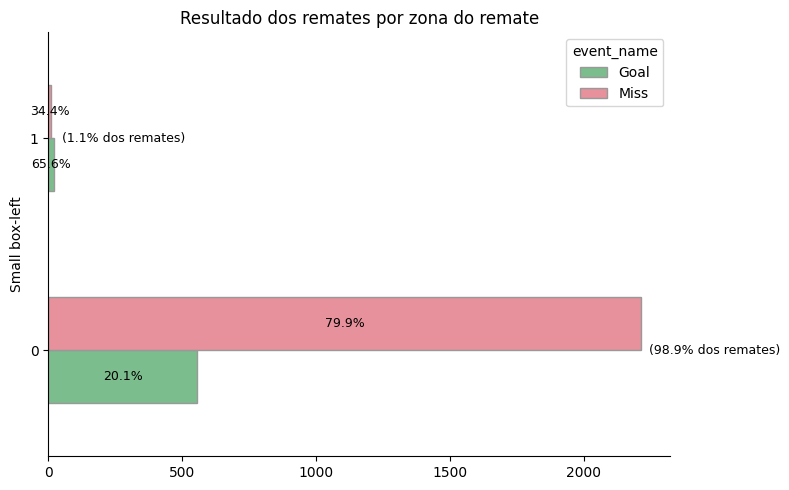

In [ ]:
categorical_barplot(df_shots_explore, "Small box-left", "event_name", title = "Resultado dos remates por zona do remate")

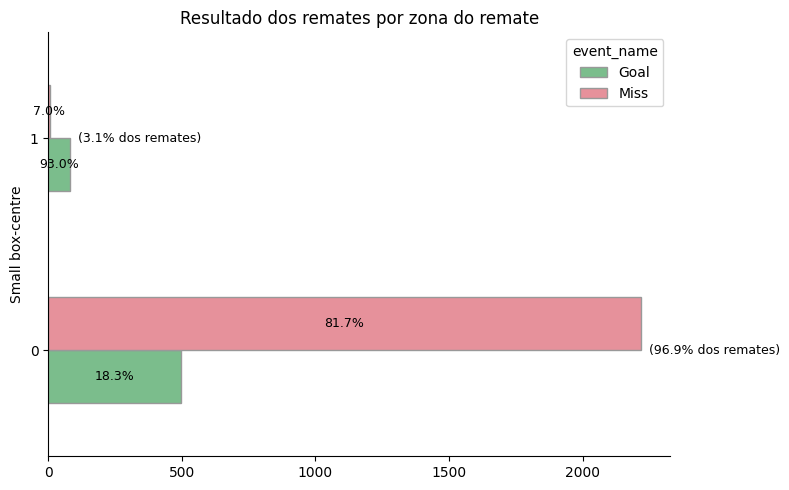

In [ ]:
categorical_barplot(df_shots_explore, "Small box-centre", "event_name", title = "Resultado dos remates por zona do remate")

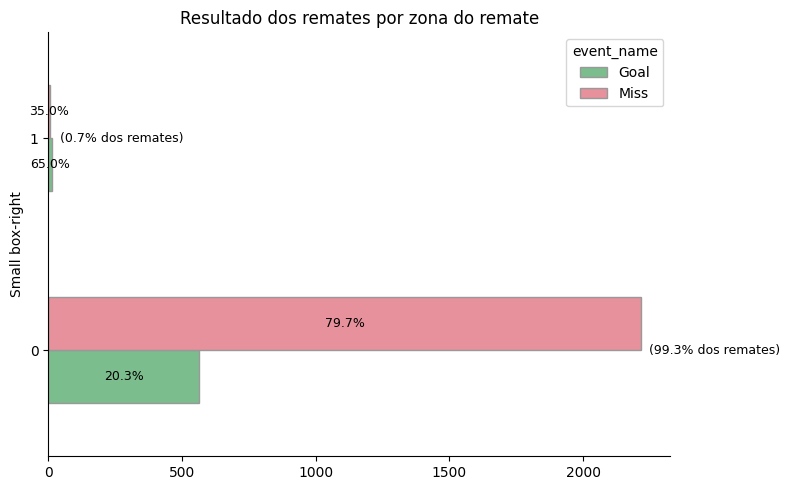

In [ ]:
categorical_barplot(df_shots_explore, "Small box-right", "event_name", title = "Resultado dos remates por zona do remate")

Novamente, não há grandes surpresas. As colunas que indicam remates feitos dentro da grande área mas fora da pequena área (`Box-centre`, `Box-left` e `Box-right`) são as menos informativas, por contraste com as que identificam remates efetuados à entrada da área (`Out of box-centre`) ou dentro da pequena área (`Small box-left`, `Small box-centre` e `Small box-right`).

Desta forma, iremos eliminar as colunas `Box-centre`, `Box-left` e `Box-right`, visto que já temos uma variável potencialmente mais útil e que identifica a generalidade dos remates efetuados dentro da grande área. Da mesma forma, vamos eliminar as variáveis `Small box-left`, `Small box-centre` e `Small box-right` e criar uma nova para identificar remates dentro da pequena área - isto porque, embora as 3 sejam com toda a certeza bastante relevantes, cada uma apresenta poucos exemplos favoráveis. Ao agregar tudo numa única variável, asseguramos que mantemos esta informação útil junta numa única feature, o que pode aumentar a atenção dada por parte dos modelos.

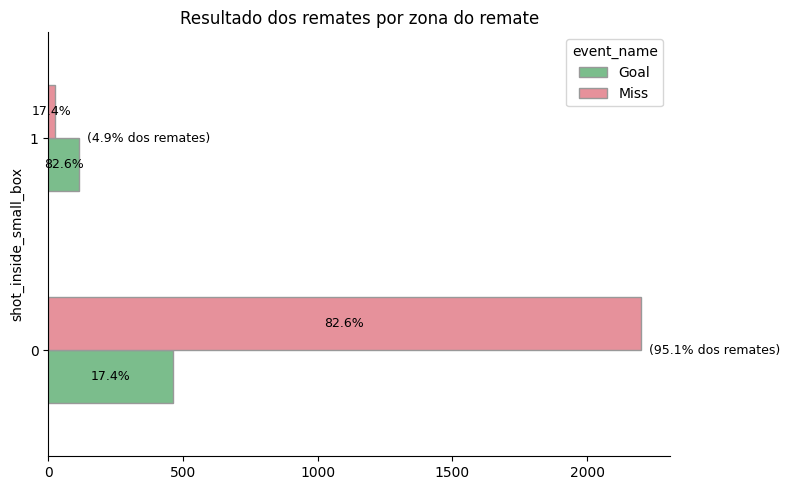

In [ ]:
for df in df_shots_X:
  df["shot_inside_small_box"] = (
    (df["Small box-left"] == 1) |
    (df["Small box-centre"] == 1) |
    (df["Small box-right"] == 1)
  ).astype(int)

categorical_barplot(df_shots_explore, "shot_inside_small_box", "event_name", title = "Resultado dos remates por zona do remate")

Perfeito.

O último passo neste grupo será voltar a olhar para as variáveis em que identificámos outliers no processo de exploração.

In [ ]:
df_shots_explore[["x", "shot_distance", "gk_distance_to_shot"]].describe()

,x,shot_distance,gk_distance_to_shot
count,2801.000000,2801.000000,2801.000000
mean,84.551589,19.467647,21.832541
std,10.661993,11.173656,20.706976
min,1.100000,1.664332,1.131371
25%,78.200000,11.363538,9.130170
50%,87.300000,17.629804,15.741029
75%,91.600000,26.350142,25.923927
max,99.300000,98.951756,102.901215


Vamos tentar descartar as observações em que a bola (`x`) ou o guarda-redes (`GK X Coordinate`) se encontravam nos primeiros 60% do terreno no momento do remate. Vamos também, em paralelo, avaliar que percentagem de remates teve uma distância superior a 60. Antes disso, temos de avaliar se não estaremos a eliminar um conjunto demasiado grande de observações.

In [ ]:
outliers_condition = (df_shots_explore["x"] < 60)
print(f"Observações a remover: {outliers_condition.sum()}")
print(f"Percentagem: {outliers_condition.sum() / len(df_shots_explore) * 100:.2f}%")

Observações a remover: 36
Percentagem: 1.29%


In [ ]:
# Ajuste para 59 tendo em conta o output das células seguintes
outliers_condition = (df_shots_explore["shot_distance"] > 59)
print(f"Observações a remover: {outliers_condition.sum()}")
print(f"Percentagem: {outliers_condition.sum() / len(df_shots_explore) * 100:.2f}%")

Observações a remover: 26
Percentagem: 0.93%


In [ ]:
outliers_condition = (df_shots_explore["GK X Coordinate"] < 60)
print(f"Observações a remover: {outliers_condition.sum()}")
print(f"Percentagem: {outliers_condition.sum() / len(df_shots_explore) * 100:.2f}%")

Observações a remover: 209
Percentagem: 7.46%


Destes dados, podemos concluir que, muito provavelmente, as variáveis de coordenadas do guarda-redes não estão tão limpas quando poderia aparentar inicialmente. Num cenário ideal, o que faríamos seria experimentar com e sem informação destas colunas e avaliar o comportamento do modelo; contudo, num projeto com um curso temporal limitado, teremos de tomar algumas decisões: neste caso, __vamos deixar cair as variáveis relacionadas com o posicionamento do guarda-redes no momento do remate__ dada a pouca fiabilidade dos dados, esperando (e acreditando) que as restantes variáveis serão capazes de transmitir a mesma informação.

Visto não ser um número grande de observações, vamos então descartar as observações em que `x` ou `shot_distance` < 60 e olhar novamente para os boxplots. Vamos fazê-lo para os dados de treino e de validação, visto que se tratam muito provavelmente de dados incorretos e podemos aceitar descartar estas observações ao invés de encará-las como missing values e acabar por assumir um valor como a média ou a mediana.

In [ ]:
for df in df_shots_X:
  df_size = len(df)
  df.drop(index = df[(df["x"] < 60) | (df["shot_distance"] > 59)].index, inplace = True)
  print(f"Percentagem de observações mantidas: {len(df)} ({len(df) / df_size * 100:.2f}%)")

# Garantir que as observações no target correspondem às que temos nos datasets de variáveis independentes
y_train = y_train[df_shots_train.index]
y_val = y_val[df_shots_val.index]

Percentagem de observações mantidas: 2764 (98.68%)
Percentagem de observações mantidas: 696 (99.00%)
Percentagem de observações mantidas: 2764 (98.68%)


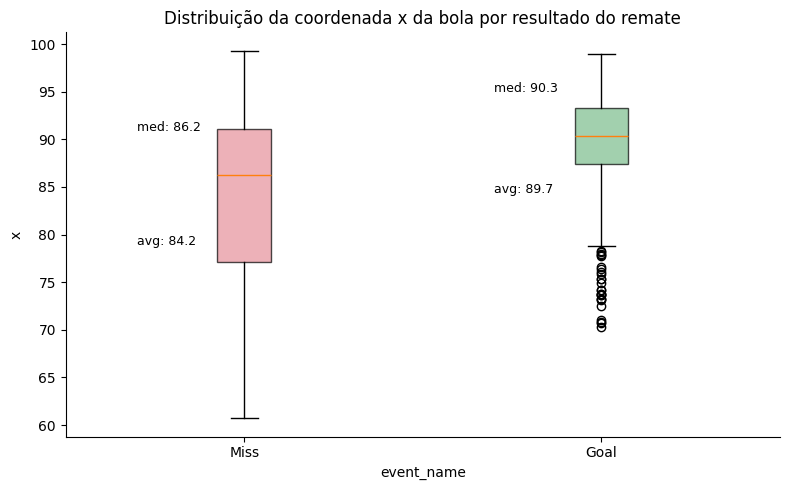

In [ ]:
numerical_boxplot(df_shots_explore, "x", "event_name",
                  title = "Distribuição da coordenada x da bola por resultado do remate",
                  offset = 5)

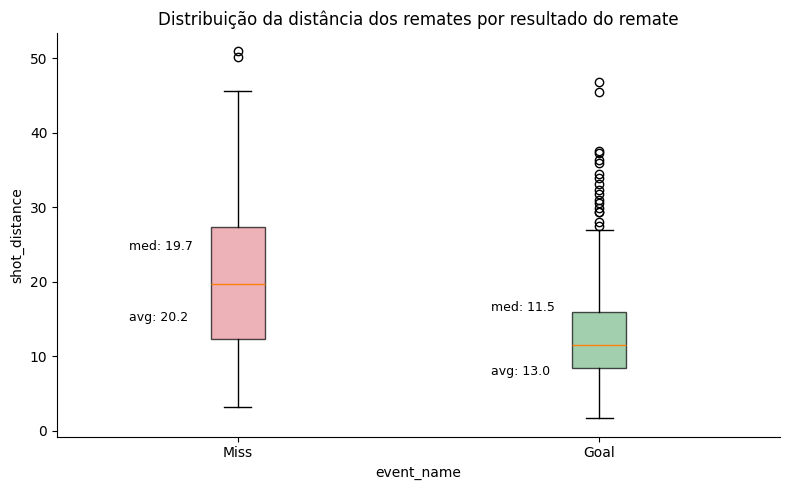

In [ ]:
numerical_boxplot(df_shots_explore, "shot_distance", "event_name",
                  title = "Distribuição da distância dos remates por resultado do remate",
                  offset = 5)

As colunas de coordenadas já cumpriram o seu propósito. Em vez de utilizarmos as posições `x` e `y` dos jogadores, estamos em condições de trabalhar com a distância e ângulo dos remates, assim como identificar remates feitos em zonas específicas do terreno (como a grande área). Foram também úteis para efeitos de exploração e validação da conformidade dos dados (como acabámos de fazer), mas vamos agora eliminá-las. Assim, não vamos fazer nada com os outliers da coluna `x`.

__Para os outliers que ainda permanecem na variável `shot_distance`, vamos experimentar aceitá-los__, até porque temos de ter em consideração que estamos a ver outliers por categoria do target e não para a variável como um todo. Mesmo assim, não são valores muito acima do limite Q3 + 1.5 * IQR, e transformá-los (por exemplo, através de "winsorization" para os trazer para este limite) poderia distorcer a informação transmitida por uma variável que achamos poder ser importante.

Deste modo, o próximo passo será eliminar as variáveis deste grupo que concluímos já não ser necessárias, e avançar para o seguinte.

In [ ]:
cols_location = ["GK X Coordinate", "GK Y Coordinate", "Zone", "Box-centre", "Box-left", "Box-right",
                 "Small box-left", "Small box-centre", "Small box-right", "gk_distance_to_shot", "x", "y"]

for df in df_shots_X:
  df.drop(columns = cols_location, inplace = True)
  print(df.shape)

(2764, 29)
(696, 29)
(2764, 35)


### `player_id`

Podemos complementar os dados com informação dos jogadores, proveniente do dataset partilhado no módulo anterior.

In [ ]:
df_players = pd.read_excel("opta_planteis_portugal.xlsx")
df_players.head()

,player_id,player_name,team_ids,team_name,position,birth_date,nationality,height,weight,join_date
0,200597,André Moreira,2030,Belenenses,Goalkeeper,1995-12-02,Portugal,195,90,2019-07-30
1,449983,João Monteiro,2030,Belenenses,Goalkeeper,2001-05-07,Portugal,186,80,2019-11-09
2,153378,Stanislav Kritsyuk,2030,Belenenses,Goalkeeper,1990-12-01,Russia,192,85,2020-09-29
3,209852,Guilherme Oliveira,2030,Belenenses,Goalkeeper,1995-04-12,Portugal,190,83,2018-07-03
4,475501,Diogo Calila,2030,Belenenses,Defender,1998-10-10,Portugal,180,73,2019-01-18


Vamos só ver se há duplicados nestes dados.

In [ ]:
df_players["player_id"].duplicated().sum()

np.int64(10)

Infelizmente encontramos duplicados, que poderão representar jogadores que mudaram de clube durante a época dentro da liga.

In [ ]:
df_players[df_players["player_id"].duplicated(keep=False)].sort_values("player_id")

,player_id,player_name,team_ids,team_name,position,birth_date,nationality,height,weight,join_date
535,107798,Andraz Sporar,372,Sporting Braga,Forward,1994-02-27,Slovenia,186,82,2021-02-01
574,107798,Andraz Sporar,255,Sporting CP,Forward,1994-02-27,Slovenia,186,82,2020-01-23
376,116635,Ewerton,1980,Portimonense,Midfielder,1992-12-01,Brazil,181,73,2021-01-07
201,116635,Ewerton,201,FC Porto,Midfielder,1992-12-01,Brazil,181,73,2018-07-02
628,215755,Denis Poha,371,Vitória Guimarães,Midfielder,1997-05-28,France,173,72,2020-08-07
384,215755,Denis Poha,1980,Portimonense,Midfielder,1997-05-28,France,173,72,2021-02-01
91,216067,Nuno Santos,196,Boavista,Midfielder,1999-03-02,Portugal,165,57,2020-08-18
64,216067,Nuno Santos,251,Benfica,Midfielder,1999-03-02,Portugal,165,57,2019-07-29
418,217989,Rafael Camacho,2847,Rio Ave,Midfielder,2000-05-22,Portugal,175,68,2021-02-01
561,217989,Rafael Camacho,255,Sporting CP,Midfielder,2000-05-22,Portugal,175,68,2019-07-01


Uma vez que são poucos casos, vamos simplesmente apagar a ocorrência mais antiga do jogador e manter a mais recente.

In [ ]:
df_players["join_date"] = pd.to_datetime(df_players["join_date"], errors = "coerce")
df_players = df_players.sort_values("join_date", ascending = False).drop_duplicates(subset = "player_id", keep = "first")

Podemos prosseguir.

In [ ]:
df_shots_explore = df_shots_explore.merge(
  df_players.add_prefix("player_"),
  how = "left",
  left_on = "player_id",
  right_on = "player_player_id")
df_shots_explore.drop(columns = ["player_player_id"], inplace = True)

df_shots_explore.head()

,period_id,min,timestamp,player_id,keypass,Big Chance,Regular play,Right footed,assist,Assisted,Fast break,Intentional assist,Left footed,Penalty,Head,Set piece,From corner,Out of box-centre,Individual Play,Volley,Free kick,Throw-in set piece,event_name,added_time_1st_half,added_time_2nd_half,added_time,min_bins,avg_season_goals_scored,avg_season_goals_conceded_opp,is_losing,home_team,shot_distance,shot_angle,shot_inside_box,shot_inside_small_box,player_player_name,player_team_ids,player_team_name,player_position,player_birth_date,player_nationality,player_height,player_weight,player_join_date
0,2,85,2021-04-22T22:45:01.542,178867,-,NaN,-,sim,-,sim,sim,sim,-,NaN,NaN,-,-,0,sim,-,NaN,NaN,Miss,0,0,0,76-90,1.161290,1.580645,0,1,22.160325,53.440365,1,0,Toni Martínez,201.0,FC Porto,Forward,1997-06-30,Spain,180,70,2020-10-04
1,2,83,2021-04-20T21:43:56.591,183981,-,sim,sim,NaN,-,sim,NaN,NaN,sim,-,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Goal,0,0,0,76-90,0.666667,1.000000,0,0,10.495713,30.963757,1,0,Fabrício Isidoro,3217.0,SC Farense,Midfielder,1992-01-28,Brazil,172,68,2017-12-12
2,2,68,2020-10-25T18:58:35.802,469205,-,-,sim,-,-,sim,NaN,-,sim,-,-,-,NaN,1,sim,NaN,-,NaN,Goal,0,0,0,61-75,1.000000,1.666667,0,0,36.311018,42.432903,0,0,Yanis Hamache,196.0,Boavista,Defender,1999-07-13,France,177,72,2020-08-03
3,1,41,2020-09-18T19:40:56.105,106004,-,-,-,-,-,-,NaN,-,sim,NaN,NaN,NaN,NaN,1,-,NaN,sim,NaN,Goal,0,0,0,31-45,1.156299,1.414686,0,0,25.465663,43.408860,0,0,Alejandro Grimaldo,251.0,Benfica,Defender,1995-09-20,Spain,171,67,2016-01-01
4,2,74,2021-04-25T21:34:25.102,155476,-,NaN,sim,-,-,sim,NaN,sim,sim,NaN,-,NaN,-,0,-,-,NaN,NaN,Miss,0,0,0,61-75,1.777778,1.294118,0,1,20.689128,60.461218,1,0,Ricardo Horta,372.0,Sporting Braga,Forward,1994-09-15,Portugal,173,61,2017-07-19


In [ ]:
df_shots_explore[["player_player_name", "player_team_ids", "player_team_name",
                  "player_position", "player_birth_date", "player_nationality",
                  "player_height", "player_weight", "player_join_date"]].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2764 entries, 0 to 2763
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   player_player_name  2697 non-null   object        
 1   player_team_ids     2697 non-null   float64       
 2   player_team_name    2697 non-null   object        
 3   player_position     2697 non-null   object        
 4   player_birth_date   2697 non-null   object        
 5   player_nationality  2697 non-null   object        
 6   player_height       2697 non-null   object        
 7   player_weight       2697 non-null   object        
 8   player_join_date    2697 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(1), object(7)
memory usage: 194.5+ KB


Temos alguns valores em falta, o que é algo a ter em atenção se optarmos por acrescentar estas variáveis nos dados de treino e validação.

Focando a nossa análise apenas nas variáveis que interessam (que serão `position`, `birth_date`, `nationality`, `height`, `weight` e `join_date`), podemos ver a distribuição dos remates efetuados por posição.

In [ ]:
df_shots_explore["player_position"].value_counts(dropna = False)

,count
player_position,
Forward,1126
Midfielder,1043
Defender,528
NaN,67


Como seria de esperar, os remates são sobretudo feitos por avançados, com os médios a serem também um grupo bastante preponderante. Vamos ver como a probabilidade golo varia conforme a posição.

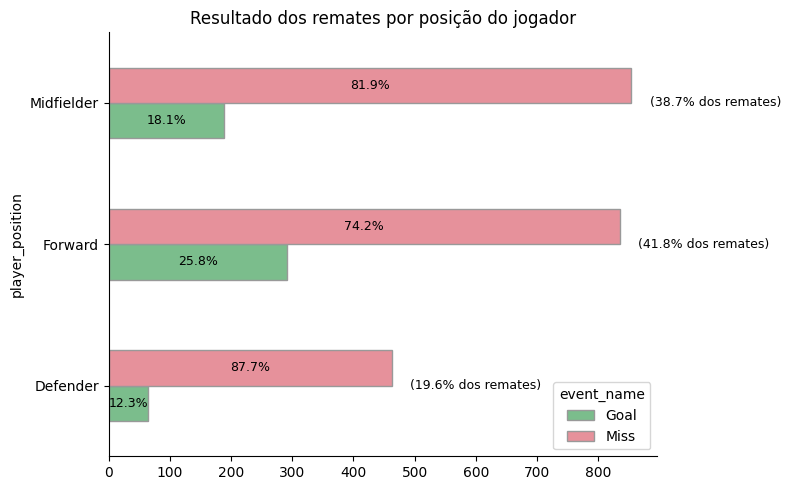

In [ ]:
categorical_barplot(df_shots_explore, "player_position", "event_name", title = "Resultado dos remates por posição do jogador")

Boa. Esta variável parece ter bastante potencial para ser útil. Quanto mais adiantada a posição do jogador, maior a probabilidade do remate dar golo.

Prosseguindo para a variável birth date, não vamos fazer grande coisa com ela neste formato. Em vez disso, vamos obter a idade do jogador através do timestamp (foi para isto que a mantivemos lá atrás).

In [ ]:
df_shots_explore["player_birth_date"] = pd.to_datetime(df_shots_explore["player_birth_date"], errors = "coerce")
df_shots_explore["timestamp"] = pd.to_datetime(df_shots_explore["timestamp"])
df_shots_explore["player_age"] = ((df_shots_explore["timestamp"] - df_shots_explore["player_birth_date"]).dt.days / 365.25).floordiv(1).astype("Int64")

E podemos agora avaliar a distribuição dos valores da idade para as duas categorias do target.

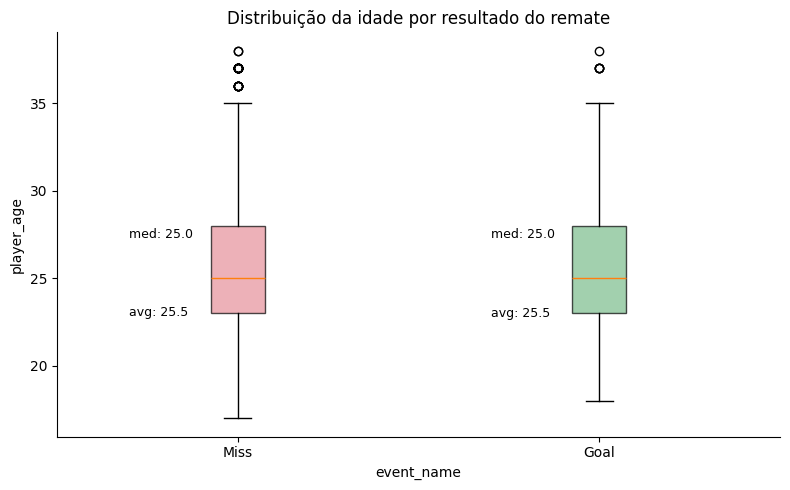

In [ ]:
numerical_boxplot(df_shots_explore, "player_age", "event_name",
                  title = "Distribuição da idade por resultado do remate")

As duas distribuições são praticamente iguais. Daqui retiramos que a idade não é um fator relevante para definir o outcome de um remate, e não iremos levar esta variável depois para os datasets de treino e validação.

Para analisar a nacionalidade dos jogadores que rematam, podemos tentar trazer os dados para um mapa. Para isso, vamos recorrer a um dataset disponível no GitHub com dados dos países.

In [ ]:
url = "https://raw.githubusercontent.com/lukes/ISO-3166-Countries-with-Regional-Codes/refs/heads/master/all/all.csv"

countries = pd.read_csv(url)
countries.head()

,name,alpha-2,alpha-3,country-code,iso_3166-2,region,sub-region,intermediate-region,region-code,sub-region-code,intermediate-region-code
0,Afghanistan,AF,AFG,4,ISO 3166-2:AF,Asia,Southern Asia,NaN,142.0,34.0,NaN
1,Åland Islands,AX,ALA,248,ISO 3166-2:AX,Europe,Northern Europe,NaN,150.0,154.0,NaN
2,Albania,AL,ALB,8,ISO 3166-2:AL,Europe,Southern Europe,NaN,150.0,39.0,NaN
3,Algeria,DZ,DZA,12,ISO 3166-2:DZ,Africa,Northern Africa,NaN,2.0,15.0,NaN
4,American Samoa,AS,ASM,16,ISO 3166-2:AS,Oceania,Polynesia,NaN,9.0,61.0,NaN


In [ ]:
df_shots_explore_nations = df_shots_explore.merge(
  countries.add_prefix("countries_"),
  how = "left",
  left_on = "player_nationality",
  right_on = "countries_name"
).drop(columns = ["countries_name"])

#nationality_counts = nationality_counts[nationality_counts["iso_alpha"] != "PRT"]
nationality_counts = df_shots_explore_nations["countries_alpha-3"].value_counts().reset_index()
nationality_counts.columns = ["iso_alpha", "count"]

fig = px.choropleth(data_frame = nationality_counts, locations = "iso_alpha", color = "count", hover_name = "iso_alpha",
                    color_continuous_scale = px.colors.sequential.Greens, projection = "natural earth")
fig.update_layout(title_text = "Nationality Distribution", title_x = 0.5, title_font = dict(color = "black"))
fig.show()

Conhecendo o campeonato português, não é nenhuma surpresa verificar que a enorme maioria dos jogadores que rematam são portugueses ou brasileiros. A célula abaixo confirma isso mesmo.

In [ ]:
df_shots_explore_nations["player_nationality"].value_counts()

,count
player_nationality,
Portugal,970
Brazil,714
Colombia,108
Spain,91
Argentina,60
IR Iran,55
Uruguay,53
Switzerland,49
France,40


É muito difícil partir do princípio que a nacionalidade afeta de alguma forma a probabilidade de sucesso de um remate. Para esta variável, e tendo em conta que não podemos trabalhar com dados numéricos, vamos experimentar uma abordagem de frequency encoding, em que cada nacionalidade será substituída pela sua frequência relativa no dataset. Depois, podemos olhar para os boxplots para desta nova variável (em relação ao target) e decidir sobre o seu potencial.

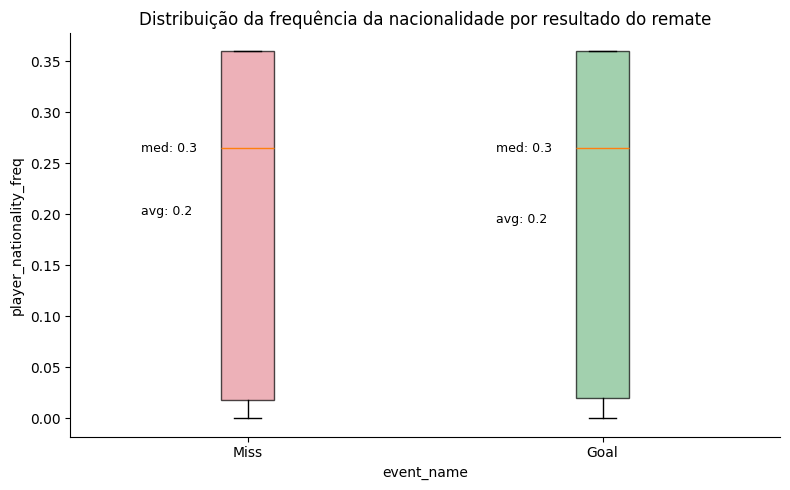

In [ ]:
player_nationality_freq = df_shots_explore["player_nationality"].value_counts(normalize = True)
df_shots_explore["player_nationality_freq"] = df_shots_explore["player_nationality"].map(player_nationality_freq).fillna(0)

numerical_boxplot(df_shots_explore, "player_nationality_freq", "event_name",
                  title = "Distribuição da frequência da nacionalidade por resultado do remate",
                  offset = 0)

A frequência de uma nacionalidade também não é relevante para prever o desfecho de um remate.

Podemos agora olhar para a altura (`height`) e peso (`weight`) dos jogadores.

In [ ]:
# Converter para formato numérico
df_shots_explore["player_height"] = pd.to_numeric(df_shots_explore["player_height"], errors = "coerce")
df_shots_explore["player_weight"] = pd.to_numeric(df_shots_explore["player_weight"], errors = "coerce")

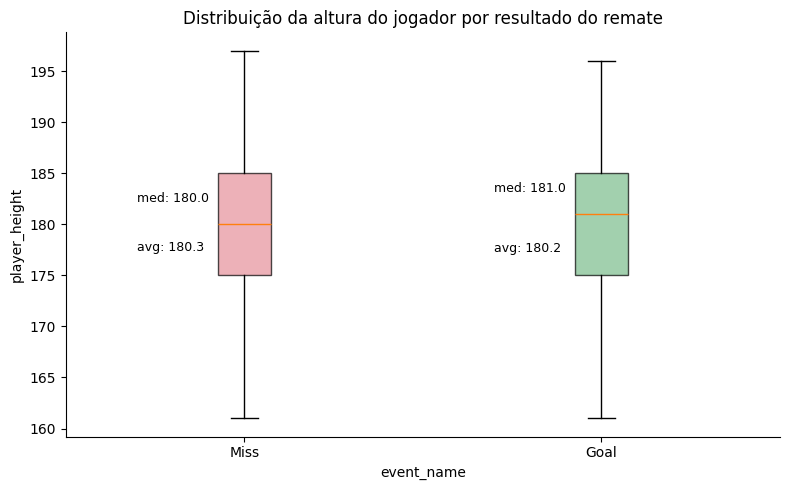

In [ ]:
numerical_boxplot(df_shots_explore, "player_height", "event_name",
                  title = "Distribuição da altura do jogador por resultado do remate")

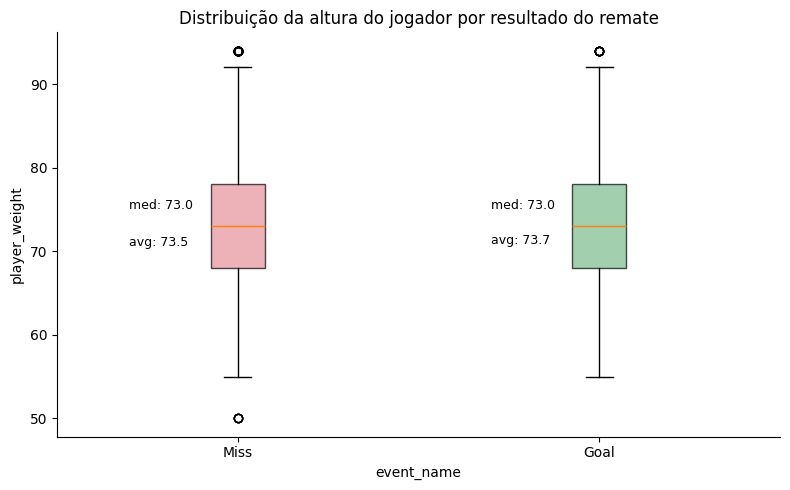

In [ ]:
numerical_boxplot(df_shots_explore, "player_weight", "event_name",
                  title = "Distribuição da altura do jogador por resultado do remate")

Como poderíamos antecipar, estas duas variáveis de contextualização física do jogador não aparentam ter um poder significativo para transmitir aos modelos.

Por fim, podemos avaliar se a antiguidade de um jogador no clube (em anos) influencia a probabilidade de um remate resultar em golo.

In [ ]:
# Transformações semelhantes às que aplicámos para a idade
df_shots_explore["player_join_date"] = pd.to_datetime(df_shots_explore["player_join_date"], errors = "coerce")
df_shots_explore["player_years_at_club"] = ((df_shots_explore["timestamp"] - df_shots_explore["player_join_date"]).dt.days / 365.25).floordiv(1).astype("Int64")

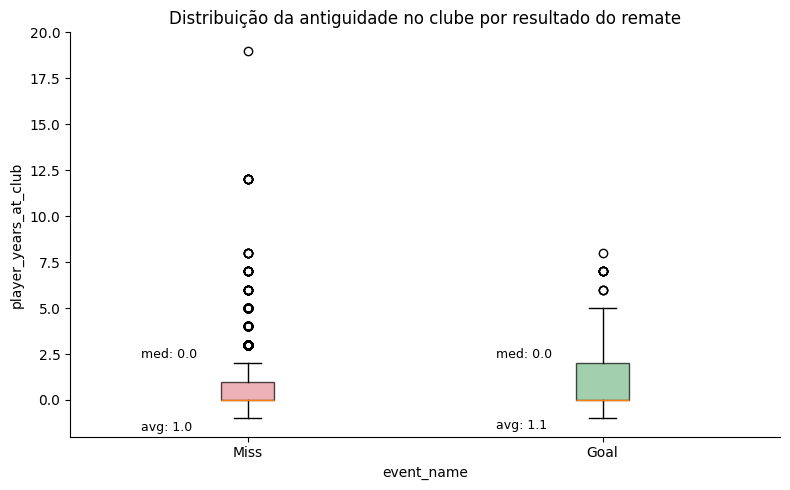

In [ ]:
numerical_boxplot(df_shots_explore, "player_years_at_club", "event_name",
                  title = "Distribuição da antiguidade no clube por resultado do remate")

Talvez com alguma surpresa, a antiguidade do jogador no clube parece ter algum impacto na probabilidade de sucesso de um remate. Uma justificação poderá partir do aumento do entrosamento com os restantes jogadores do plantel e que aumenta as condições de chegar a situações de finalização com hipóteses reais de marcar.

Desta forma, podemos juntar aos datasets de treino e validação duas novas colunas com a posição do jogador, bem como a sua antiguidade no clube.

In [ ]:
df_players = df_players[["player_id", "position", "join_date"]]

# Dados de treino
train_index = df_shots_train.index
df_shots_train = df_shots_train.merge(
  df_players.add_prefix("player_"),
  how = "left",
  left_on = "player_id",
  right_on = "player_player_id")
df_shots_train.index = train_index
df_shots_train.drop(columns = ["player_player_id"], inplace = True)

df_shots_train["player_join_date"] = pd.to_datetime(df_shots_train["player_join_date"], errors = "coerce")
df_shots_train["timestamp"] = pd.to_datetime(df_shots_train["timestamp"])
df_shots_train["player_years_at_club"] = ((df_shots_train["timestamp"] - df_shots_train["player_join_date"]).dt.days / 365.25).floordiv(1).astype("Int64")

# Dados de validação
val_index = df_shots_val.index
df_shots_val = df_shots_val.merge(
  df_players.add_prefix("player_"),
  how = "left",
  left_on = "player_id",
  right_on = "player_player_id")
df_shots_val.index = val_index
df_shots_val.drop(columns = ["player_player_id"], inplace = True)

df_shots_val["player_join_date"] = pd.to_datetime(df_shots_val["player_join_date"], errors = "coerce")
df_shots_val["timestamp"] = pd.to_datetime(df_shots_val["timestamp"])
df_shots_val["player_years_at_club"] = ((df_shots_val["timestamp"] - df_shots_val["player_join_date"]).dt.days / 365.25).floordiv(1).astype("Int64")

In [ ]:
# Ver se ainda temos alguma transformação a fazer nestas variáveis
df_shots_explore[["player_id", "player_position", "player_years_at_club"]].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2764 entries, 0 to 2763
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   player_id             2764 non-null   int64 
 1   player_position       2697 non-null   object
 2   player_years_at_club  2697 non-null   Int64 
dtypes: Int64(1), int64(1), object(1)
memory usage: 67.6+ KB


Temos de transformar as variáveis em formato numérico (neste caso, apenas para a coluna `player_position` e preencher os missing values). Para esta primeira feature, um ordinal encoding será o ideal para a converter, e preencheremos os missing values com a moda. No caso da variável `player_years_at_club`, vamos preencher os valores em falta com a mediana. Além disso, para "combater" os outliers identificados acima, podemos trazer os valores acima de 10 (anos) para 10, de modo a ficar com uma distribuição mais equilibrada e não termos observações a fugir tanto do IQR.

In [ ]:
# Para já não temos guarda_redes mas nunca se sabe
positions_encoder = {"Goalkeeper": 0, "Defender": 1, "Midfielder": 2, "Forward": 3}

df_shots_train["player_position"] = df_shots_train["player_position"].map(positions_encoder)
df_shots_val["player_position"] = df_shots_val["player_position"].map(positions_encoder)
df_shots_explore["player_position"] = df_shots_explore["player_position"].map(positions_encoder)

# Encontrar a moda
position_mode = df_shots_train["player_position"].mode()[0]

# E aplicar nos 3 datasets
df_shots_train["player_position"] = df_shots_train["player_position"].fillna(position_mode)
df_shots_val["player_position"] = df_shots_val["player_position"].fillna(position_mode)
df_shots_explore["player_position"] = df_shots_explore["player_position"].fillna(position_mode)

In [ ]:
# Encontrar a mediana
years_at_club_median = df_shots_train["player_years_at_club"].median()

# Aplicar nos 3 datasets
df_shots_train["player_years_at_club"] = df_shots_train["player_years_at_club"].fillna(years_at_club_median)
df_shots_val["player_years_at_club"] = df_shots_val["player_years_at_club"].fillna(years_at_club_median)
df_shots_explore["player_years_at_club"] = df_shots_explore["player_years_at_club"].fillna(years_at_club_median)

# Limitar o valor da variável ao máximo de 10 anos
df_shots_train["player_years_at_club"] = df_shots_train["player_years_at_club"].clip(lower = 0, upper = 10)
df_shots_val["player_years_at_club"] = df_shots_val["player_years_at_club"].clip(lower = 0, upper = 10)
df_shots_explore["player_years_at_club"] = df_shots_explore["player_years_at_club"].clip(lower = 0, upper = 10)

Por fim, descartamos as colunas que não iremos utilizar mais (agora sim, podemos retirar o `timestamp`) e avançamos para o grupo seguinte de variáveis.

In [ ]:
# Necessário voltar a criar depois dos merges que fizemos
df_shots_X = [df_shots_train, df_shots_val, df_shots_explore]

In [ ]:
cols_player = ["timestamp", "player_id", "player_join_date"]

for df in df_shots_X:
  df.drop(columns = cols_player, inplace = True)
  print(df.shape)

(2764, 29)
(696, 29)
(2764, 44)


### `keypass`, `assist`, `Assisted` e `Intentional assist`

Vamos recapitular a definição da OPTA sobre estas 4 variáveis:
* `keypass` - "keypass = '1' indicates a pass that led directly to a shot on goal (but not a goal) (...)"
* `assist` - "(...) and assist = '1' denotes a pass that led directly to a shot that was a goal." e "The pass was an assist for a shot. The type of shot then dictates whether it was a goal assist or just key pass."
* `Assisted` - "Indicates that there was a pass (assist) from another player to set up the goal opportunity".
* `Intentional assist` - "Shot from an intentional assist i.e. The assisting player intended the pass, no deflection etc".

Nesta perspetiva, poderíamos antever que as duas primeiras variáveis dizem respeito a passes e não a remates. Podemos olhar para elas com mais detalhe.

In [ ]:
df_shots_explore["keypass"].value_counts(dropna = False, normalize = True)

,proportion
keypass,
-,0.992041
1,0.007959


In [ ]:
df_shots_explore["assist"].value_counts(dropna = False, normalize = True)

,proportion
assist,
-,0.817656
NaN,0.179812
1,0.002533


In [ ]:
df_shots_explore.groupby("keypass")["assist"].value_counts(dropna = False, normalize = True)

keypass  assist
-        -         0.816922
         NaN       0.180525
         1         0.002553
1        -         0.909091
         NaN       0.090909
Name: proportion, dtype: float64

São muito poucos casos e mutuamente exclusivos (não há nenhuma assistência que seja em simultâneo um passe-chave, o que faz sentido tendo em conta a definição). Podemos até olhar para estas linhas, para perceber se basta remover estas colunas ou se temos de fazer algo em relação às próprias observações.

In [ ]:
df_shots_explore[(df_shots_explore["keypass"] == "1") | (df_shots_explore["assist"] == "1")]

,period_id,min,keypass,Big Chance,Regular play,Right footed,assist,Assisted,Fast break,Intentional assist,Left footed,Penalty,Head,Set piece,From corner,Out of box-centre,Individual Play,Volley,Free kick,Throw-in set piece,event_name,added_time_1st_half,added_time_2nd_half,added_time,min_bins,avg_season_goals_scored,avg_season_goals_conceded_opp,is_losing,home_team,shot_distance,shot_angle,shot_inside_box,shot_inside_small_box,player_player_name,player_team_ids,player_team_name,player_position,player_birth_date,player_nationality,player_height,player_weight,player_age,player_nationality_freq,player_years_at_club
14,2,73,1,NaN,sim,-,-,sim,NaN,sim,-,NaN,sim,NaN,-,0,-,-,NaN,NaN,Miss,0,0,0,61-75,0.884615,1.444444,1,1,10.060318,6.277298,1,0,Moussa Marega,201.0,FC Porto,3.0,1991-04-14,Mali,186.0,82.0,29,0.008157,4
34,2,72,1,-,-,sim,NaN,sim,-,sim,-,NaN,-,NaN,sim,0,sim,sim,NaN,NaN,Miss,0,0,0,61-75,0.900000,1.727273,0,0,10.791200,20.618188,1,0,Gian-Luca Waldschmidt,251.0,Benfica,3.0,1996-05-19,Germany,181.0,74.0,24,0.007045,0
38,2,59,-,NaN,-,sim,1,sim,NaN,sim,-,NaN,-,NaN,sim,0,sim,sim,NaN,NaN,Miss,0,0,0,46-60,0.764706,1.111111,0,1,19.377564,61.318747,1,0,Crysan,3084.0,Santa Clara,3.0,1996-07-07,Brazil,190.0,82.0,24,0.264739,1
83,1,38,-,NaN,-,-,1,sim,NaN,sim,-,NaN,sim,NaN,sim,0,-,-,NaN,NaN,Miss,0,0,0,31-45,1.040000,1.120000,0,0,10.889444,45.000000,1,0,Vitor Tormena,372.0,Sporting Braga,1.0,1996-01-04,Brazil,192.0,84.0,25,0.264739,1
101,2,100,1,NaN,sim,sim,-,sim,NaN,sim,-,NaN,-,NaN,-,0,-,sim,NaN,NaN,Miss,0,1,1,90+,1.740741,1.518519,0,1,16.260689,39.760456,1,0,Mehdi Taremi,201.0,FC Porto,3.0,1992-07-18,IR Iran,187.0,79.0,28,0.020393,0
194,2,76,1,NaN,-,-,-,-,-,-,sim,NaN,-,-,NaN,0,sim,-,NaN,NaN,Miss,0,0,0,76-90,0.636364,1.272727,0,0,17.123376,20.869348,1,0,Alvarinho,3217.0,SC Farense,3.0,1990-09-03,Portugal,170.0,67.0,30,0.359659,3
488,2,49,1,NaN,-,-,-,-,NaN,-,NaN,NaN,sim,sim,-,0,-,-,NaN,NaN,Miss,0,0,0,46-60,1.740741,1.518519,0,1,7.473286,12.362492,1,0,Jorge Benguché,196.0,Boavista,3.0,1996-05-21,Honduras,188.0,88.0,24,0.014831,0
495,1,47,1,NaN,-,sim,-,-,NaN,-,-,NaN,-,NaN,sim,1,-,sim,NaN,NaN,Miss,1,0,1,46-60,1.000000,0.875000,0,1,28.935273,18.121860,0,0,Rui Correia,2003.0,CD Nacional,1.0,1990-08-23,Portugal,188.0,78.0,30,0.359659,1
510,1,43,1,sim,-,-,NaN,sim,sim,sim,sim,NaN,-,NaN,NaN,0,-,NaN,NaN,NaN,Miss,0,0,0,31-45,1.117647,1.066667,1,0,10.534230,19.983107,1,0,Joel Tagueu,740.0,Marítimo,3.0,1993-12-06,Cameroon,178.0,78.0,27,0.010382,0
675,2,90,1,sim,sim,-,-,sim,NaN,sim,sim,NaN,NaN,NaN,NaN,0,-,-,NaN,NaN,Miss,0,1,1,76-90,1.769231,0.851852,0,0,3.244996,33.690068,1,0,Nicolás Gaitán,372.0,Sporting Braga,2.0,1988-02-23,Argentina,173.0,66.0,33,0.022247,0


Os valores das restantes variáveis deixam entender que __estas observações podem ser válidas, apenas as colunas devem ser descartadas__.

In [ ]:
df_shots_explore["Assisted"].value_counts(dropna = False, normalize = True)

,proportion
Assisted,
sim,0.712735
-,0.274964
NaN,0.012301


In [ ]:
df_shots_explore["Intentional assist"].value_counts(dropna = False, normalize = True)

,proportion
Intentional assist,
sim,0.484443
-,0.473227
NaN,0.042330


Aqui sim, podemos ter variáveis mais informativas. Temos distribuições de valores muito mais interessantes e, curiosamente, parece haver ainda um conjunto significativo de assistências que não são intencionais. Vamos verificar, mas antes disso vamos preencher os valores em falta com "-" (será seguro assumir que não se tratam de assistências) e converter as colunas para formato numérico.

In [ ]:
for df in df_shots_X:
  df["Assisted"] = df["Assisted"].fillna("-").replace({"sim": 1, "-": 0})
  df["Intentional assist"] = df["Intentional assist"].fillna("-").replace({"sim": 1, "-": 0})

In [ ]:
df_shots_explore.groupby("Assisted")["Intentional assist"].value_counts(dropna = False, normalize = True)

Assisted  Intentional assist
0         0                     1.000000
1         1                     0.679695
          0                     0.320305
Name: proportion, dtype: float64

Exato. Praticamente um terço das assistências são registadas como não tendo sido intencionais. Vamos ver como se relacionam com o target.

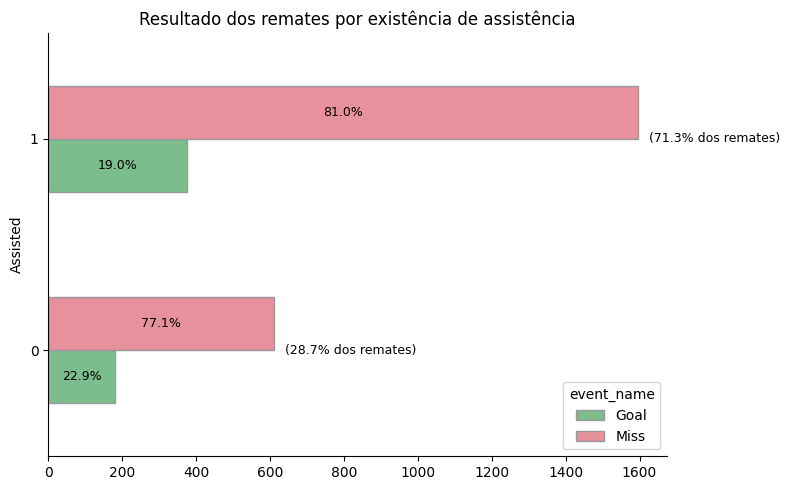

In [ ]:
categorical_barplot(df_shots_explore, "Assisted", "event_name", title = "Resultado dos remates por existência de assistência")

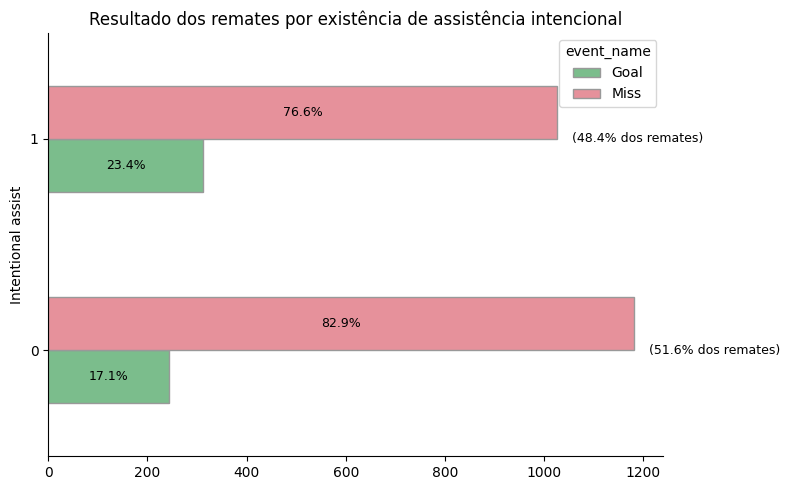

In [ ]:
categorical_barplot(df_shots_explore, "Intentional assist", "event_name",
                    title = "Resultado dos remates por existência de assistência intencional")

Nenhuma das variáveis parece exibir uma correlação muito significativa com o outcome do remate (especialmente a coluna `Assisted`) mas vamos mantê-las para a etapa de seleção de variáveis, onde iremos incidir sobre estas relações com mais detalhe.

Assim, eliminamos apenas as duas colunas que já tínhamos decidido por descartar, e avançamos para os últimos grupos de variáveis.

In [ ]:
cols_assist = ["keypass", "assist"]

for df in df_shots_X:
  df.drop(columns = cols_assist, inplace = True)
  print(df.shape)

(2764, 27)
(696, 27)
(2764, 42)


### `Big Chance`, `Regular play`, `Fast break`, `Penalty`, `Set piece`, `From corner`, `Individual Play`, `Volley`, `Free kick` e `Throw-in set piece`

Agora, iremos focar-nos nas features que atribuem contexto à jogada que resultou no remate. Aqui, é relevante realçar que, à semelhança do que temos vindo a fazer para as restantes variáveis independentes, não iremos dedicar grandes atenções a explorar correlações entre si e a destartar variáveis com base nesse pressuposto. Novamente, esse será o foco na etapa de seleção de variáveis - para já, o objetivo é explorar e conhecer os dados que temos à disposição, transformá-los e prepará-los para as seguintes fases de pré-processamento e modelação.

Começamos então pela variável mais subjetiva (sendo, de acordo com a definição da OPTA, algo decidido pelos seus analistas), que define se o remate constituiu ou não uma grande oportunidade de golo. Quer esta seja ou não importante, teremos de decidir se a devemos incluir nos modelos já que, ao contrário das outras colunas, dificilmente a teremos disponível no momento do remate.

In [ ]:
df_shots_explore["Big Chance"].value_counts(dropna = False)

,count
Big Chance,
NaN,1839
-,463
sim,462


Infelizmente, a maior parte dos valores está em falta. Seguindo a documentação, é improvável que seja a causa, mas podemos confirmar se estes missing values estão relacionados com algum outcome específico do remate.

In [ ]:
df_shots_explore.groupby("Big Chance")["event_name"].value_counts(dropna = False)

Big Chance  event_name
-           Miss          306
            Goal          157
sim         Goal          368
            Miss           94
Name: count, dtype: int64

Não estão. Assim, sendo, vamos assumir que estes valores em falta significam que não se tratou de uma grande oportunidade, e observar a correlação com o target.

In [ ]:
for df in df_shots_X:
  df["Big Chance"] = df["Big Chance"].fillna("-").replace({"sim": 1, "-": 0})

In [ ]:
df_shots_explore[["Big Chance", "event_name"]].value_counts(dropna = False, normalize = True)

,,proportion
Big Chance,event_name,
0,Miss,0.764472
1,Goal,0.133140
0,Goal,0.068379
1,Miss,0.034009


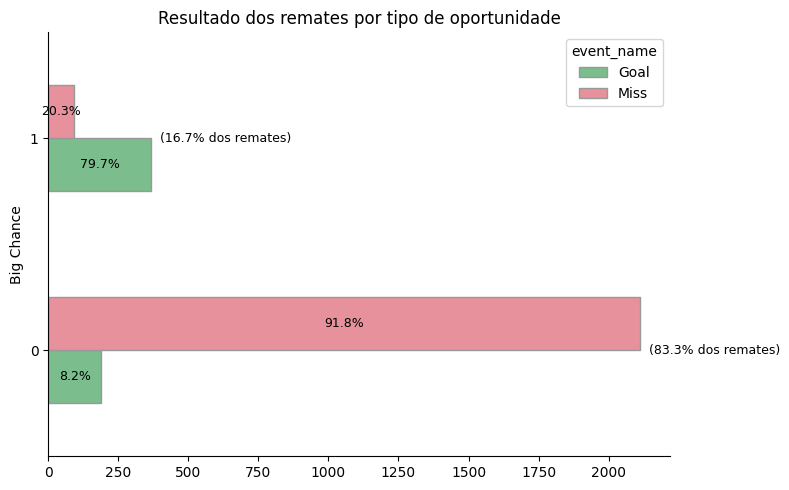

In [ ]:
categorical_barplot(df_shots_explore, "Big Chance", "event_name",
                    title = "Resultado dos remates por tipo de oportunidade")

Muito interessante. Quase 80% das grandes oportunidades resultaram em golo, ao passo que aproximadamente 92% dos remates que não foram contabilizados como `Big Chance`acabaram mesmo por não entrar.

Esta variável exibe um enorme poder preditivo. __Ainda assim, como referido anteriormente, não é informação que tenhamos disponível se quisermos avaliar, em tempo real, a probabilidade de sucesso de um remate. Por isso, não a iremos considerar para as etapas seguintes.__ De qualquer forma, é um insight importante sobre a performance a que podemos tentar almejar para o nosso modelo no melhor dos cenários - um analista que atribui este valor de forma subjetiva (e acerta aproximdadamente 90% das vezes) terá sempre um racional por detrás, e o nosso objetivo será conseguir que os algoritmos captem esse mesmo racional e consigam fazer previsões acertadas, sempre lembrando que o futebol não é, nem de perto nem de longe, uma ciência exata.

Vamos prosseguir para as variáveis seguintes, que destacam o tipo de lance que originou o remate (e incluímos também a variável `Volley` aqui, por ter um comportamento semelhante). Cada uma tem as suas pequenas nuances, mas em todas elas vamos novamente assumir que a ausência de valor significa que não foi uma oportunidade desse tipo. Depois, poderemos ver a sua correlação com o target.

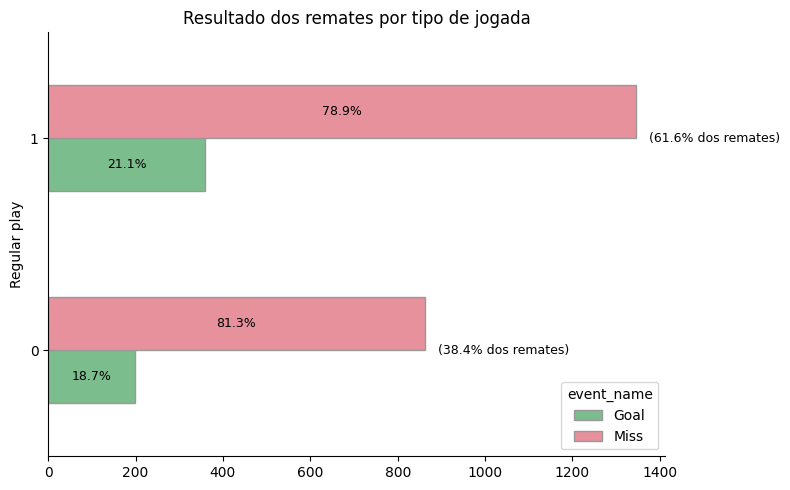

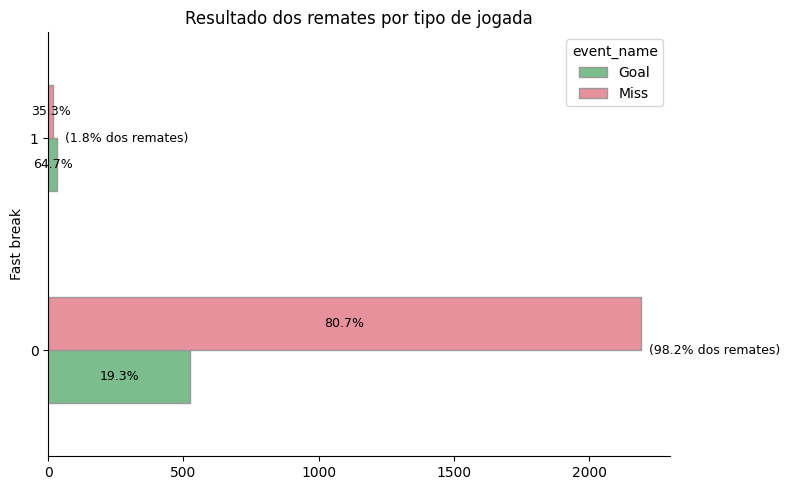

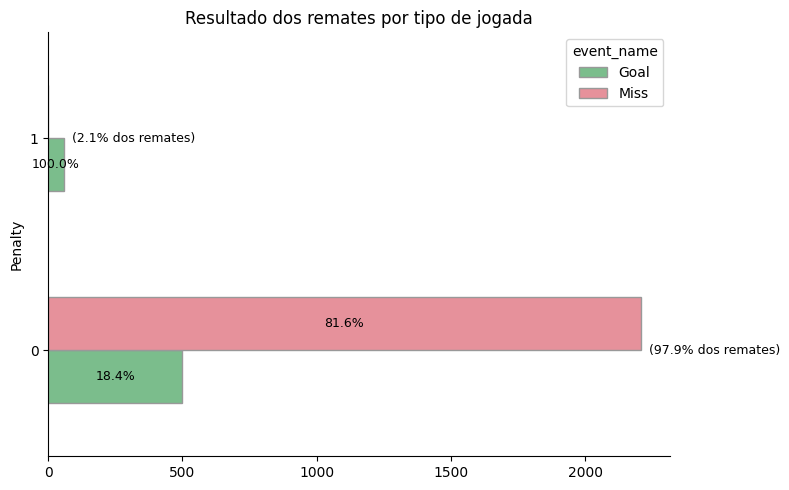

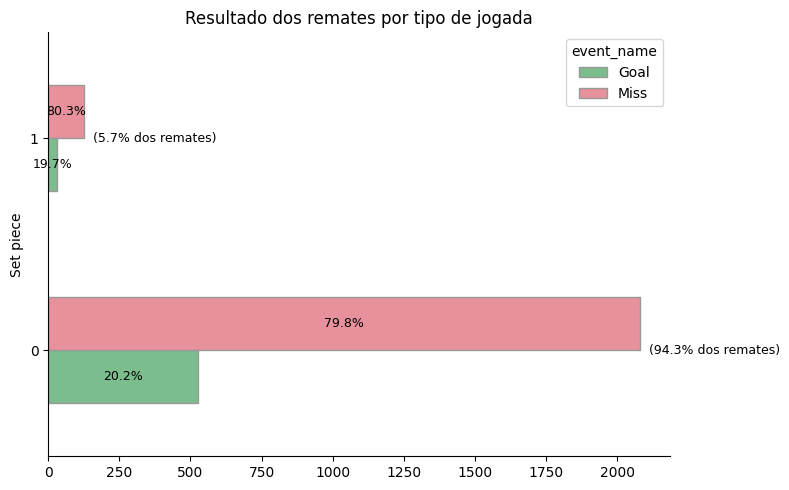

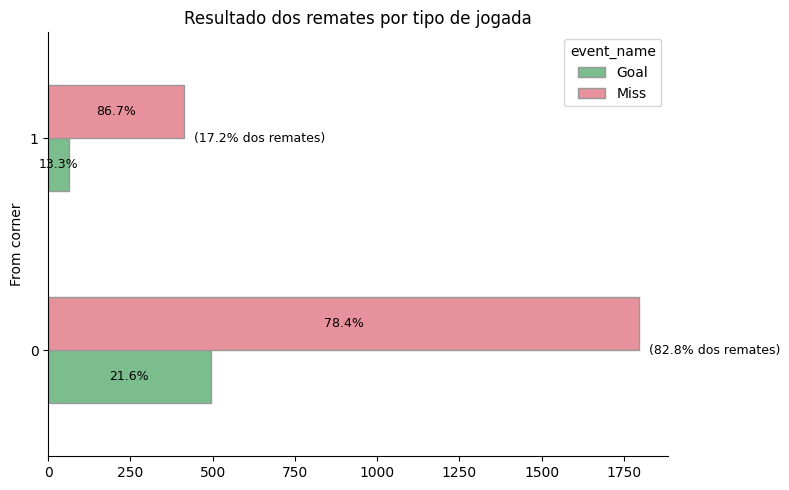

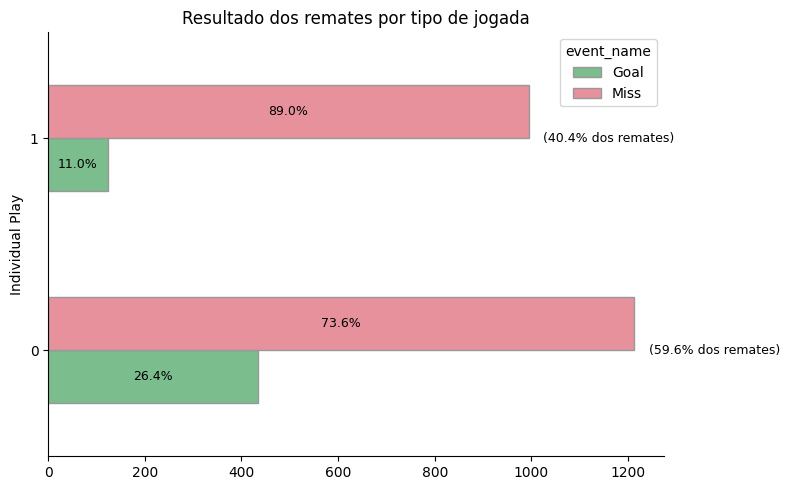

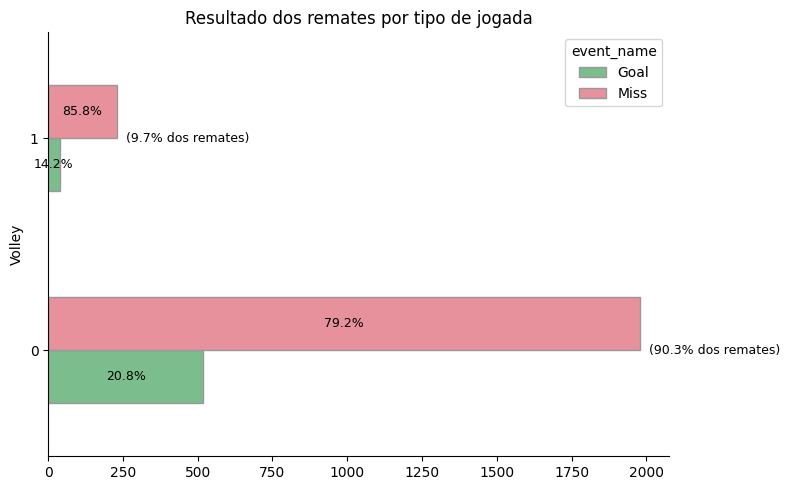

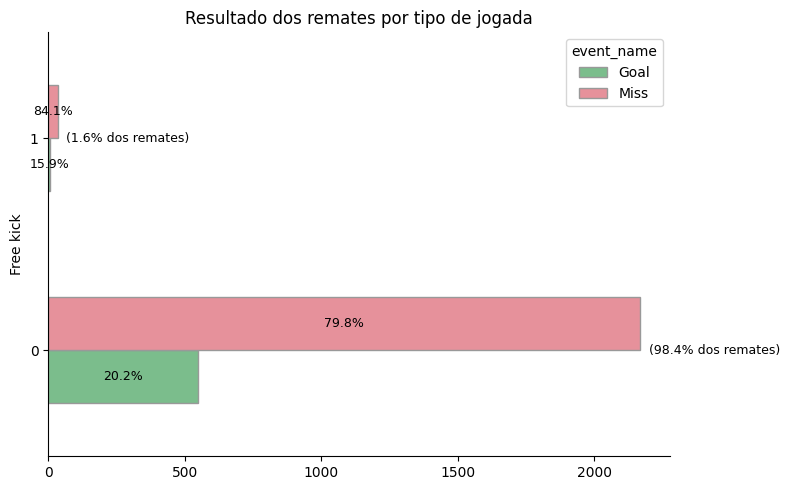

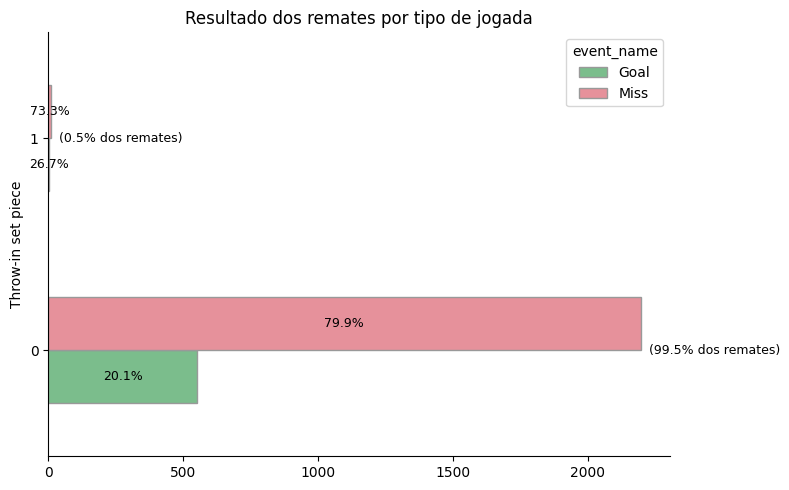

In [ ]:
cols_play = ["Regular play", "Fast break", "Penalty", "Set piece", "From corner", "Individual Play", "Volley", "Free kick", "Throw-in set piece"]

for df in df_shots_X:
  for col in cols_play:
    df[col] = df[col].fillna("-").replace({"sim": 1, "-": 0})

for col in cols_play:
  categorical_barplot(df_shots_explore, col, "event_name", title = "Resultado dos remates por tipo de jogada")

Podemos daqui retirar algumas conclusões:
* `Regular play` - Não parece haver valor preditivo significativo nesta variável. Uma jogada ser ou não em bola corrida "normal" não parece influenciar de forma relevante a probabilidade de golo.
* `Fast break` e `Penalty` - Embora estas variáveis tenham muito poucos exemplos de sucesso (cada uma perto de 2% do seu total), têm um poder preditivo de grande valor acrescentado, e por isso vamos para já mantê-las no nosso dataset. Em particular, é interessante olhar para o caso das grandes penalidades e observar que todos os exemplos nos dados de treino resultaram em golo. Isto significa, por exemplo, que se uma decision tree encontrar uma observação nova em que o remate seja um penálti, irá sempre prever um golo. Haverá casos em que este tipo de "enviesamento" pode ser prejudicial, mas neste caso concreto, fará todo o sentido que um algoritmo preveja um golo sempre que houver um lance deste tipo.
* `Set piece` - Convém notar que, de acordo com a definição da OPTA, estes não são todos os remates resultantes de lances de bola parada, mas sim aqueles que provêm de um livre lateral. Tal como a `Regular play`, esta feature não parece ser relevante para prever o outcome de uma tentativa.
* `From corner` e `Individual Play` - Por outro lado, os remates surgidos após pontapés de canto ou jogadas individuais aparentam ter menos probabilidade de golo. Poderão ser variáveis interessantes para incluir nos modelos.
* `Volley` - Não sendo tão óbvio como os dois casos anteriores (e tendo menos exemplos de sucesso), um remate ser em volley também parecem reduzir a sua probabilidade de sucesso. Vamos mantê-la para já, mas ficamos novamente alerta para a etapa de seleção de variáveis.
* `Free kick` - É um caso semelhante ao anterior, mas ainda com menos expressão. Tendo em conta outras variáveis que já optámos por incluir nesta iteração, podemos descartar esta e esperar que as restantes colunas possam dar informação relevante.
* `Throw-in set piece` - Outro caso em que muito provavelmente não se justifica a inclusão de uma variável extra e que não oferece um aumento de poder preditivo assim tão grande. Poderíamos até considerar juntar algumas destas variáveis (como `Set piece`, `Free kick` e `Throw-in set piece`) num único atributo. Contudo, dado o fraco potencial de cada uma, entendemos não ser a abordagem a seguir nesta fase. Se vier a fazer sentido, poderemos sempre voltar atrás e optar por esse caminho.

In [ ]:
cols_chance = ["Big Chance", "Regular play", "Set piece", "Free kick", "Throw-in set piece"]

for df in df_shots_X:
  df.drop(columns = cols_chance, inplace = True)
  print(df.shape)

(2764, 22)
(696, 22)
(2764, 37)


### `Right footed`, `Left footed` e `Head`

Chegamos ao último grupo de variáveis independentes, que identificam a parte do corpo com que foi efetuado o remate. Vamos desde já assumir a mesma lógica dos casos anteriores para os exemplos em falta, e fazer um pequeno coherence check para garantir que não há remates feitos com duas partes do corpo em simultâneo.

In [ ]:
cols_body_part = ["Right footed", "Left footed", "Head"]

for df in df_shots_X:
  for col in cols_body_part:
    df[col] = df[col].fillna("-").replace({"sim": 1, "-": 0})

In [ ]:
df_shots_explore[cols_body_part].sum(axis = 1).value_counts()

,count
1,2664
0,100


Felizmente não encontrámos nenhum caso. Temos, por outro lado, alguns eventos em que o remate não foi feito nem com os pés nem com a cabeça. Como isso é algo relativamente normal no futebol, vamos prosseguir e avaliar a relação com a variável dependente.

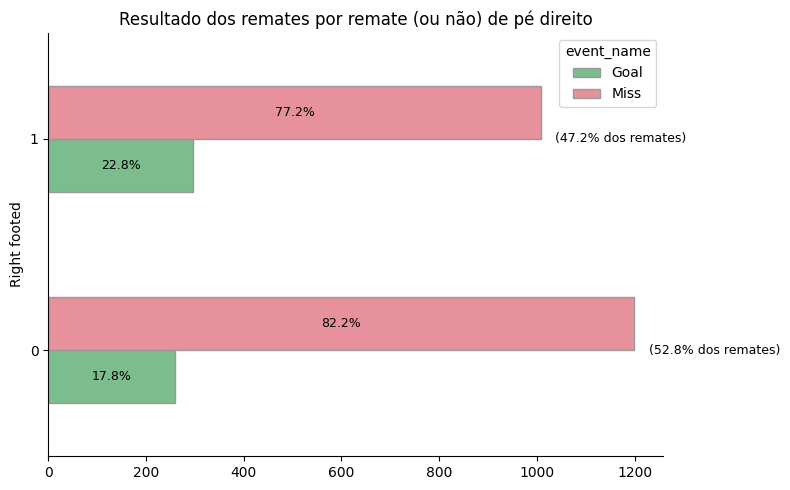

In [ ]:
categorical_barplot(df_shots_explore, "Right footed", "event_name", title = "Resultado dos remates por remate (ou não) de pé direito")

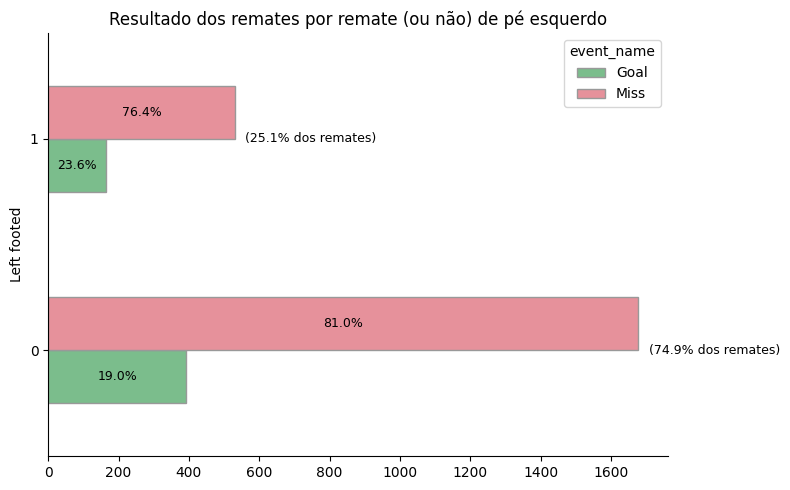

In [ ]:
categorical_barplot(df_shots_explore, "Left footed", "event_name", title = "Resultado dos remates por remate (ou não) de pé esquerdo")

Os remates com os pés não parecem acrescentar muita informação para prever o seu resultado. Ainda assim, estando no limite do aceitável, podemos manter para já e guardar a decisão de eliminar ou não para a seleção de variáveis.

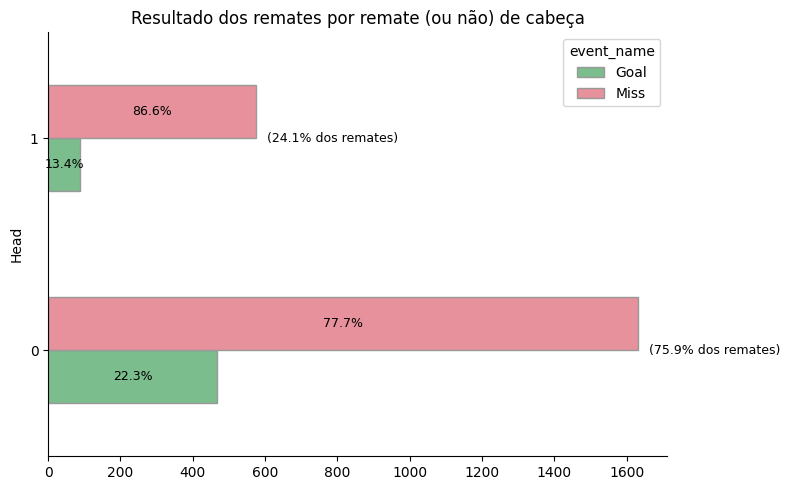

In [ ]:
categorical_barplot(df_shots_explore, "Head", "event_name", title = "Resultado dos remates por remate (ou não) de cabeça")

Por outro lado, a indicação de o remate ser um cabeceamento já parece demonstrar mais algum poder preditivo. Vamos mantê-la, mas podemos também deixar no ar se esta feature poderá estar relacionada com outras, com a `From corner` à cabeça.

__Concluímos assim a etapa de exploração e pré-processamento incial. Ficámos a conhecer os dados à disposição, complementámo-los com informação externa e criámos novas variáveis, tratámos missing values e outliers.__ Se assim quiséssemos, já estávamos em condições de avançar para a modelação.

Contudo, antes disso, vamos fazer mais alguns passos adicionais que, se tudo correr bem, poderão ainda ajudar a melhorar a performance.

In [ ]:
# Garantir, uma última vez, que as observações no target correspondem às que temos nos datasets de variáveis independentes
y_train = y_train[df_shots_train.index]
y_val = y_val[df_shots_val.index]

# Passar para formato numérico, mais adequado para a modelação (e já não precisamos do texto para os gráficos)
y_train = (y_train == "Goal").astype(int)
y_val = (y_val == "Goal").astype(int)

In [ ]:
# Verificar a existência de duplicados
df_shots_train.duplicated().sum()

np.int64(0)

In [ ]:
df_shots_train.head()

,period_id,min,Right footed,Assisted,Fast break,Intentional assist,Left footed,Penalty,Head,From corner,Out of box-centre,Individual Play,Volley,avg_season_goals_scored,avg_season_goals_conceded_opp,is_losing,shot_distance,shot_angle,shot_inside_box,shot_inside_small_box,player_position,player_years_at_club
3410,2,85,1,1,1,1,0,0,0,0,0,1,0,1.161290,1.580645,0,22.160325,53.440365,1,0,3.0,0
687,2,83,0,1,0,0,1,0,0,0,0,0,0,0.666667,1.000000,0,10.495713,30.963757,1,0,2.0,3
363,2,68,0,1,0,0,1,0,0,0,1,1,0,1.000000,1.666667,0,36.311018,42.432903,0,0,1.0,0
28,1,41,0,0,0,0,1,0,0,0,1,0,0,1.156299,1.414686,0,25.465663,43.408860,0,0,1.0,4
1946,2,74,0,1,0,1,1,0,0,0,0,0,0,1.777778,1.294118,0,20.689128,60.461218,1,0,3.0,3


In [ ]:
df_shots_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2764 entries, 3410 to 2851
Data columns (total 22 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   period_id                      2764 non-null   int64  
 1   min                            2764 non-null   int64  
 2   Right footed                   2764 non-null   int64  
 3   Assisted                       2764 non-null   int64  
 4   Fast break                     2764 non-null   int64  
 5   Intentional assist             2764 non-null   int64  
 6   Left footed                    2764 non-null   int64  
 7   Penalty                        2764 non-null   int64  
 8   Head                           2764 non-null   int64  
 9   From corner                    2764 non-null   int64  
 10  Out of box-centre              2764 non-null   int64  
 11  Individual Play                2764 non-null   int64  
 12  Volley                         2764 non-null   int

## <font color='#457fb5'>2.3. Otimizar data types</font> <a class="anchor" id="dtypes"></a>
[Regressar ao Índice](#toc)

Podemos aplicar uma função muito simples para reduzir os data types ao seu mínimo possível e assim poupar memória. Não é que fosse um grande problema neste caso, mas sempre consome menos recursos.

In [ ]:
for df in [df_shots_train, df_shots_val]:
  optimize_dtypes(df)

df_shots_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2764 entries, 3410 to 2851
Data columns (total 22 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   period_id                      2764 non-null   int8   
 1   min                            2764 non-null   int8   
 2   Right footed                   2764 non-null   int8   
 3   Assisted                       2764 non-null   int8   
 4   Fast break                     2764 non-null   int8   
 5   Intentional assist             2764 non-null   int8   
 6   Left footed                    2764 non-null   int8   
 7   Penalty                        2764 non-null   int8   
 8   Head                           2764 non-null   int8   
 9   From corner                    2764 non-null   int8   
 10  Out of box-centre              2764 non-null   int8   
 11  Individual Play                2764 non-null   int8   
 12  Volley                         2764 non-null   int

## <font color='#457fb5'>2.4. Scaling</font> <a class="anchor" id="scaling"></a>
[Regressar ao Índice](#toc)

O passo seguinte de pré-processamento será transformar todos os dados para uma escala comum, que vamos definir como sendo entre 0 e 1 através de min-max scaling. Esta etapa é crucial para a modelação (e também para parte da seleção de variáveis) de modo a não enviesar os modelos a favor de variáveis com uma escala de valores superior.

__Nota:__ A alternativa mais direta a esta abordagem seria a estandardização dos dados. Contudo, isso pressupõe que as variáveis numéricas sigam uma distribuição normal, o que não se verifica neste caso de estudo.

In [ ]:
# Criar scaler com base nos dados de treino
scaler = MinMaxScaler().fit(df_shots_train)

# Aplicar nos dados de treino
df_shots_train_scaled = pd.DataFrame(
  scaler.transform(df_shots_train),
  columns = df_shots_train.columns,
  index = df_shots_train.index
)
# E nos dados de validação
df_shots_val_scaled = pd.DataFrame(
  scaler.transform(df_shots_val),
  columns = df_shots_val.columns,
  index = df_shots_val.index
)

## <font color='#457fb5'>2.5. Seleção de Variáveis</font> <a class="anchor" id="selection"></a>
[Regressar ao Índice](#toc)

Chegamos a uma das etapas mais importantes do processamento dos dados, em que faremos a seleção final das variáveis independentes que irão informar os modelos que venham a ser criados. Tendo aproximadamente 20 atributos distintos, não esperamos (nem desejamos) eliminar muitas colunas, mas é sempre relevante tentar fazer uma seleção daquelas que melhor poderão contribuir para uma boa performance do modelo. Este passo será feito antes da etapa de oversampling tendo por base [este](https://www.sciencedirect.com/science/article/abs/pii/S1568494624000413) artigo.

Iremos seguir uma abordagem que irá envolver várias técnicas. Os algoritmos a selecionar serão aqueles que forem escolhidos por mais de metade dos métodos que lhes forem aplicados.
* __Correlação de Spearman entre variáveis numéricas independentes__ - Algo que evitámos fazer até este ponto foi analisar a correlação entre variáveis independentes. Contudo, duas (ou mais) features que transmitam a mesma informação irão inevitavelmente enviesar os modelos. Nesse sentido, vamos criar um mapa de correlações de Spearman (que, ao contrário da correlação de Pearson, identifica a existência de relações monotónicas lineares e não lineares) para destacar atributos numéricos fortemente correlacionados (com valor absoluto acima de 0.7).
* __ANOVA__ - Este teste compara a média de uma variável numérica em diferentes categorias de uma variável categórica. Se rejeitarmos a hipótese nula de independência das variáveis (utilizaremos um p-value de 0.05), então não há evidência estatística de independência. Em termos simples, se o p-value for abaixo deste valor, então concluímos que a variável numérica é relevante para prever a variável categórica (neste caso, o nosso target). É de notar, também, que o resultado deste teste será o critério para escolher qual manter entre pares de variáveis identificadas pela correlação de Spearman.
* __Teste de Independência do Qui-Quadrado entre variáveis categóricas independentes__ - Tem um racional semelhante ao da ANOVA, comparando variações na frequência de cada categoria de uma dada variável categórica para as diferentes categorias de uma variável categórica. Se rejeitarmos a hipótese nula de independência, então concluímos existir uma correlação entre ambas.
* __Teste de Independência do Qui-Quadrado entre variáveis categóricas independentes e o target__ - Podemos também estar a correlação entre cada variável categóricas e o target para avaliar o potencial preditivo de cada uma. À semelhança da ANOVA, para variáveis numéricas, este será o critério para decidir entre pares de variáveis categóricas correlacionadas.
* __RFE com Regressão Logística__ - Na técnica de Recursive Feature Elimination, um modelo (no caso, a regressão logística) é incialmente aplicado sobre todas as variáveis. Em cada iteração, a variável independente que menos contribuiu para o modelo será removida, até não restarem mais atributos. A combinação de variáveis que atingir o melhor resultado numa determinada métrica (utilizaremos o F1 score) será a escolhida.
* __Random Forest__ - Sendo um modelo ensemble que identifica as variáveis que mais contribuem para o resultado dos algoritmo, podemos aplicá-lo também como método para a seleção de variáveis.
* __LASSO__ - É uma técnica de regularização que reduz o overfitting ao adicionar um termo de penalização que é proporcional à soma dos valores absolutos dos coeficientes (L1 regularization). Desta forma, pode levar a coeficientes de 0, promovendo modelos com um menor número de variáveis independentes.

In [ ]:
# Começamos por separar as variáveis numéricas das categóricas
vars_numeric = ["min", "avg_season_goals_scored", "avg_season_goals_conceded_opp", "shot_distance", "shot_angle", "player_years_at_club"]

vars_categorical = [col for col in df_shots_train_scaled.columns if col not in vars_numeric]

In [ ]:
# Criar um DataFrame para receber as decisões de cada técnica
df_feature_selection = pd.DataFrame(index = vars_numeric + vars_categorical)
df_feature_selection.index.name = "Variável"

### Correlação de Spearman entre variáveis numéricas independentes

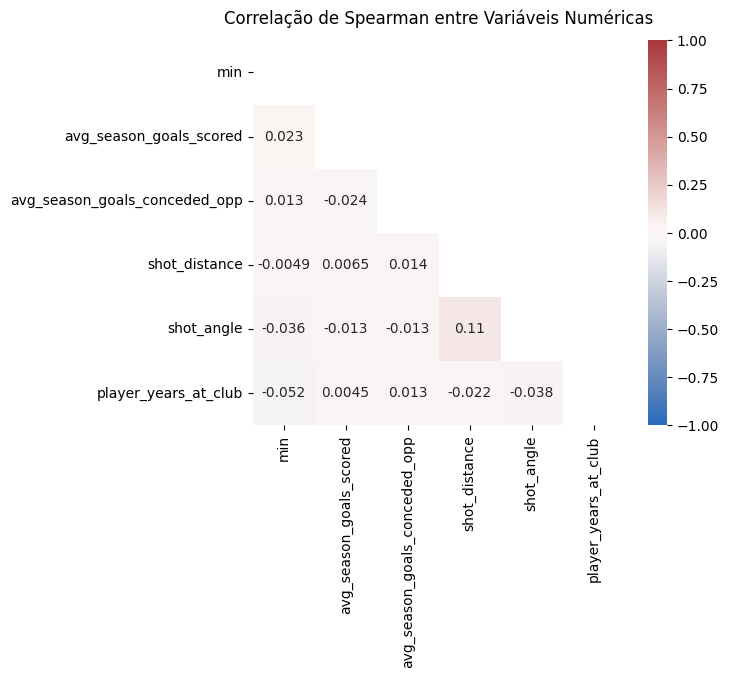

In [ ]:
# Calcular correlações
cor = df_shots_train_scaled[vars_numeric].corr("spearman")
mask = np.triu(np.ones_like(cor, dtype = bool))

# Criar e mostrar mapa
plt.figure(figsize = (6, 5))
sns.heatmap(data = cor,
            mask = mask,
            annot = True,
            annot_kws = {"size": 10},
            cmap = "vlag",
            vmax = 1,
            vmin = -1,
            center = 0,
            fmt = '.2')
plt.title("Correlação de Spearman entre Variáveis Numéricas", y = 1.02)
plt.show()

# identificar pares de variáveis correlacionadas
high_correlation_pairs = []
for i in range(len(cor.columns)):
  for j in range(i + 1, len(cor.columns)):
    if abs(cor.iloc[i, j]) > 0.7:
      high_correlation_pairs.append((cor.columns[i], cor.columns[j]))

spearman_result = {col: "Manter" for col in vars_numeric}
for pair in high_correlation_pairs:
  correlation_value = cor.loc[pair[0], pair[1]]
  print(f"Correlação alta: {pair[0]} and {pair[1]} - Valor da correlação: {correlation_value}")

  # Calcular ANOVA para desempatar entre pares
  groups_0 = [df_shots_train_scaled[pair[0]][y_train == c] for c in y_train.unique()]
  groups_1 = [df_shots_train_scaled[pair[1]][y_train == c] for c in y_train.unique()]
  _, p0 = f_oneway(*groups_0)
  _, p1 = f_oneway(*groups_1)

  if p0 <= p1:
    spearman_result[pair[1]] = "Descartar"
    print(f"{pair[0]} (p = {p0:.4f}) vs {pair[1]} (p = {p1:.4f}) | Variável a manter: {pair[0]}")
  else:
    spearman_result[pair[0]] = "Descartar"
    print(f"{pair[0]} (p = {p0:.4f}) vs {pair[1]} (p = {p1:.4f}) | Variável a manter: {pair[1]}")

# Acrescentar decisão à tabela auxiliar
df_feature_selection["spearman"] = pd.Series(spearman_result)
df_feature_selection["spearman"] = df_feature_selection["spearman"].fillna("-")

Não temos aqui pares de variáveis com uma correlação forte, o que é bom. Prosseguimos para a ANOVA, onde iremos avaliar mais diretamente a correlação destes atributos com o target.

### ANOVA

In [ ]:
anova_results = {}
for col in vars_numeric:
    groups = [df_shots_train_scaled[col][y_train == c] for c in y_train.unique()]
    _, p_value = f_oneway(*groups)
    anova_results[col] = p_value

# Acrescentar decisão à tabela auxiliar
df_feature_selection["anova"] = pd.Series({col: "Manter" if anova_results[col] < 0.05 else "Descartar" for col in vars_numeric})
df_feature_selection["anova"] = df_feature_selection["anova"].fillna("-")

# Criar tabela de output para esta célula
df_anova = pd.DataFrame({
    "Variável": vars_numeric,
    "p_value": [anova_results[col] for col in vars_numeric],
})
df_anova["p_value"] = df_anova["p_value"].round(6)
df_anova["importante"] = (df_anova["p_value"] < 0.05).astype(int)
df_anova = df_anova.set_index("Variável")
df_anova

,p_value,importante
Variável,,
min,0.762504,0
avg_season_goals_scored,0.000012,1
avg_season_goals_conceded_opp,0.003505,1
shot_distance,0.000000,1
shot_angle,0.000985,1
player_years_at_club,0.114565,0


Temos indicação agora de duas variáveis que poderão não ser relevantes. Prosseguimos agora para as variáveis categóricas.

### Teste de Independência do Qui-Quadrado entre variáveis categóricas independentes

In [ ]:
# Qui-quadrado de cada variável categórica com o target para se for preciso desempatar
chi2_target_results = {}
for col in vars_categorical:
  contingency_table = pd.crosstab(df_shots_train_scaled[col], y_train)
  _, p_value, _, _ = chi2_contingency(contingency_table)
  chi2_target_results[col] = p_value

# Identificar pares altamente correlacionados e desempatar
chi2_result = {col: "Manter" for col in vars_categorical}
for col1, col2 in combinations(vars_categorical, 2):
  contingency_table = pd.crosstab(df_shots_train_scaled[col1], df_shots_train_scaled[col2])
  _, p_value, _, _ = chi2_contingency(contingency_table)
  if p_value < 0.05:
    p0, p1 = chi2_target_results[col1], chi2_target_results[col2]
    if p0 <= p1:
      chi2_result[col2] = "Descartar"
      print(f"{col1} (p = {p0:.4f}) vs {col2} (p = {p1:.4f}) | Variável a manter: {col1}")
    else:
      chi2_result[col1] = "Descartar"
      print(f"{col1} (p = {p0:.4f}) vs {col2} (p = {p1:.4f}) | Variável a manter: {col2}")

# Acrescentar decisão à tabela auxiliar
df_feature_selection["qui2_variaveis"] = pd.Series(chi2_result)
df_feature_selection["qui2_variaveis"] = df_feature_selection["qui2_variaveis"].fillna("-")

period_id (p = 0.2479) vs Assisted (p = 0.0243) | Variável a manter: Assisted
Right footed (p = 0.0015) vs Assisted (p = 0.0243) | Variável a manter: Right footed
Right footed (p = 0.0015) vs Fast break (p = 0.0000) | Variável a manter: Fast break
Right footed (p = 0.0015) vs Intentional assist (p = 0.0001) | Variável a manter: Intentional assist
Right footed (p = 0.0015) vs Left footed (p = 0.0097) | Variável a manter: Right footed
Right footed (p = 0.0015) vs Penalty (p = 0.0000) | Variável a manter: Penalty
Right footed (p = 0.0015) vs Head (p = 0.0000) | Variável a manter: Head
Right footed (p = 0.0015) vs From corner (p = 0.0001) | Variável a manter: From corner
Right footed (p = 0.0015) vs Out of box-centre (p = 0.0000) | Variável a manter: Out of box-centre
Right footed (p = 0.0015) vs Individual Play (p = 0.0000) | Variável a manter: Individual Play
Right footed (p = 0.0015) vs Volley (p = 0.0140) | Variável a manter: Right footed
Right footed (p = 0.0015) vs shot_inside_box (p

Aqui temos muitos pares de variáveis correlacionadas, algo que já poderíamos esperar tendo em conta as características destas features. Este método será especialmente penalizador, visto que apenas vai decidir por manter colunas que vençam todos os seus "duelos" com as variáveis com as quais têm uma correlação significativa. Avançemos para a próxima técnica, onde o foco irá recair sobre a sua correlação com o desfecho do remate.

### Teste de Independência do Qui-Quadrado entre variáveis categóricas independentes e o target

In [ ]:
chi2_target_results = {}
for col in vars_categorical:
    contingency_table = pd.crosstab(df_shots_train_scaled[col], y_train)
    _, p_value, _, _ = chi2_contingency(contingency_table)
    chi2_target_results[col] = p_value

# Acrescentar decisão à tabela auxiliar
df_feature_selection["qui2_target"] = pd.Series({col: "Manter" if chi2_target_results[col] < 0.05 else "Descartar" for col in vars_categorical})
df_feature_selection["qui2_target"] = df_feature_selection["qui2_target"].fillna("-")

# Criar tabela de output para esta célula
df_chi2 = pd.DataFrame({
    "Variável": vars_categorical,
    "p_value": [chi2_target_results[col] for col in vars_categorical],
})
df_chi2["p_value"] = df_chi2["p_value"].round(6)
df_chi2["importante"] = (df_chi2["p_value"] < 0.05).astype(int)
df_chi2 = df_chi2.set_index("Variável")
df_chi2

,p_value,importante
Variável,,
period_id,0.247901,0
Right footed,0.001455,1
Assisted,0.024298,1
Fast break,0.000000,1
Intentional assist,0.000052,1
Left footed,0.009721,1
Penalty,0.000000,1
Head,0.000001,1
From corner,0.000051,1


Aqui já quase todas as variáveis são consideradas importantes para o modelo, com exceção da parte do jogo no momento do remate (`period_id`).

### RFE com Regressão Logística

Número ótimo de variáveis: 15
F1 Score com 15 variáveis: 0.610619
Variáveis a selecionar: 
period_id                        False
min                              False
Right footed                      True
Assisted                         False
Fast break                        True
Intentional assist               False
Left footed                       True
Penalty                           True
Head                              True
From corner                       True
Out of box-centre                 True
Individual Play                  False
Volley                            True
avg_season_goals_scored           True
avg_season_goals_conceded_opp     True
is_losing                        False
shot_distance                     True
shot_angle                        True
shot_inside_box                  False
shot_inside_small_box             True
player_position                   True
player_years_at_club              True
dtype: bool


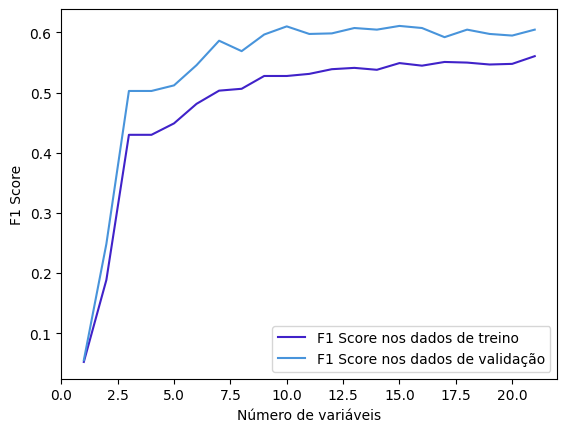

In [ ]:
nof_list = np.arange(1, df_shots_train_scaled.shape[1])
high_score = 0

# Variable to store the optimum features
nof = 0
train_score_list = []
val_score_list = []

for n in range(len(nof_list)):
  rfe_model = LogisticRegression(random_state = 92)
  rfe = RFE(estimator = rfe_model, n_features_to_select = nof_list[n])

  X_train_rfe = rfe.fit_transform(df_shots_train_scaled, y_train)
  X_val_rfe = rfe.transform(df_shots_val_scaled)

  rfe_model.fit(X_train_rfe, y_train)

  # Resultados nos dados de treino
  rfe_labels_train = rfe_model.predict(X_train_rfe)
  train_score = f1_score(y_train, rfe_labels_train)
  train_score_list.append(train_score)

  # Resultados nos dados de validação
  rfe_labels_val = rfe_model.predict(X_val_rfe)
  val_score = f1_score(y_val, rfe_labels_val)
  val_score_list.append(val_score)

  # Encontrar melhor score
  if(val_score >= high_score):
    high_score = val_score
    nof = nof_list[n]

    features_to_select = pd.Series(data = rfe.support_, index = df_shots_train_scaled.columns)

print("Número ótimo de variáveis: %d" %nof)
print("F1 Score com %d variáveis: %f" % (nof, high_score))
with pd.option_context("display.max_rows", None):
  print(f"Variáveis a selecionar: \n{features_to_select}")

# Acrescentar decisão à tabela auxiliar
rfe_result = {col: "Manter" if features_to_select[col] else "Descartar" for col in df_shots_train_scaled.columns}
df_feature_selection["rfe"] = pd.Series(rfe_result)
df_feature_selection["rfe"] = df_feature_selection["rfe"].fillna("-")

plt.plot(list(range(1, df_shots_train_scaled.shape[1])), train_score_list, label = "F1 Score nos dados de treino", color = "#4022C9")
plt.plot(list(range(1, df_shots_train_scaled.shape[1])), val_score_list, label = "F1 Score nos dados de validação", color = "#4894DB")
plt.xlabel("Número de variáveis")
plt.ylabel("F1 Score")
plt.legend()
plt.show()

Esta técnica não sugere remover muitas variáveis, como já poderíamos esperar. Não deixa, ainda assim, de ser curioso que tenhamos obtido, nesta simulação, resultados ligeira mas consistentemente melhores nos dados de validação do que nos de treino.

### Random Forest

In [ ]:
# Aumentar um pouco o número mínimo de samples for folha para tentar prevenir overfitting
rf_model_fs = RandomForestClassifier(min_samples_leaf = 5, random_state = 92)
rf_model_fs.fit(df_shots_train_scaled, y_train)
importances = rf_model_fs.feature_importances_
indices = np.argsort(importances)[::-1]
rf_feature_importances = pd.DataFrame({"Variável": df_shots_train_scaled.columns[indices], "Coeficiente": importances[indices]})

# Mediana da importância das variáveis
rf_median_importance = rf_feature_importances["Coeficiente"].median()

# Acrescentar decisão à tabela auxiliar
rf_result = {row["Variável"]: "Manter" if row["Coeficiente"] >= rf_median_importance else "Descartar" for _, row in rf_feature_importances.iterrows()}
df_feature_selection["random_forest"] = pd.Series(rf_result)
df_feature_selection["random_forest"] = df_feature_selection["random_forest"].fillna("-")

# Criar gráfico de output desta célula
fig = px.bar(rf_feature_importances, x = "Coeficiente", y = "Variável", orientation = "h", color_discrete_sequence = ["#4894DB"],
             title = "Importância (relativa) para uma Random Forest")
fig.add_vline(x = rf_median_importance, line_dash = "dash", line_color = "black")
fig.update_layout(title_x = 0.5, showlegend = False, height = len(rf_feature_importances) * 30)
fig.show()

### LASSO

In [ ]:
reg = LassoCV(random_state = 92)
reg.fit(df_shots_train_scaled, y_train)
coef = pd.Series(data = reg.coef_, index = df_shots_train_scaled.columns)
imp_coef = coef.sort_values()
imp_coef_df = pd.DataFrame({"Variável": imp_coef.index, "Coeficiente": imp_coef.values})

# Acrescentar decisão à tabela auxiliar
lasso_result = {row["Variável"]: "Manter" if abs(row["Coeficiente"]) >= 0.025 else "Descartar" for _, row in imp_coef_df.iterrows()}
df_feature_selection["lasso"] = pd.Series(lasso_result)
df_feature_selection["lasso"] = df_feature_selection["lasso"].fillna("-")

# Criar gráfico de output desta célula
fig = px.bar(imp_coef_df, x = "Coeficiente", y = "Variável", orientation = "h", color_discrete_sequence = ["#4894DB"],
             title = "Importância das Variáveis de acordo com a técnica LASSO")
fig.add_vline(x = 0.025, line_dash = "dash", line_color = "black")
fig.add_vline(x = -0.025, line_dash = "dash", line_color = "black")
fig.update_layout(title_x = 0.5, xaxis_title = "Coeficiente", yaxis_title = "Variável", height = len(imp_coef_df) * 30)
fig.show()

### Decisão Final

In [ ]:
df_feature_selection["Decisão"] = df_feature_selection.apply(
  lambda row: "Manter" if (row == "Manter").sum() > (row == "Descartar").sum() else "Descartar", axis = 1
)
df_feature_selection.style.applymap(highlight_cell_val, subset = ["Decisão"])

,spearman,anova,qui2_variaveis,qui2_target,rfe,random_forest,lasso,Decisão
Variável,,,,,,,,
min,Manter,Descartar,-,-,Descartar,Manter,Descartar,Descartar
avg_season_goals_scored,Manter,Manter,-,-,Manter,Manter,Manter,Manter
avg_season_goals_conceded_opp,Manter,Manter,-,-,Manter,Manter,Manter,Manter
shot_distance,Manter,Manter,-,-,Manter,Manter,Manter,Manter
shot_angle,Manter,Manter,-,-,Manter,Manter,Manter,Manter
player_years_at_club,Manter,Descartar,-,-,Manter,Descartar,Manter,Manter
period_id,-,-,Descartar,Descartar,Descartar,Descartar,Descartar,Descartar
Right footed,-,-,Descartar,Manter,Manter,Manter,Manter,Manter
Assisted,-,-,Descartar,Manter,Descartar,Descartar,Manter,Descartar


Como poderíamos antecipar, não temos muitas variáveis para descartar após a seleção de variáveis. Vamos remover duas das que já estávamos à espera de remover (`min` e `period_id`) e ainda a `Assisted`, `Intentional assist`, `Individual Play` e `is_losing`.

In [ ]:
# Remover variáveis
cols_to_drop = df_feature_selection[df_feature_selection["Decisão"] == "Descartar"].index.tolist()

df_shots_train_scaled = df_shots_train_scaled.drop(columns = cols_to_drop)
df_shots_val_scaled = df_shots_val_scaled.drop(columns = cols_to_drop)

# Atualizar lista de colunas numéricas e categóricas
vars_numeric = [col for col in vars_numeric if col not in cols_to_drop]
vars_categorical = [col for col in vars_categorical if col not in cols_to_drop]

print(f"Colunas removidas: {len(cols_to_drop)}")
print(f"Colunas restantes: {df_shots_train_scaled.shape[1]}")

Colunas removidas: 6
Colunas restantes: 16


In [ ]:
# Voltar a verificar a existência de duplicados
df_shots_train.duplicated().sum()

np.int64(0)

## <font color='#457fb5'>2.7. Outliers Multidimensionais</font> <a class="anchor" id="outliers"></a>
[Regressar ao Índice](#toc)

Nesta fase, podemos experimentar ver se temos outliers nos nossos dados. Já fizemos boxplots para todas as variáveis numéricas que fomos explorando (e tomámos decisões conscientes sobre como os tratar), mas não explorámos outliers multidimensionais, isto é, observações que, olhando para uma coluna só, não constituem um valor extremo, mas quando olhamos para o conjunto de todas as variáveis numéricas, estão bastante distantes do resto dos dados.

Para isso vamos recorrer à técnica Density-Based Spatial Clustering of Applications with Noise (normalmente conhecida como __DBSCAN__) __para encontrar estes outliers multidimensionais__. Esta é uma técnica popular de clustering que agrupa as observações com base na densidade do espaço. Aquelas que não se encaixam em nenhum cluster são identificadas como outliers, e são exatamente estas que vamos procurar neste caso.

__Nota__: O número ideal de neighbors, abaixo definido como sendo 2 x #variáveis numéricas - 1, foi definido tendo por base a recomendação de [Sander et al. (1998)](https://doi.org/10.1023/A:1009745219419).

In [ ]:
neigh = NearestNeighbors(n_neighbors = 2 * len(vars_numeric) - 1)
nbrs = neigh.fit(df_shots_train_scaled[vars_numeric])
distances, indices = nbrs.kneighbors(df_shots_train_scaled[vars_numeric])

print("Número de neighbours:", 2 * len(vars_numeric) - 1)

Número de neighbours: 9


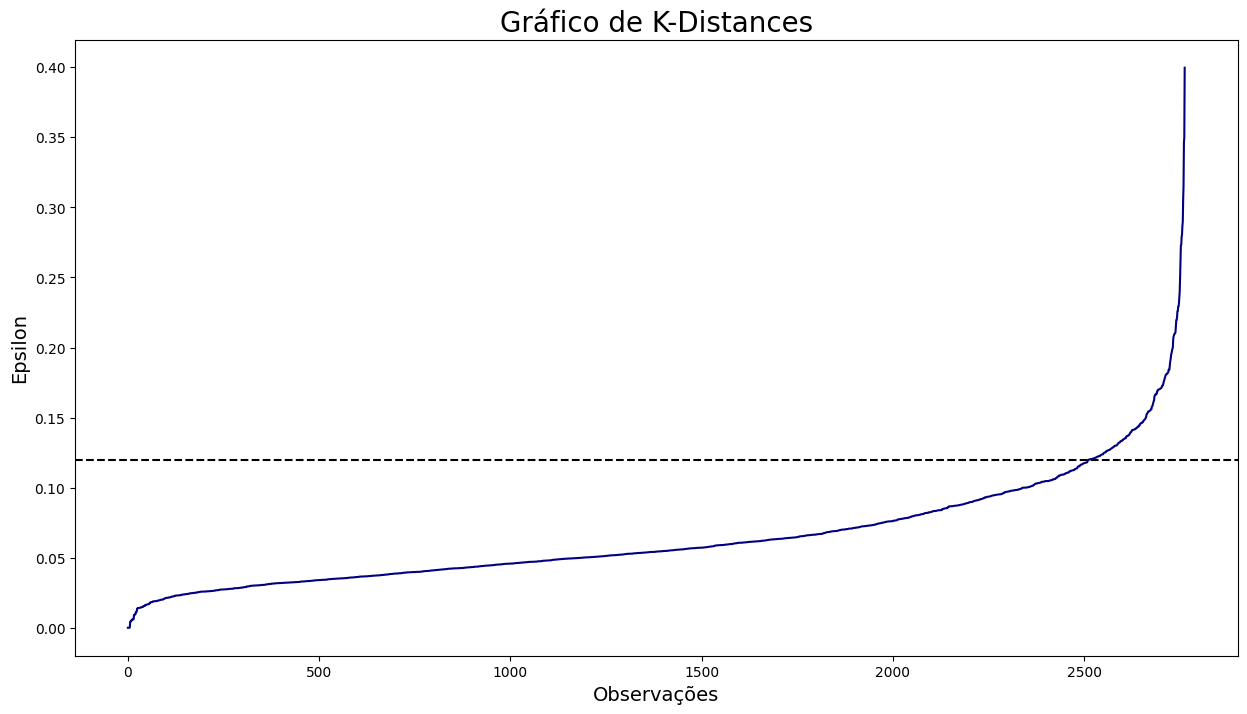

In [ ]:
distances = np.sort(distances, axis = 0)
distances = distances[:,1]
plt.figure(figsize = (15, 8))
plt.plot(distances, color = "navy")
plt.axhline(y = 0.12, color = "black", linestyle = "--")
plt.title("Gráfico de K-Distances", fontsize = 20)
plt.xlabel("Observações", fontsize = 14)
plt.ylabel("Epsilon", fontsize = 14)
plt.show()

In [ ]:
dbscan_out = DBSCAN(eps = 0.12, min_samples = 2 * len(vars_numeric) - 1).fit(df_shots_train_scaled[vars_numeric])

outliers_dbscan = df_shots_train_scaled[dbscan_out.labels_ == -1]
print("Percentagem de observações a remover:", np.round(outliers_dbscan.shape[0] / df_shots_train_scaled.shape[0] * 100, 2), "%")

Percentagem de observações a remover: 18.63 %


Mesmo quando seguimos uma abordagem conservadora (definimos o elbow acima no limite do aceitável para remover o mínimo de dados), acabamos por remover um número ainda considerável de observações. Isto levanta a questão de até que ponto mais de 18% dos dados serão realmente outliers se são em tão grande número, além de que implicaria perder ainda mais dados de treino de um dataset que por si só já é relativamente curto. Assim, vamos optar por __não remover outliers__ recorrendo a esta técnica, e prosseguir com todas as observações para a fase seguinte.

## <font color='#457fb5'>2.7. Oversampling</font> <a class="anchor" id="oversampling"></a>
[Regressar ao Índice](#toc)

Chegamos ao último passo de pré-processamento. Como temos observado, temos muito mais observações de remates que não deram em golo do que aquelas que tiveram sucesso. Contudo, neste caso concreto, entendemos que __poderá ser mais relevante ter um modelo capaz de prever golos__ (em função do contexto real em que surgisse o problema, poderia haver uma mais relevante que a outra).

Com o objetivo de equilibrar os modelos e não os enviesar demasiado para prever remates falhados muito melhor do que os golos, vamos testar aplicar várias técnicas de oversampling para avaliar se alguma resulta numa melhor performance (undersampling não estará em equação devido ao já referido reduzido número de observações). Vamos avaliar essa variação com base numa rede neuronal com parâmetros default do scikit-learn, e recorrendo às métricas F1 Score, precision e recall:
* __Precision__ - Representa a proporção de eventos positivos (neste caso, golos) corretamente classificados sobre todos os eventos classificados como positivos.
* __Recall__ - Representa a proporção de eventos positivos corretamente classificados sobre todos os eventos realmente positivos.
* __F1 Score__ - Média harmónica da precision e do recall, que favorece o equilíbrio entre as duas métricas.

__Nota:__ Num cenário ideal, o que faríamos seria "separar" o nosso tratamento dos dados e ter uma etapa de modelação com oversampling e outra sem oversampling. Contudo, devido a limitações de tempo tal não será possível, e por isso optaremos por esta abordagem.

In [ ]:
# obm é a abreviatura para "Oversampling Baseline Model"
obm = MLPClassifier(random_state = 92)
obm.fit(df_shots_train_scaled, y_train)

y_pred_obm = obm.predict(df_shots_val_scaled)
obm_f1 = f1_score(y_val, y_pred_obm)
obm_precision = precision_score(y_val, y_pred_obm)
obm_recall = recall_score(y_val, y_pred_obm)

print(f"Oversampling Baseline Model | F1 Score: {obm_f1:.4f} | Precision: {obm_precision:.4f} | Recall: {obm_recall:.4f}")

Oversampling Baseline Model | F1 Score: 0.7025 | Precision: 0.8416 | Recall: 0.6028


In [ ]:
# Definir número de neighbors (valor arbitrário)
n_neighbors = 5

# Lista de oversamplers a experimentar
samplers = [
  SMOTE(random_state = 92, k_neighbors = n_neighbors),
  ADASYN(random_state = 92, n_neighbors = n_neighbors),
  RandomOverSampler(random_state = 92),
  SMOTENC(random_state = 92, categorical_features = vars_categorical, k_neighbors = n_neighbors),
  BorderlineSMOTE(random_state = 92, k_neighbors = n_neighbors, m_neighbors = n_neighbors * 2),
  KMeansSMOTE(random_state = 92, k_neighbors = n_neighbors, cluster_balance_threshold = 0.05),
  SVMSMOTE(random_state = 92, k_neighbors = n_neighbors, m_neighbors = n_neighbors * 2)
]

results = []
for sampler in samplers:
  X_resampled, y_resampled = sampler.fit_resample(df_shots_train_scaled, y_train)
  classifier = MLPClassifier(random_state = 92)
  classifier.fit(X_resampled, y_resampled)
  y_pred = classifier.predict(df_shots_val_scaled)
  f1 = f1_score(y_val, y_pred)
  precision = precision_score(y_val, y_pred)
  recall = recall_score(y_val, y_pred)

  results.append({"Sampler": sampler.__class__.__name__, "F1 score": f1, "Precision": precision, "Recall": recall})

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by = "F1 score", ascending = False)
results_df

,Sampler,F1 score,Precision,Recall
6,SVMSMOTE,0.684848,0.597884,0.801418
2,RandomOverSampler,0.680473,0.583756,0.815603
5,KMeansSMOTE,0.680272,0.653595,0.709220
0,SMOTE,0.672673,0.583333,0.794326
3,SMOTENC,0.647230,0.549505,0.787234
4,BorderlineSMOTE,0.638889,0.525114,0.815603
1,ADASYN,0.611260,0.491379,0.808511


Embora o F1 Score para este modelo em específico até seja mais alto quando não há oversampling, o SVMSMOTE (o melhor dos oversamplers ccom base nesta métrica) apresenta um melhor equilíbrio entre precision e recall. Todos os oversamplers, aliás, invertem a lógica dos modelos sem resampling e são melhores a prever golos ao invés de remates falhados. Por isso, e tendo em consideração que a diferença no F1 Score não é assim tão significativa para o baseline model, __vamos experimentar transformar os nossos dados de treino com recurso ao SVMSMOTE__ e avançar com esse dataset para a etapa de modelação.

Aproveitando para explicar melhor o funcionamento do SVMSMOTE, primeiro é essencial compreender o SMOTE em si. Esta técnica envolve a criação de data points sintéticos (isto é, não são observações reais) que são atribuídas à classe menos representada. Para isso, o SMOTE começa por escolher aleatoriamente uma observação desta categoria (x) e identifica os seus k vizinhos mais próximos (no nosso caso, 5). Depois, escolhe um destes pontos (x') e cria uma nova observação através de interpolação linear das duas observações, repetindo o processo até que as classes do target estejam igualmente representadas. <br>
No caso do SVMSMOTE, há ainda um passo prévio que envolve o treino de um algoritmo SVM para encontrar a melhor fronteira entre classes. Depois, o SMOTE é aplicado selecionando apenas observações perto desta fronteira, assegurando uma melhor separação entre as categorias do target.

Nota: Se experimentarmos testar os oversamplers numa regressão logística e não numa rede neuronal, por exemplo, o melhor oversampler continuará a ser o SVMSMOTE e, neste caso, até atingirá um F1 Score melhor que o baseline model.

In [ ]:
df_shots_train_scaled_svmsmote, y_resampled_smvsmote = SVMSMOTE(random_state = 92, k_neighbors = n_neighbors, m_neighbors = n_neighbors * 2).fit_resample(df_shots_train_scaled, y_train)

Parece tudo bem, mas o facto de termos aplicado esta técnica traz consigo um novo problema. Eis um exemplo:

In [ ]:
df_shots_train_scaled_svmsmote["Right footed"].value_counts()

,count
Right footed,
0.000000,2238
1.000000,2173
0.512019,1
0.433812,1
0.071044,1


Ao gerarmos data points sintéticos com base nas distâncias, passámos a ter valores fora da escala, além de valores que não fazem sentido para ensinar os modelos (um remate ou é com o pé direito ou não é, qualquer valor diferente de 1 e 0 não estará correto). Vamos fazer um teste e limitar as observações ao intervalo entre 0 e 1 e arredondar as variáveis categóricas, para perceber como isso afeta o modelo base que tínhamos criado.

In [ ]:
df_shots_train_scaled_svmsmote[vars_categorical] = df_shots_train_scaled_svmsmote[vars_categorical].round()
df_shots_train_scaled_svmsmote = df_shots_train_scaled_svmsmote.clip(0, 1)

In [ ]:
classifier = MLPClassifier(random_state = 92)
classifier.fit(df_shots_train_scaled_svmsmote, y_resampled_smvsmote)
y_pred = classifier.predict(df_shots_val_scaled)
f1_sampled = f1_score(y_val, y_pred)
precision_sampled = precision_score(y_val, y_pred)
recall_sampled = recall_score(y_val, y_pred)

print(f"Resultados com correções ao SVMSMOTE | F1 Score: {f1_sampled:.4f} | Precision: {precision_sampled:.4f} | Recall: {recall_sampled:.4f}")

Resultados com correções ao SVMSMOTE | F1 Score: 0.6829 | Precision: 0.5989 | Recall: 0.7943


Os resultados não pioraram muito, mas se formos investigar a fundo, acabámos por comprometer noutros aspetos (por exemplo, a variável categórica `player_position` passou a ser 0 ou 1, o que equivale a dizer que o jogador que rematou ou é defesa ou avançado). Assim, vamos __abandonar esta técnica de resampling e optar pelo Random Oversampler__, que obteve resultados semelhantes e está preparado para lidar com variáveis categóricas.

__É mesmo uma questão de definição do que é mais importante.__ Se fosse indiferente a previsão por categoria, poderíamos perfeitamente avançar sem oversampling e lidar com modelos mais conservadores, que mais raramente iam prever golos. Em vez disso, vamos optar por um modelo que antecipa golos com mais frequência, sem estar ainda assim tão enviesado para esta classe como os modelos sem oversampling estariam para os remates falhados.

In [ ]:
X_train_final, y_train_final = RandomOverSampler(random_state = 92).fit_resample(df_shots_train_scaled, y_train)
X_train_final = optimize_dtypes(X_train_final)

# Olhando para o exemplo que vimos há pouco para confirmar que está tudo bem
X_train_final["Right footed"].value_counts()

,count
Right footed,
1.0,2222
0.0,2192


# <font color="#4894db">_____________</font>
# <font color='#4b4b4b'>3. Modelação</font> <a class="anchor" id="model"></a>
[Regressar ao Índice](#toc)

Chegamos, por fim, à etapa de modelação. Aqui, iremos aplicar de forma consistente uma função para __testar vários modelos, encontrar o melhor conjunto de parâmetros dentro das combinações fornecidas* e devolver os seus resultados em diversas métricas, bem como os parâmetros que levaram à melhor performance__. Vamos definir a performance tendo por base a métrica F1 Score, que já fomos aplicando em etapas anteriores (quando fizemos oversampling) e procura privilegiar um modelo equilibrado entre a capacidade de previsão de golos e de remates falhados. Iremos também guardar os resultados para um ficheiro pickle, para que a função original possa ser comentada e, desta forma, quem vier a correr o código possa aceder imediatamente ao melhor modelo sem ter de estar constantemente a repetir a pesquisa.

*devido a limitações computacionais, foi aplicada a função RandomizedSearchCV ao invés da GridSearchCV. Na prática, a implicação é que esta função irá escolher apenas 1000 combinações de dados (com exceção dos casos em que outro valor é especificiado), e não irá testar todas as combinações possíveis dentro da grelha fornecida. A expectativa é que, dentro destas 1000 combinações, a pesquisa consiga encontrar, senão a melhor, uma combinação próxima do melhor resultado possível para o modelo.

## <font color='#457fb5'>3.1. Computação de Modelos</font> <a class="anchor" id="compute"></a>
[Regressar ao Índice](#toc)

### Decision Tree

As árvores de decisão (decision trees) são um dos algoritmos mais simples de Machine Learning. Essencialmente, consistem num conjunto de regras que conduzem os dados de entrada desde o "root node" (o primeiro da árvore) até um "leaf node", onde todas as observações pertencentes a essa leaf são atribuídas a uma determinada categoria. A partir do root node, as observações são separadas em ramos, utilizando o valor de uma determinada variável como condição. Todas as variáveis são testadas, e aquela que apresenta o maior poder preditivo é definida como a condição do root node. Os dados são divididos consoante satisfaçam ou não a condição vencedora, e o processo repete-se para cada um dos novos nós originados pela divisão. Este procedimento continua até que todas as amostras contidas no nó apresentem a mesma classificação para o target.

In [ ]:
"""
dt_model = DecisionTreeClassifier(random_state = 92)

dt_param_grid = {
  "criterion": ["gini", "entropy"],
  "max_depth": [None, 4, 6, 8, 10, 14, 18],
  "min_samples_split": [0.01, 0.05, 0.1, 0.2, 0.3, 0.5],
  "min_samples_leaf": [0.01, 0.03, 0.05, 0.1, 0.15, 0.2, 0.3, 0.5],
  "max_features": [None, 0.1, 0.3, 0.5, "sqrt", "log2"],
  "max_leaf_nodes": [None, 5, 10, 20, 30],
  "min_impurity_decrease": [0, 0.01, 0.05]
}

dt_best_params, dt_y_pred, dt_accuracy, dt_precision, dt_recall, dt_f1, dt_roc_auc = run_model(dt_model,
                                                                                               dt_param_grid,
                                                                                               X_train_final,
                                                                                               y_train_final,
                                                                                               df_shots_val_scaled,
                                                                                               y_val,
                                                                                               "f1",
                                                                                               True,
                                                                                               "Decision_Tree")
"""

'\ndt_model = DecisionTreeClassifier(random_state = 92)\n\ndt_param_grid = {\n  "criterion": ["gini", "entropy"],\n  "max_depth": [None, 4, 6, 8, 10, 14, 18],\n  "min_samples_split": [0.01, 0.05, 0.1, 0.2, 0.3, 0.5],\n  "min_samples_leaf": [0.01, 0.03, 0.05, 0.1, 0.15, 0.2, 0.3, 0.5],\n  "max_features": [None, 0.1, 0.3, 0.5, "sqrt", "log2"],\n  "max_leaf_nodes": [None, 5, 10, 20, 30],\n  "min_impurity_decrease": [0, 0.01, 0.05]\n}\n\ndt_best_params, dt_y_pred, dt_accuracy, dt_precision, dt_recall, dt_f1, dt_roc_auc = run_model(dt_model,\n                                                                                               dt_param_grid,\n                                                                                               X_train_final,\n                                                                                               y_train_final,\n                                                                                               df_shots_val_scaled,\n      

In [ ]:
dt_best_params, dt_y_pred, dt_accuracy, dt_precision, dt_recall, dt_f1, dt_roc_auc = get_model("M6_shots_models/Decision_Tree.pkl",
                                                                                               df_shots_val_scaled,
                                                                                               y_val,
                                                                                               "M6_shots_models.zip")


Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.92      0.93       555
           1       0.70      0.74      0.72       141

    accuracy                           0.88       696
   macro avg       0.82      0.83      0.82       696
weighted avg       0.88      0.88      0.88       696

Accuracy: 0.8822 | Precision: 0.698 | Recall: 0.7376 | F1 score: 0.7172 | AUROC: 0.8862


### Regresão Logística

A regressão logística é uma técnica estatística utilizada para prever uma variável categórica a partir de um conjunto de variáveis independentes. Ao contrário da regressão linear, adequada para problemas em que o target é numérico, a regressão logística prevê a probabilidade de uma observação pertencer a uma determinada categoria, recorrendo à função sigmoide para garantir que a previsão se situa sempre entre 0 e 1. Utiliza o estimador de máxima verossimilhança (em inglês, Maximum Likelihood Estimator, ou MLE) para determinar os coeficientes que relacionam as variáveis independentes com a probabilidade de ocorrência.

In [ ]:
"""
lr_model = LogisticRegression(random_state = 92)

lr_param_grid = {
  "penalty": ["l1", "l2", "elasticnet"],
  "C": [0.0001, 0.001, 0.01, 0.1, 0.5, 1, 10, 100, 1000],
  "solver": ["lbfgs", "liblinear", "saga", "sag", "newton-cholesky"],
  "max_iter": [50, 100, 150, 200, 250, 300, 350, 400, 450, 500]
}

lr_best_params, lr_y_pred, lr_accuracy, lr_precision, lr_recall, lr_f1, lr_roc_auc = run_model(lr_model,
                                                                                               lr_param_grid,
                                                                                               X_train_final,
                                                                                               y_train_final,
                                                                                               df_shots_val_scaled,
                                                                                               y_val,
                                                                                               "f1",
                                                                                               True,
                                                                                               "Logistic_Regression")
"""

'\nlr_model = LogisticRegression(random_state = 92)\n\nlr_param_grid = {\n  "penalty": ["l1", "l2", "elasticnet"],\n  "C": [0.0001, 0.001, 0.01, 0.1, 0.5, 1, 10, 100, 1000],\n  "solver": ["lbfgs", "liblinear", "saga", "sag", "newton-cholesky"],\n  "max_iter": [50, 100, 150, 200, 250, 300, 350, 400, 450, 500]\n}\n\nlr_best_params, lr_y_pred, lr_accuracy, lr_precision, lr_recall, lr_f1, lr_roc_auc = run_model(lr_model,\n                                                                                               lr_param_grid,\n                                                                                               X_train_final,\n                                                                                               y_train_final,\n                                                                                               df_shots_val_scaled,\n                                                                                               y_val,\n                         

In [ ]:
lr_best_params, lr_y_pred, lr_accuracy, lr_precision, lr_recall, lr_f1, lr_roc_auc = get_model("M6_shots_models/Logistic_Regression.pkl",
                                                                                               df_shots_val_scaled,
                                                                                               y_val)


Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.83      0.87       555
           1       0.52      0.74      0.61       141

    accuracy                           0.81       696
   macro avg       0.72      0.78      0.74       696
weighted avg       0.84      0.81      0.82       696

Accuracy: 0.8075 | Precision: 0.5174 | Recall: 0.7376 | F1 score: 0.6082 | AUROC: 0.8405


### Naïve Bayes

À semelhança da regressão logística, a classificação bayesiana prevê a probabilidade de uma observação pertencer a uma dada classe, sendo posteriormente aplicado um threshold (por hábito, 0.5) para atribuir estas probabilidades a uma categoria concreta. Baseia-se no Teorema de Bayes, que permite calcular a probabilidade de um acontecimento considerando que um outro acontecimento já ocorreu. Um dos seus pontos-chave (e a razão pela qual é denominada "ingénua" ou "naïve") é o facto de assumir que a ocorrência de um acontecimento é independente da ocorrência de outros - desta forma, cada atributo contribui individualmente para uma previsão, sem depender das restantes variáveis independentes.

No nosso caso, utilizaremos uma variante da classificação de naïve Bayes que assume que as variáveis independentes seguem uma distribuição de Bernoulli, pressupondo que estas são categóricas. Embora tal não se verifique para todas as nossas variáveis independentes, iremos ainda assim testá-la para avaliar a sua performance.

In [ ]:
"""
nb_model = BernoulliNB()

nb_param_grid = {
  "binarize": np.arange(0, 1.1, 0.1)
}

nb_best_params, nb_y_pred, nb_accuracy, nb_precision, nb_recall, nb_f1, nb_roc_auc = run_model(nb_model,
                                                                                               nb_param_grid,
                                                                                               X_train_final,
                                                                                               y_train_final,
                                                                                               df_shots_val_scaled,
                                                                                               y_val,
                                                                                               "f1",
                                                                                               True,
                                                                                               "Naive_Bayes")
"""

'\nnb_model = BernoulliNB()\n\nnb_param_grid = {\n  "binarize": np.arange(0, 1.1, 0.1)\n}\n\nnb_best_params, nb_y_pred, nb_accuracy, nb_precision, nb_recall, nb_f1, nb_roc_auc = run_model(nb_model,\n                                                                                               nb_param_grid,\n                                                                                               X_train_final,\n                                                                                               y_train_final,\n                                                                                               df_shots_val_scaled,\n                                                                                               y_val,\n                                                                                               "f1",\n                                                                                               True,\n                                            

In [ ]:
nb_best_params, nb_y_pred, nb_accuracy, nb_precision, nb_recall, nb_f1, nb_roc_auc = get_model("M6_shots_models/Naive_Bayes.pkl",
                                                                                               df_shots_val_scaled,
                                                                                               y_val)


Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.74      0.82       555
           1       0.43      0.79      0.56       141

    accuracy                           0.75       696
   macro avg       0.68      0.76      0.69       696
weighted avg       0.83      0.75      0.77       696

Accuracy: 0.7486 | Precision: 0.4336 | Recall: 0.7872 | F1 score: 0.5592 | AUROC: 0.8319


### Rede Neuronal

As redes neuronais (ou neural networks) são sistemas computacionais que tentam replicar as redes neuronais biológicas dos animais. São compostas por vários percetrões — unidades lógicas individuais que produzem uma conclusão binária — que podem ser organizados em diversas camadas pelas quais os dados de entrada são processados.

Na primeira iteração de uma rede neuronal, os dados de entrada são passados para a primeira camada de nodes (percetrões), que recebe o nome de "input layer". Cada valor e variável dos dados de entrada recebe um peso aleatório, aumentando ou diminuindo a sua relevância quando chega à input layer. Dentro de cada node, uma função de ativação (activation function) transforma o input num output, antes de a passar para a layer seguinte (também com pesos aleatórios maiores ou menores), onde o processo se repete até os dados chegarem à "output layer", que devolve uma previsão final. O objetivo principal é otimizar os pesos e reduzir o erro de previsão (loss), o que é feito através da retropropagação (backpropagation) e de várias iterações dos dados ao longo dos nodes, em que cada uma deverá, idealmente, aproximar-se cada vez mais de uma previsão correta.

In [ ]:
"""
nn_model = MLPClassifier(random_state = 92)

nn_param_grid = {
  "hidden_layer_sizes": [(100,), (100, 100), (100, 50), (50,), (50, 50), (50, 25)],
  "activation": ["relu", "logistic"],
  "solver": ["adam", "sgd"],
  "alpha": [0.00001, 0.0001, 0.0005, 0.001, 0.01, 0.1],
  "learning_rate": ["constant", "invscaling", "adaptive"],
  "batch_size": [100, 200, 500],
  "learning_rate_init": [0.0001, 0.001, 0.005, 0.01, 0.1],
  "max_iter": [10, 50, 100, 200]
}

nn_best_params, nn_y_pred, nn_accuracy, nn_precision, nn_recall, nn_f1, nn_roc_auc = run_model(nn_model,
                                                                                               nn_param_grid,
                                                                                               X_train_final,
                                                                                               y_train_final,
                                                                                               df_shots_val_scaled,
                                                                                               y_val,
                                                                                               "f1",
                                                                                               True,
                                                                                               "Neural_Network")
"""

'\nnn_model = MLPClassifier(random_state = 92)\n\nnn_param_grid = {\n  "hidden_layer_sizes": [(100,), (100, 100), (100, 50), (50,), (50, 50), (50, 25)],\n  "activation": ["relu", "logistic"],\n  "solver": ["adam", "sgd"],\n  "alpha": [0.00001, 0.0001, 0.0005, 0.001, 0.01, 0.1],\n  "learning_rate": ["constant", "invscaling", "adaptive"],\n  "batch_size": [100, 200, 500],\n  "learning_rate_init": [0.0001, 0.001, 0.005, 0.01, 0.1],\n  "max_iter": [10, 50, 100, 200]\n}\n\nnn_best_params, nn_y_pred, nn_accuracy, nn_precision, nn_recall, nn_f1, nn_roc_auc = run_model(nn_model,\n                                                                                               nn_param_grid,\n                                                                                               X_train_final,\n                                                                                               y_train_final,\n                                                                                        

In [ ]:
nn_best_params, nn_y_pred, nn_accuracy, nn_precision, nn_recall, nn_f1, nn_roc_auc = get_model("M6_shots_models/Neural_Network.pkl",
                                                                                               df_shots_val_scaled,
                                                                                               y_val)


Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.90      0.92       555
           1       0.66      0.74      0.70       141

    accuracy                           0.87       696
   macro avg       0.80      0.82      0.81       696
weighted avg       0.88      0.87      0.87       696

Accuracy: 0.8707 | Precision: 0.6624 | Recall: 0.7376 | F1 score: 0.698 | AUROC: 0.8688


### Support Vector Machine

Numa Support Vector Machine (SVM), cada observação é tratada como um ponto num espaço n-dimensional. A tarefa de classificação consiste em encontrar o hiperplano que melhor diferencia as duas (ou mais) classes do target. Os vetores de suporte são simplesmente as coordenadas de uma observação individual. Uma SVM é a fronteira que melhor separa as duas classes.

__Nota:__ Devido a limitações computacionais, a probabilidade de uma observação pertencer a uma classe não será calculada para a SVM, invalidando o cálculo do ROC-AUC score.

In [ ]:
"""
svm_model = SVC(random_state = 92)

svm_param_grid = {
  "C": [0.01, 0.1, 0.5, 1, 10],
  "kernel": ["linear", "poly", "rbf", "sigmoid"],
  "gamma": ["scale", "auto", 0.001, 0.01, 0.1, 1, 10]
}

svm_best_params, svm_y_pred, svm_accuracy, svm_precision, svm_recall, svm_f1, svm_roc_auc = run_model(svm_model,
                                                                                                      svm_param_grid,
                                                                                                      X_train_final,
                                                                                                      y_train_final,
                                                                                                      df_shots_val_scaled,
                                                                                                      y_val,
                                                                                                      "f1",
                                                                                                      True,
                                                                                                      "SVM",
                                                                                                      100)
"""

'\nsvm_model = SVC(random_state = 92)\n\nsvm_param_grid = {\n  "C": [0.01, 0.1, 0.5, 1, 10],\n  "kernel": ["linear", "poly", "rbf", "sigmoid"],\n  "gamma": ["scale", "auto", 0.001, 0.01, 0.1, 1, 10]\n}\n\nsvm_best_params, svm_y_pred, svm_accuracy, svm_precision, svm_recall, svm_f1, svm_roc_auc = run_model(svm_model,\n                                                                                                      svm_param_grid,\n                                                                                                      X_train_final,\n                                                                                                      y_train_final,\n                                                                                                      df_shots_val_scaled,\n                                                                                                      y_val,\n                                                                                            

In [ ]:
svm_best_params, svm_y_pred, svm_accuracy, svm_precision, svm_recall, svm_f1, svm_roc_auc = get_model("M6_shots_models/SVM.pkl",
                                                                                                      df_shots_val_scaled,
                                                                                                      y_val)


Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.91      0.91       555
           1       0.63      0.61      0.62       141

    accuracy                           0.85       696
   macro avg       0.77      0.76      0.76       696
weighted avg       0.85      0.85      0.85       696

Accuracy: 0.8491 | Precision: 0.6324 | Recall: 0.6099 | F1 score: 0.6209 | AUROC: -


### Random Forest

Os algoritmos de ensemble baseiam-se na combinação de múltiplos algoritmos de aprendizagem supervisionada para efetuar previsões. Seguindo o princípio da "wisdom of the crowds", vários algoritmos "fracos" podem ter um desempenho superior em conjunto, quando comparados com um algoritmo "forte" mas individual.

Uma random forest é um conjunto de decision trees treinadas em paralelo, cada uma utilizando uma amostra de observações e um determinado subconjunto de variáveis independentes. No final, as suas previsões individuais são combinadas para obter uma previsão final.

In [ ]:
"""
rf_model = RandomForestClassifier(random_state = 92)

rf_param_grid = {
  "n_estimators": [10, 20, 50, 75, 100, 200],
  "criterion": ["gini", "entropy"],
  "max_depth": [None, 3, 6, 9, 12, 15],
  "min_samples_split": [0.01, 0.05, 0.1, 0.15, 0.2, 0.3, 0.5],
  "min_samples_leaf": [0.01, 0.03, 0.05, 0.1, 0.15, 0.2, 0.3, 0.5],
  "max_features": [None, 0.1, 0.3, 0.5, "sqrt", "log2"],
  "max_leaf_nodes": [None, 5, 10, 20, 30],
  "max_samples": [0.1, 0.2, 0.4, 0.6, 0.8, None]
}

rf_best_params, rf_y_pred, rf_accuracy, rf_precision, rf_recall, rf_f1, rf_roc_auc = run_model(rf_model,
                                                                                               rf_param_grid,
                                                                                               X_train_final,
                                                                                               y_train_final,
                                                                                               df_shots_val_scaled,
                                                                                               y_val,
                                                                                               "f1",
                                                                                               True,
                                                                                               "Random_Forest")
"""

'\nrf_model = RandomForestClassifier(random_state = 92)\n\nrf_param_grid = {\n  "n_estimators": [10, 20, 50, 75, 100, 200],\n  "criterion": ["gini", "entropy"],\n  "max_depth": [None, 3, 6, 9, 12, 15],\n  "min_samples_split": [0.01, 0.05, 0.1, 0.15, 0.2, 0.3, 0.5],\n  "min_samples_leaf": [0.01, 0.03, 0.05, 0.1, 0.15, 0.2, 0.3, 0.5],\n  "max_features": [None, 0.1, 0.3, 0.5, "sqrt", "log2"],\n  "max_leaf_nodes": [None, 5, 10, 20, 30],\n  "max_samples": [0.1, 0.2, 0.4, 0.6, 0.8, None]\n}\n\nrf_best_params, rf_y_pred, rf_accuracy, rf_precision, rf_recall, rf_f1, rf_roc_auc = run_model(rf_model,\n                                                                                               rf_param_grid,\n                                                                                               X_train_final,\n                                                                                               y_train_final,\n                                                                    

In [ ]:
rf_best_params, rf_y_pred, rf_accuracy, rf_precision, rf_recall, rf_f1, rf_roc_auc = get_model("M6_shots_models/Random_Forest.pkl",
                                                                                               df_shots_val_scaled,
                                                                                               y_val)


Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.86      0.89       555
           1       0.58      0.76      0.66       141

    accuracy                           0.84       696
   macro avg       0.76      0.81      0.78       696
weighted avg       0.86      0.84      0.85       696

Accuracy: 0.8391 | Precision: 0.5784 | Recall: 0.7589 | F1 score: 0.6564 | AUROC: 0.9057


### Bagging

A "bootstrap aggregation" (abreviada para bagging) consiste em treinar em paralelo múltiplas instâncias do mesmo algoritmo (estimador) em amostras (com reposição) do conjunto de treino, sendo as previsões individuais combinadas no final do processo para obter uma previsão final. O foco principal desta técnica é a redução da variância.

Como poderá ter sido percetível através da descrição anterior, as random forests são algoritmos de bagging. No entanto, para além de selecionarem aleatoriamente as amostras, as random forests fazem-no também com as variáveis, selecionando aleatoriamente um subconjunto de variáveis independentes a incluir em cada árvore individual.

__Nota:__ Na função abaixo, ao utilizar árvores de decisão como estimadores e ao definir o parâmetro "bootstrap_features" como True, estamos na realidade a calcular uma random forest. Esta opção "bootstrap_features" foi incluída para avaliar a diferença de desempenho dos restantes estimadores, comparando um cenário em que todas as variáveis são incluídas em todas as instâncias individuais do algoritmo com um cenário em que é selecionado um subconjunto de variáveis independentes.

In [ ]:
"""
bg_model = BaggingClassifier(random_state = 92)

bg_param_grid = {
  "estimator": [DecisionTreeClassifier(**dt_best_params),
                LogisticRegression(**lr_best_params),
                MLPClassifier(**nn_best_params),
                SVC(**svm_best_params)],
  "n_estimators": [5, 10, 15, 20],
  "max_samples": [0.1, 0.2, 0.4, 0.6, 0.8, 1],
  "max_features": [0.1, 0.2, 0.4, 0.6, 0.8, 1],
  "bootstrap_features": [True, False]
}

bg_best_params, bg_y_pred, bg_accuracy, bg_precision, bg_recall, bg_f1, bg_roc_auc = run_model(bg_model,
                                                                                               bg_param_grid,
                                                                                               X_train_final,
                                                                                               y_train_final,
                                                                                               df_shots_val_scaled,
                                                                                               y_val,
                                                                                               "f1",
                                                                                               True,
                                                                                               "Bagging")
"""

'\nbg_model = BaggingClassifier(random_state = 92)\n\nbg_param_grid = {\n  "estimator": [DecisionTreeClassifier(**dt_best_params),\n                LogisticRegression(**lr_best_params),\n                MLPClassifier(**nn_best_params),\n                SVC(**svm_best_params)],\n  "n_estimators": [5, 10, 15, 20],\n  "max_samples": [0.1, 0.2, 0.4, 0.6, 0.8, 1],\n  "max_features": [0.1, 0.2, 0.4, 0.6, 0.8, 1],\n  "bootstrap_features": [True, False]\n}\n\nbg_best_params, bg_y_pred, bg_accuracy, bg_precision, bg_recall, bg_f1, bg_roc_auc = run_model(bg_model,\n                                                                                               bg_param_grid,\n                                                                                               X_train_final,\n                                                                                               y_train_final,\n                                                                                               df_shots_v

In [ ]:
bg_best_params, bg_y_pred, bg_accuracy, bg_precision, bg_recall, bg_f1, bg_roc_auc = get_model("M6_shots_models/Bagging.pkl",
                                                                                               df_shots_val_scaled,
                                                                                               y_val)


Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.92      0.93       555
           1       0.70      0.74      0.72       141

    accuracy                           0.88       696
   macro avg       0.81      0.83      0.82       696
weighted avg       0.89      0.88      0.88       696

Accuracy: 0.8822 | Precision: 0.6954 | Recall: 0.7447 | F1 score: 0.7192 | AUROC: 0.9108


### AdaBoost

A ideia subjacente aos ensembles de boosting é que um modelo "fraco" pode ser impulsionado para um "algoritmo" forte através de um conjunto de iterações de treino, em que cada novo modelo é incentivado a prestar mais atenção às observações incorretamente classificadas pelas instâncias anteriores. É criada uma sequência de classificadores, sendo atribuída maior influência aos mais precisos. O foco principal desta técnica é a redução do enviesamento (bias).

Num algoritmo de Adaptive Boosting (ou AdaBoost, de forma abreviada), uma abordagem comum consiste em criar decision trees sem profundidade como estimadores base, conhecidas como "stumps". Cada stump considera os erros dos stumps anteriores (os erros recebem um peso superior que é transmitido à instância seguinte), sendo atribuído um peso mais elevado na previsão final àqueles que apresentam maior acerto.

In [ ]:
"""
ab_model = AdaBoostClassifier(random_state = 92)

ab_param_grid = {
  "estimator": [DecisionTreeClassifier(**dt_best_params),
                LogisticRegression(**lr_best_params),
                MLPClassifier(**nn_best_params),
                SVC(**svm_best_params)],
  "n_estimators": [5, 10, 20, 50, 100],
  "learning_rate": [0.001, 0.01, 0.05, 0.1, 0.25, 0.5, 1]
}

ab_best_params, ab_y_pred, ab_accuracy, ab_precision, ab_recall, ab_f1, ab_roc_auc = run_model(ab_model,
                                                                                               ab_param_grid,
                                                                                               X_train_final,
                                                                                               y_train_final,
                                                                                               df_shots_val_scaled,
                                                                                               y_val,
                                                                                               "f1",
                                                                                               True,
                                                                                               "Adaptive_Boosting")
"""

'\nab_model = AdaBoostClassifier(random_state = 92)\n\nab_param_grid = {\n  "estimator": [DecisionTreeClassifier(**dt_best_params),\n                LogisticRegression(**lr_best_params),\n                MLPClassifier(**nn_best_params),\n                SVC(**svm_best_params)],\n  "n_estimators": [5, 10, 20, 50, 100],\n  "learning_rate": [0.001, 0.01, 0.05, 0.1, 0.25, 0.5, 1]\n}\n\nab_best_params, ab_y_pred, ab_accuracy, ab_precision, ab_recall, ab_f1, ab_roc_auc = run_model(ab_model,\n                                                                                               ab_param_grid,\n                                                                                               X_train_final,\n                                                                                               y_train_final,\n                                                                                               df_shots_val_scaled,\n                                                           

In [ ]:
ab_best_params, ab_y_pred, ab_accuracy, ab_precision, ab_recall, ab_f1, ab_roc_auc = get_model("M6_shots_models/Adaptive_Boosting.pkl",
                                                                                               df_shots_val_scaled,
                                                                                               y_val)


Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.97      0.97       555
           1       0.89      0.88      0.89       141

    accuracy                           0.95       696
   macro avg       0.93      0.93      0.93       696
weighted avg       0.95      0.95      0.95       696

Accuracy: 0.954 | Precision: 0.8921 | Recall: 0.8794 | F1 score: 0.8857 | AUROC: 0.9846


### Gradient Boosting

Ao contrário do AdaBoost, que atribui um peso superior às observações incorretamente classificadas, o Gradient Boosting utiliza os erros para criar um novo algoritmo fraco, mas idealmente melhorado. Este processo é repetido até que um determinado limiar seja atingido ou até que a nova instância do modelo não seja capaz de melhorar mais a performance.

In [ ]:
"""
gb_model = GradientBoostingClassifier(random_state = 92)

gb_param_grid = {
  "n_estimators": [10, 20, 50, 100],
  "learning_rate": [0.01, 0.05, 0.1, 0.25, 0.5, 1],
  "min_samples_split": [0.01, 0.05, 0.1, 0.2, 0.3, 0.5],
  "min_samples_leaf": [0.01, 0.05, 0.1, 0.2, 0.3, 0.5],
  "max_depth": [None, 4, 6, 8, 10, 14, 20],
  "min_impurity_decrease": [0, 0.01, 0.05]
}

gb_best_params, gb_y_pred, gb_accuracy, gb_precision, gb_recall, gb_f1, gb_roc_auc = run_model(gb_model,
                                                                                               gb_param_grid,
                                                                                               X_train_final,
                                                                                               y_train_final,
                                                                                               df_shots_val_scaled,
                                                                                               y_val,
                                                                                               "f1",
                                                                                               True,
                                                                                               "Gradient_Boosting")
"""

'\ngb_model = GradientBoostingClassifier(random_state = 92)\n\ngb_param_grid = {\n  "n_estimators": [10, 20, 50, 100],\n  "learning_rate": [0.01, 0.05, 0.1, 0.25, 0.5, 1],\n  "min_samples_split": [0.01, 0.05, 0.1, 0.2, 0.3, 0.5],\n  "min_samples_leaf": [0.01, 0.05, 0.1, 0.2, 0.3, 0.5],\n  "max_depth": [None, 4, 6, 8, 10, 14, 20],\n  "min_impurity_decrease": [0, 0.01, 0.05]\n}\n\ngb_best_params, gb_y_pred, gb_accuracy, gb_precision, gb_recall, gb_f1, gb_roc_auc = run_model(gb_model,\n                                                                                               gb_param_grid,\n                                                                                               X_train_final,\n                                                                                               y_train_final,\n                                                                                               df_shots_val_scaled,\n                                                              

In [ ]:
gb_best_params, gb_y_pred, gb_accuracy, gb_precision, gb_recall, gb_f1, gb_roc_auc = get_model("M6_shots_models/Gradient_Boosting.pkl",
                                                                                               df_shots_val_scaled,
                                                                                               y_val)


Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.99      0.97       555
           1       0.95      0.84      0.89       141

    accuracy                           0.96       696
   macro avg       0.96      0.91      0.93       696
weighted avg       0.96      0.96      0.96       696

Accuracy: 0.9583 | Precision: 0.9516 | Recall: 0.8369 | F1 score: 0.8906 | AUROC: 0.9796


### XGBoost

O XGBoost (em inglês, Extreme Gradient Boosting) é uma implementação otimizada do Gradient Boosting, reconhecida pelo seu elevado desempenho e eficiência computacional. À semelhança do Gradient Boosting, constrói sequencialmente um conjunto de modelos fracos, em que cada novo modelo procura corrigir os erros residuais do anterior. No entanto, o XGBoost introduz um conjunto de melhorias técnicas, nomeadamente mecanismos de regularização do modelo (através dos termos L1 e L2) para penalizar a complexidade e reduzir o overfitting, bem como a paralelização de partes do processo de construção das decision trees, que permite acelerar significativamente o processo de treino.

In [ ]:
"""
xgb_model = XGBClassifier(random_state = 92, eval_metric = "logloss")

xgb_param_grid = {
  "n_estimators": [10, 20, 50, 100, 200],
  "learning_rate": [0.01, 0.05, 0.1, 0.25, 0.5, 1],
  "max_leaves": [0, 2, 4, 8, 16, 32, 64, 128],
  "max_depth": [3, 4, 6, 8, 10, 14, 20],
  "min_child_weight": [0.5, 1, 3, 5, 10],
  "subsample": [0.5, 0.7, 0.8, 1],
  "colsample_bytree": [0.5, 0.7, 0.8, 1],
  "gamma": [0, 0.01, 0.05, 0.1, 0.5],
  "reg_alpha": [0, 0.01, 0.1, 0.5, 1],
  "reg_lambda": [0.5, 1, 2, 5]
}

xgb_best_params, xgb_y_pred, xgb_accuracy, xgb_precision, xgb_recall, xgb_f1, xgb_roc_auc = run_model(xgb_model,
                                                                                                      xgb_param_grid,
                                                                                                      X_train_final,
                                                                                                      y_train_final,
                                                                                                      df_shots_val_scaled,
                                                                                                      y_val,
                                                                                                      "f1",
                                                                                                      True,
                                                                                                      "XGBoost")
"""

'\nxgb_model = XGBClassifier(random_state = 92, eval_metric = "logloss")\n\nxgb_param_grid = {\n  "n_estimators": [10, 20, 50, 100, 200],\n  "learning_rate": [0.01, 0.05, 0.1, 0.25, 0.5, 1],\n  "max_leaves": [0, 2, 4, 8, 16, 32, 64, 128],\n  "max_depth": [3, 4, 6, 8, 10, 14, 20],\n  "min_child_weight": [0.5, 1, 3, 5, 10],\n  "subsample": [0.5, 0.7, 0.8, 1],\n  "colsample_bytree": [0.5, 0.7, 0.8, 1],\n  "gamma": [0, 0.01, 0.05, 0.1, 0.5],\n  "reg_alpha": [0, 0.01, 0.1, 0.5, 1],\n  "reg_lambda": [0.5, 1, 2, 5]\n}\n\nxgb_best_params, xgb_y_pred, xgb_accuracy, xgb_precision, xgb_recall, xgb_f1, xgb_roc_auc = run_model(xgb_model,\n                                                                                                      xgb_param_grid,\n                                                                                                      X_train_final,\n                                                                                                      y_train_final,\n           

In [ ]:
xgb_best_params, xgb_y_pred, xgb_accuracy, xgb_precision, xgb_recall, xgb_f1, xgb_roc_auc = get_model("M6_shots_models/XGBoost.pkl",
                                                                                                      df_shots_val_scaled,
                                                                                                      y_val)


Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.97      0.97       555
           1       0.89      0.84      0.87       141

    accuracy                           0.95       696
   macro avg       0.92      0.91      0.92       696
weighted avg       0.95      0.95      0.95       696

Accuracy: 0.9468 | Precision: 0.8881 | Recall: 0.844 | F1 score: 0.8655 | AUROC: 0.9794


## <font color='#457fb5'>3.2. Seleção do Modelo Ótimo</font> <a class="anchor" id="bestmodel"></a>
[Regressar ao Índice](#toc)

Com todos os modelos ótimos obtidos (ou pelo menos perto disso), podemos juntar todos os scores numa única tabela.

In [ ]:
metrics = {
  "Model": ["Decision Tree", "Regressão Logística", "Naïve Bayes", "Rede Neuronal", "SVM",
            "Random Forest", "Bagging", "Adaptive Boosting", "Gradient Boosting", "XGBoost"],
  "Accuracy": [dt_accuracy, lr_accuracy, nb_accuracy, nn_accuracy, svm_accuracy,
               rf_accuracy, bg_accuracy, ab_accuracy, gb_accuracy, xgb_accuracy],
  "Precision": [dt_precision, lr_precision, nb_precision, nn_precision, svm_precision,
                rf_precision, bg_precision, ab_precision, gb_precision, xgb_precision],
  "Recall": [dt_recall, lr_recall, nb_recall, nn_recall, svm_recall,
             rf_recall, bg_recall, ab_recall, gb_recall, xgb_recall],
  "F1 Score": [dt_f1, lr_f1, nb_f1, nn_f1, svm_f1,
               rf_f1, bg_f1, ab_f1, gb_f1, xgb_f1],
  "ROC AUC": [dt_roc_auc, lr_roc_auc, nb_roc_auc, nn_roc_auc, svm_roc_auc,
              rf_roc_auc, bg_roc_auc, ab_roc_auc, gb_roc_auc, xgb_roc_auc]
}

scores = pd.DataFrame(metrics).sort_values(by = "F1 Score", ascending = False)
highlight_max_column(scores)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
8,Gradient Boosting,0.958300,0.951600,0.836900,0.890600,0.979600
7,Adaptive Boosting,0.954000,0.892100,0.879400,0.885700,0.984600
9,XGBoost,0.946800,0.888100,0.844000,0.865500,0.979400
6,Bagging,0.882200,0.695400,0.744700,0.719200,0.910800
0,Decision Tree,0.882200,0.698000,0.737600,0.717200,0.886200
3,Rede Neuronal,0.870700,0.662400,0.737600,0.698000,0.868800
5,Random Forest,0.839100,0.578400,0.758900,0.656400,0.905700
4,SVM,0.849100,0.632400,0.609900,0.620900,-
1,Regressão Logística,0.807500,0.517400,0.737600,0.608200,0.840500
2,Naïve Bayes,0.748600,0.433600,0.787200,0.559200,0.831900


Os 3 modelos ensembles de Boosting foram, de muito longe, aqueles que obtiveram uma melhor performance nos dados de validação. Isto indica-nos que, para resolver este problema de previsão do desfecho de um remate, não é suficiente aplicar um algoritmo simples (como a regressão logística ou naïve Bayes), mas também não é necessário recorrer a algoritmos mais complexos como são as redes neuronais. Em vez disso, a solução passa por aplicar várias iterações de um modelo simples (no caso, decision trees) e, em cada uma, focar-se nos erros da anterior.

Relativamente ao modelo final a selecionar, embora o F1 score tenha sido ligeiramente superior para o gradient boosting, __vamos privilegiar o maior equilíbrio entre precision e recall e escolher o modelo de adaptive boosting__. Este modelo atingiu também uma accuracy mesmo muito boa, acima dos 95%, e apresenta um equilíbrio bastante bem conseguido entre a capacidade de prever remates golos e remates falhados, que se traduzem num F1 score de aproximadamente 0.89. __Comparando com o ponto de partida apresentado (que chegou a um valor de 0.5), podemos encarar este aumento de 78% no valor do F1 score como evidência de uma melhoria significativa__, que se justifica não só pela maior variedade de modelos e parâmetros testados (que poderiam ter sido ainda mais caso tivéssemos feito uma grid search completa), mas sobretudo pelo pré-processamento que foi desenvolvido até chegar à etapa final de modelação. Por fim, dar uma última nota para o valor da ROC-AUC, de mais de 0.98, e se interpreta como sendo "outstanding", de acordo com a classificação originalmente proposta por [Çorbacıoğlu &
Aksel (2023)](https://doi.org/10.4103/tjem.tjem_182_23) num contexto clínico, mas entretanto generalizada para os restantes tipos de problemas.

Podemos aproveitar para visualizar a matriz de confusão para melhor compreender a distribuição das previsões face aos valores reais, assim como a curva que resultou na área devoldia pelo ROC-AUC score.

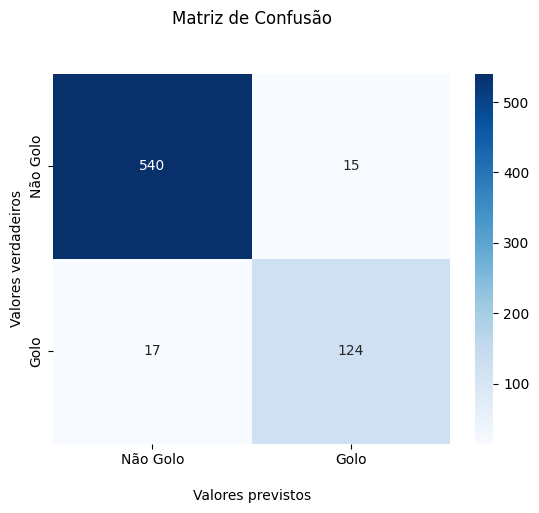

In [ ]:
cf_matrix = confusion_matrix(y_val, ab_y_pred)

ax = sns.heatmap(cf_matrix, annot = True, cmap = "Blues", fmt = "g")

ax.set_title("Matriz de Confusão\n\n");
ax.set_xlabel("\nValores previstos")
ax.set_ylabel("Valores verdadeiros");

ax.xaxis.set_ticklabels(["Não Golo", "Golo"])
ax.yaxis.set_ticklabels(["Não Golo", "Golo"])

plt.show()

Como vemos, obtivemos um modelo bastante seguro e que acerta na maior parte dos casos. Algo que nos levou a optar pelo modelo de adaptive boosting ao invés do de gradient boosting foi o maior equilíbrio entre precision e recall, e isso fica bem evidente por esta matriz: existem praticamente tantos casos em que o modelo prevê golos que não aconteceram (15) como observações que foram realmente golo mas foram previstas como um remate falhado (17).

In [ ]:
# Vamos buscar o modelo em si, que não retirámos anteriormente
with open("M6_shots_models/Adaptive_Boosting.pkl", "rb") as file:
  ab_model = pickle.load(file)

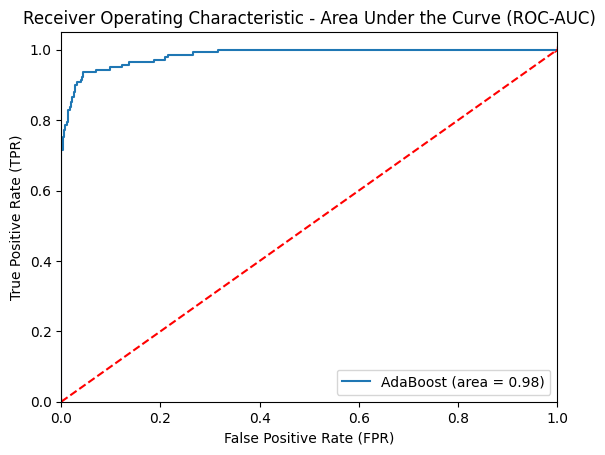

In [ ]:
fpr, tpr, thresholds = roc_curve(y_val, ab_model.predict_proba(df_shots_val_scaled)[:, 1])
plt.figure()
plt.plot(fpr, tpr, label = "AdaBoost (area = %0.2f)" % ab_roc_auc)
plt.plot([0, 1], [0, 1], "r--2")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("Receiver Operating Characteristic - Area Under the Curve (ROC-AUC)")
plt.legend(loc = "lower right")
plt.show()

A curva demonstra bem o score acima descrito, com um equilíbrio assinalável entre o FPR e TPR e, consequentemente, entre a previsão de falsos positivos e falsos negativos.

## <font color='#457fb5'>3.3. Identificar Variáveis Mais Relevantes</font> <a class="anchor" id="importance"></a>
[Regressar ao Índice](#toc)

Por fim, podemos aproveitar as características deste modelo para identificar as variáveis independentes que tiveram um maior peso na previsão do outcome do remate nos dados de validação. Isto será especialmente útil num cenário real, em que o modelo seja apresentado a uma equipa técnica que, naturalmente, quererá saber quais foram as variáveis mais consideradas para obter estes resultados.

In [ ]:
ab_feature_importances = pd.DataFrame({
  "Variável": df_shots_val_scaled.columns,
  "Peso (importância)": ab_model.feature_importances_
}).sort_values("Peso (importância)", ascending = False)

fig = px.bar(ab_feature_importances, x = "Peso (importância)", y = "Variável", orientation = "h", color_discrete_sequence = ["#4894DB"],
             title = "AdaBoost - Variáveis mais relevantes para o modelo")
fig.update_layout(title_x = 0.5, showlegend = False, height = len(ab_feature_importances) * 30)
fig.show()

Como vemos, existem quatro variáveis mais relevantes para prever o sucesso (ou não) de um remate,sendo elas a média de golos sofridos por jogo pela equipa que defende, a média de golos marcados pela equipa que rematou, e a distância e ângulo do remate. A antiguidade de um jogador no seu clube e as variáveis binárias que indicam se um remate foi um penálti ou cabeceamento também assumem um peso interessante na decisão do modelo. Em sentido contrário, as variáveis que identificam remates dentro da grande área ou na zona central à entrada da mesma foram praticamente negligenciadas por este algoritmo na construção do seu modelo ótimo.